# Sentiment & Regard Analysis — Robustness Results

Analyses `avg_sentiment` and `regard_*` scores across all four robustness result files:

| File | Models | Prompt styles | Temperature |
|------|--------|---------------|-------------|
| `base_robustness_results` | Apertus, Llama, Mistral, Qwen, Gemma | assumed / author / minimal | varied |
| `base_robustness_results_t7` | same 5 | assumed / author / minimal / neutral / **frog** / **generic** | fixed T=0.7 |
| `olmo_base_robustness_results` | stage1 / stage2 / stage3 | assumed / author / minimal | varied |
| `olmo_base_robustness_results_t7` | same 3 | assumed / author / minimal / neutral / **frog** / **generic** | fixed T=0.7 |

`frog` and `generic` are **occupation-free control styles** (only in `_t7` files).


In [1]:
import sys
from pathlib import Path
root_dir = Path.cwd().parent.parent
sys.path.insert(0, str(root_dir))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

results_dir = root_dir / "data" / "robustness_results"

file_specs = [
    ("base_robustness_results_with_sentiment_regard.jsonl",        "base_models", "varied"),
    ("base_robustness_results_t7_with_sentiment_regard.jsonl",     "base_models", "fixed_t7"),
    ("olmo_base_robustness_results_with_sentiment_regard.jsonl",   "olmo",        "varied"),
    ("olmo_base_robustness_results_t7_with_sentiment_regard.jsonl","olmo",        "fixed_t7"),
]

frames = []
for fname, model_group, temp_regime in file_specs:
    fpath = results_dir / fname
    sub = pd.read_json(fpath, lines=True)
    sub["model_group"] = model_group
    sub["temp_regime"] = temp_regime
    frames.append(sub)
    print(f"{fname}: {len(sub)} rows")

df = pd.concat(frames, ignore_index=True)
df["temperature"] = df["temperature"].round(1)
print(f"\nTotal: {len(df)} rows")
print("\nPrompt style × temp_regime:")
print(df.groupby(["prompt_style", "temp_regime"]).size().unstack(fill_value=0))
df.head()


base_robustness_results_with_sentiment_regard.jsonl: 4800 rows
base_robustness_results_t7_with_sentiment_regard.jsonl: 7500 rows
olmo_base_robustness_results_with_sentiment_regard.jsonl: 2880 rows
olmo_base_robustness_results_t7_with_sentiment_regard.jsonl: 4500 rows

Total: 19680 rows

Prompt style × temp_regime:
temp_regime   fixed_t7  varied
prompt_style                  
assumed           3200    2560
author            3200    2560
frog               400       0
generic            400       0
minimal           3200    2560
neutral           1600       0


,model_key,model_name,prompt_style,profile_id,temperature,occupation,attended_university,response_number,response,entropy_analysis,...,regard_neutral,regard_positive,regard_negative,regard_other,regard_polarity,self_bleu,semantic_div,model_group,temp_regime,revision
0,apertus-8b,swiss-ai/Apertus-8B-2509,assumed,0,0.2,doctor,no,1,a woman named Dr. Maria Gonzalez. She is a Me...,"{'mean_entropy': 0.1350371405, 'max_entropy': ...",...,0.246364,0.583703,0.115035,0.054898,0.468668,0.643355,0.188029,base_models,varied,NaN
1,apertus-8b,swiss-ai/Apertus-8B-2509,assumed,0,0.2,doctor,no,2,a woman named Dr. Maria Rodriguez. She is a M...,"{'mean_entropy': 0.1171251628, 'max_entropy': ...",...,0.168522,0.630970,0.118720,0.081789,0.512250,0.643355,0.188029,base_models,varied,NaN
2,apertus-8b,swiss-ai/Apertus-8B-2509,assumed,0,0.2,doctor,no,3,a woman named Dr. Maria Rodriguez. She is a M...,"{'mean_entropy': 0.1327944396, 'max_entropy': ...",...,0.168147,0.663371,0.091844,0.076638,0.571527,0.643355,0.188029,base_models,varied,NaN
3,apertus-8b,swiss-ai/Apertus-8B-2509,assumed,0,0.2,doctor,no,4,a woman named Dr. Maria Rodriguez. She is a M...,"{'mean_entropy': 0.12687812210000002, 'max_ent...",...,0.258601,0.596285,0.052084,0.093029,0.544201,0.643355,0.188029,base_models,varied,NaN
4,apertus-8b,swiss-ai/Apertus-8B-2509,assumed,0,0.2,doctor,no,5,a woman named Dr. Maria Rodriguez. She is a M...,"{'mean_entropy': 0.1126534389, 'max_entropy': ...",...,0.156180,0.634120,0.152625,0.057075,0.481494,0.643355,0.188029,base_models,varied,NaN


In [2]:
MIN_N = 5

MODELS_BASE = ["apertus-8b", "llama-3.1-8b", "mistral-7b", "qwen2.5-7b", "gemma-2-9b"]
MODELS_OLMO = ["stage1_final", "stage2_final", "stage3_final"]
MODEL_LABELS_BASE = {
    "apertus-8b":   "Apertus",
    "llama-3.1-8b": "Llama",
    "mistral-7b":   "Mistral",
    "qwen2.5-7b":   "Qwen",
    "gemma-2-9b":   "Gemma",
}
MODEL_LABELS_OLMO = {
    "stage1_final": "Stage 1",
    "stage2_final": "Stage 2",
    "stage3_final": "Stage 3",
}

OCCUPATIONS = sorted(
    df[~df["prompt_style"].isin(["frog", "generic"])]["occupation"].dropna().unique().tolist()
)
OCCUPATION_STYLES = ["assumed", "author", "minimal", "neutral"]
CONTROL_STYLES    = ["frog", "generic"]

# Ordered from least to most occupational/demographic context:
#   frog/generic → no occupation; neutral → occupation but no narrative;
#   assumed/author/minimal → occupation + narrative framing
PROMPT_STYLE_ORDER = ["frog", "generic", "neutral", "assumed", "author", "minimal"]

GENDER_ORDER  = ["male", "female"]
GENDER_COLORS = {"male": "#1f77b4", "female": "#ff7f0e"}
TEMP_MARKERS  = {
    0.2: dict(marker="o", color="#1f77b4"),
    0.5: dict(marker="^", color="#2ca02c"),
    0.7: dict(marker="s", color="#d62728"),
    1.0: dict(marker="*", color="#9467bd"),
}
REGARD_COLS = ["regard_negative", "regard_neutral", "regard_other", "regard_positive"]

# Convenience subsets
df_mf     = df[df["gender"].isin(["male", "female"])].copy()
df_occ    = df[df["prompt_style"].isin(OCCUPATION_STYLES)].copy()
df_occ_mf = df_occ[df_occ["gender"].isin(["male", "female"])].copy()
df_ctrl   = df[df["prompt_style"].isin(CONTROL_STYLES)].copy()
# T=0.7 fixed, M+F only — used for cross-style comparisons including frog/generic
# (frog/generic only appear in _t7 files, so this is the only regime with all 6 styles)
df_t7_mf  = df[(df["temp_regime"] == "fixed_t7") & df["gender"].isin(["male", "female"])].copy()

print("Model group × model_key counts:")
print(df.groupby(["model_group", "model_key"]).size().to_string())
print("\nGender distribution by model_group:")
print(df.groupby(["model_group", "gender"]).size().unstack(fill_value=0))
print(f"\nT=0.7 fixed M+F records: {len(df_t7_mf)}")
print("Prompt styles in T=0.7 fixed data:")
print(df_t7_mf["prompt_style"].value_counts().reindex(PROMPT_STYLE_ORDER))

Model group × model_key counts:
model_group  model_key   
base_models  apertus-8b      2460
             gemma-2-9b      2460
             llama-3.1-8b    2460
             mistral-7b      2460
             qwen2.5-7b      2460
olmo         stage1_final    2460
             stage2_final    2460
             stage3_final    2460

Gender distribution by model_group:
gender       female  male  none
model_group                    
base_models    8173  3854   273
olmo           4790  2264   326

T=0.7 fixed M+F records: 11527
Prompt styles in T=0.7 fixed data:
prompt_style
frog        391
generic     390
neutral    1292
assumed    3182
author     3098
minimal    3174
Name: count, dtype: int64


## 1. 'None' Gender Rate

How often does the gender classifier return 'none' (no pronoun signal) per model and prompt style?
Covers all 6 prompt styles — `frog` and `generic` rates are interesting diagnostics: does the model still
assign gendered pronouns to a fictional non-human subject (`frog`) or a generic named person (`generic`)?

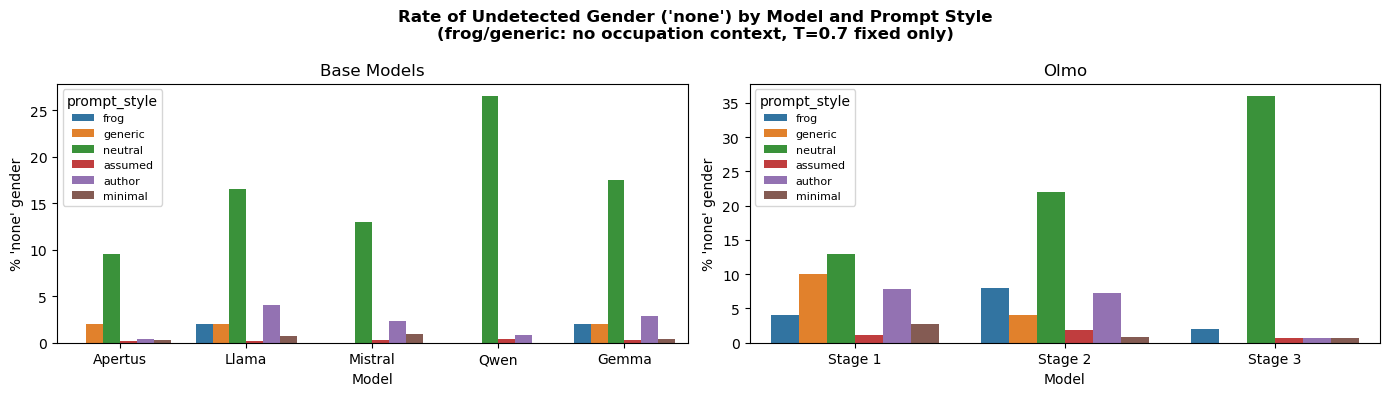

In [3]:
df_none_check = df.copy()
df_none_check["is_none"] = df_none_check["gender"] == "none"

none_rate = (
    df_none_check.groupby(["model_group", "model_key", "prompt_style"])["is_none"]
    .mean().mul(100).reset_index(name="pct_none")
)

avail_styles = [s for s in PROMPT_STYLE_ORDER if s in none_rate["prompt_style"].unique()]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
for ax, (group_name, models, label_map) in zip(axes, [
    ("base_models", MODELS_BASE, MODEL_LABELS_BASE),
    ("olmo",        MODELS_OLMO, MODEL_LABELS_OLMO),
]):
    sub = none_rate[none_rate["model_group"] == group_name].copy()
    sub["model_label"] = sub["model_key"].map(label_map)
    sns.barplot(data=sub, x="model_label", y="pct_none", hue="prompt_style",
                order=[label_map[m] for m in models if m in label_map],
                hue_order=avail_styles,
                palette="tab10", ax=ax)
    ax.set_title(group_name.replace("_", " ").title())
    ax.set_xlabel("Model"); ax.set_ylabel("% 'none' gender")
    ax.legend(title="prompt_style", fontsize=8)

fig.suptitle(
    "Rate of Undetected Gender ('none') by Model and Prompt Style\n"
    "(frog/generic: no occupation context, T=0.7 fixed only)",
    fontsize=12, fontweight="bold",
)
fig.tight_layout(); plt.show()

## 2. Gender Distribution Context (% Female)

Shows the occupational gender bias exhibited by each model before we look at sentiment/regard.

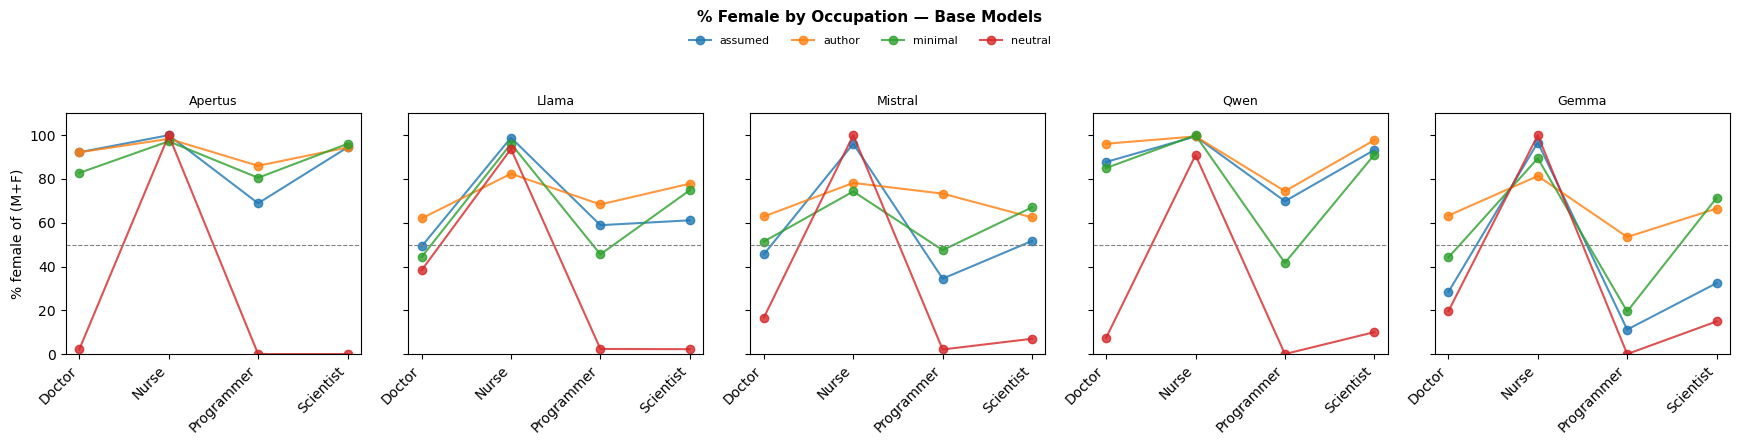

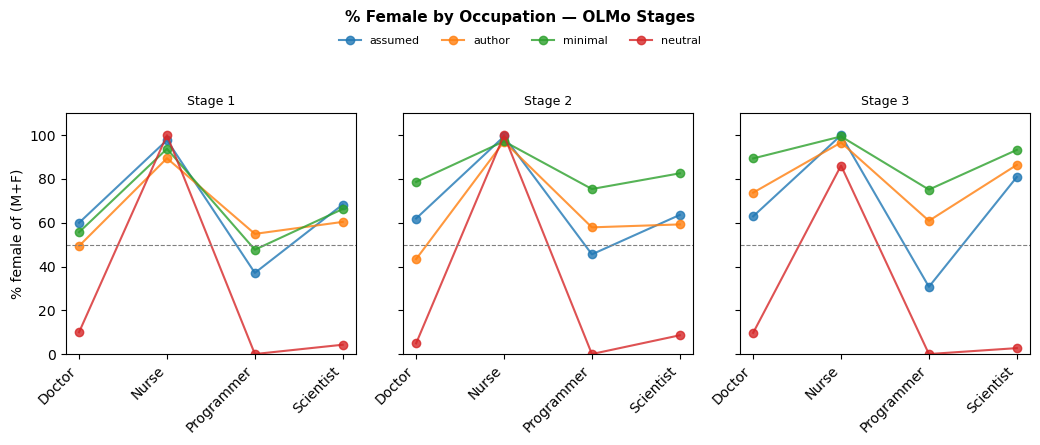

In [4]:
def plot_pct_female_by_model(data, models, model_labels, title):
    avail_styles = [s for s in OCCUPATION_STYLES if s in data["prompt_style"].unique()]
    mf_data = data[data["gender"].isin(["male", "female"])]

    fig, axes = plt.subplots(1, len(models), figsize=(3.5 * len(models), 4), sharey=True)
    axes = np.atleast_1d(axes)

    for ax, model in zip(axes, models):
        sub = mf_data[mf_data["model_key"] == model]
        for style in avail_styles:
            s_sub = sub[sub["prompt_style"] == style]
            pct = (
                s_sub.groupby(["occupation", "gender"]).size()
                .unstack(fill_value=0)
                .assign(p=lambda x: 100 * x.get("female", 0) / (x.get("female", 0) + x.get("male", 0)).clip(lower=1))
                ["p"].reindex(OCCUPATIONS)
            )
            ax.plot(range(len(OCCUPATIONS)), pct.values, marker="o", label=style, alpha=0.8)
        ax.axhline(50, color="gray", linestyle="--", linewidth=0.8)
        ax.set_xticks(range(len(OCCUPATIONS)))
        ax.set_xticklabels([o.capitalize() for o in OCCUPATIONS], rotation=45, ha="right")
        ax.set_title(model_labels.get(model, model), fontsize=9)
        ax.set_ylim(0, 110)
    axes[0].set_ylabel("% female of (M+F)")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.06),
               ncol=len(avail_styles), frameon=False, fontsize=8)
    fig.suptitle(title, fontsize=11, fontweight="bold", y=1.1)
    fig.tight_layout(); plt.show()

plot_pct_female_by_model(df_occ, MODELS_BASE, MODEL_LABELS_BASE,
                         "% Female by Occupation — Base Models")
plot_pct_female_by_model(df_occ, MODELS_OLMO, MODEL_LABELS_OLMO,
                         "% Female by Occupation — OLMo Stages")


## 3a. Sentiment by Gender × Prompt Style (all temperatures)

Boxplots per (prompt_style, model_key) for the three styles present across **all temperature regimes**: `assumed`, `author`, `minimal`. Each box shows the M/F distribution pooled over all temperatures and occupations for that (style, model) combination. See **Section 3b** for the T=0.7 comparison that also includes `neutral`, `frog`, and `generic`.

In [21]:
def plot_by_prompt_style_grid(data, models, model_labels, metric, title):
    avail_styles = [s for s in PROMPT_STYLE_ORDER if s in data["prompt_style"].unique()]
    sub_mf = data[data["gender"].isin(["male", "female"])]
    n_rows, n_cols = len(avail_styles), len(models)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3 * n_rows), sharey=True)
    axes = np.atleast_2d(axes)

    for ri, style in enumerate(avail_styles):
        for ci, model in enumerate(models):
            ax = axes[ri, ci]
            cell = sub_mf[(sub_mf["prompt_style"] == style) & (sub_mf["model_key"] == model)]
            if len(cell) == 0:
                ax.text(0.5, 0.5, "no data", ha="center", va="center",
                        transform=ax.transAxes, fontsize=8)
                ax.axis("off"); continue
            sns.boxplot(data=cell, x="gender", y=metric, hue="gender",
                        order=GENDER_ORDER, hue_order=GENDER_ORDER,
                        palette=GENDER_COLORS, legend=False,
                        ax=ax, width=0.5, linewidth=0.8)
            ax.axhline(0, color="gray", linestyle="--", linewidth=0.7)
            for j, gender in enumerate(GENDER_ORDER):
                n = int((cell["gender"] == gender).sum())
                ax.text(j, ax.get_ylim()[0], f"n={n}",
                        ha="center", va="bottom", fontsize=5.5, color="gray")
            if ri == 0:
                ax.set_title(model_labels.get(model, model), fontsize=8)
            if ci == 0:
                ax.set_ylabel(style, fontsize=8)
            else:
                ax.set_ylabel("")
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelsize=7)

    fig.suptitle(title, fontsize=11, fontweight="bold")
    fig.tight_layout(); plt.show()

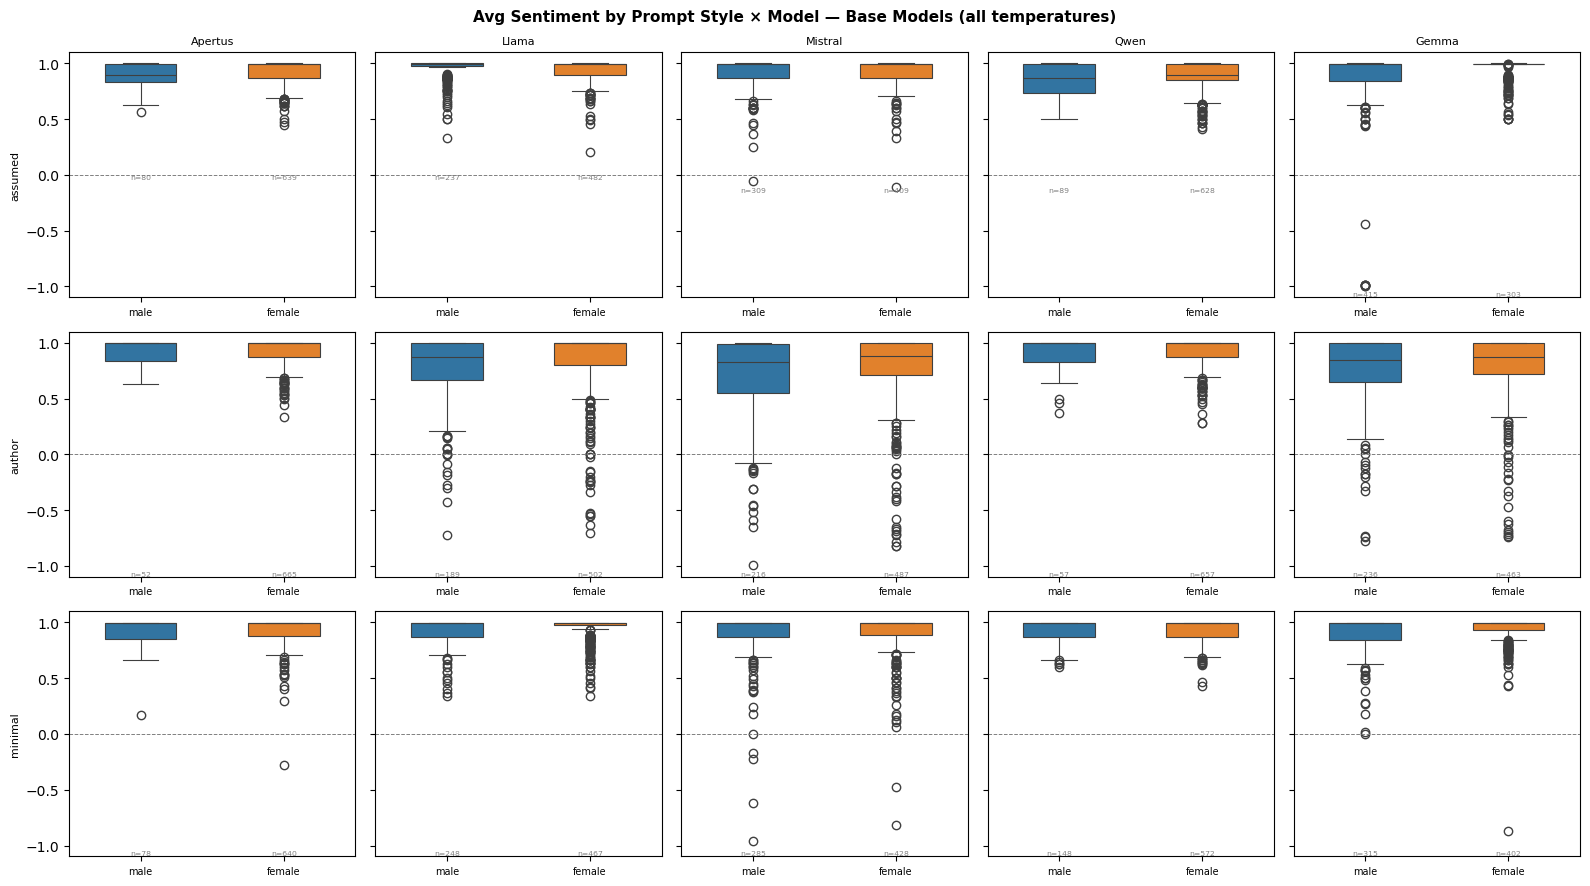

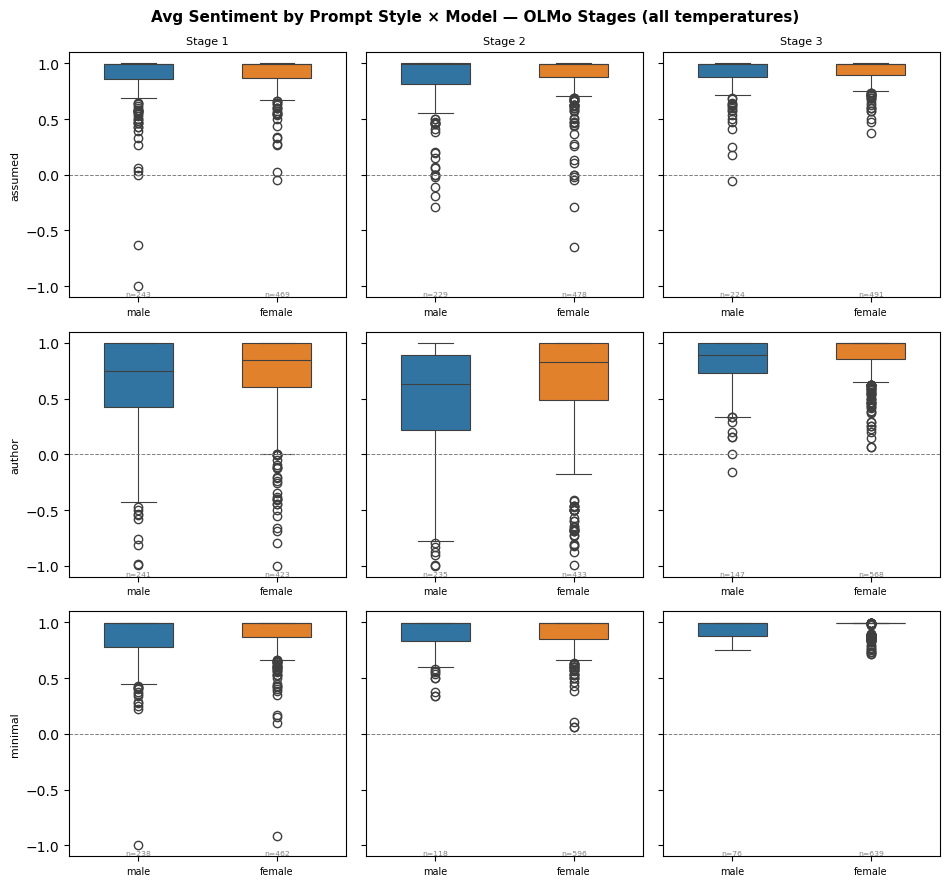

In [22]:
_varied_styles = ["assumed", "author", "minimal"]   # only styles with varied-temperature data

plot_by_prompt_style_grid(
    df_mf[df_mf["prompt_style"].isin(_varied_styles) & (df_mf["model_group"] == "base_models")],
    MODELS_BASE, MODEL_LABELS_BASE, "avg_sentiment",
    "Avg Sentiment by Prompt Style × Model — Base Models (all temperatures)",
)
plot_by_prompt_style_grid(
    df_mf[df_mf["prompt_style"].isin(_varied_styles) & (df_mf["model_group"] == "olmo")],
    MODELS_OLMO, MODEL_LABELS_OLMO, "avg_sentiment",
    "Avg Sentiment by Prompt Style × Model — OLMo Stages (all temperatures)",
)

### 3b. Sentiment by Gender × Prompt Style (T=0.7 fixed, all 6 styles)

All 6 prompt styles at a fixed temperature of 0.7 — the only regime where `neutral`, `frog`, and `generic` exist. `frog` and `generic` (top two rows) serve as baselines with no occupational context; compare them to the occupation-having styles below to isolate the occupational bias contribution to sentiment.

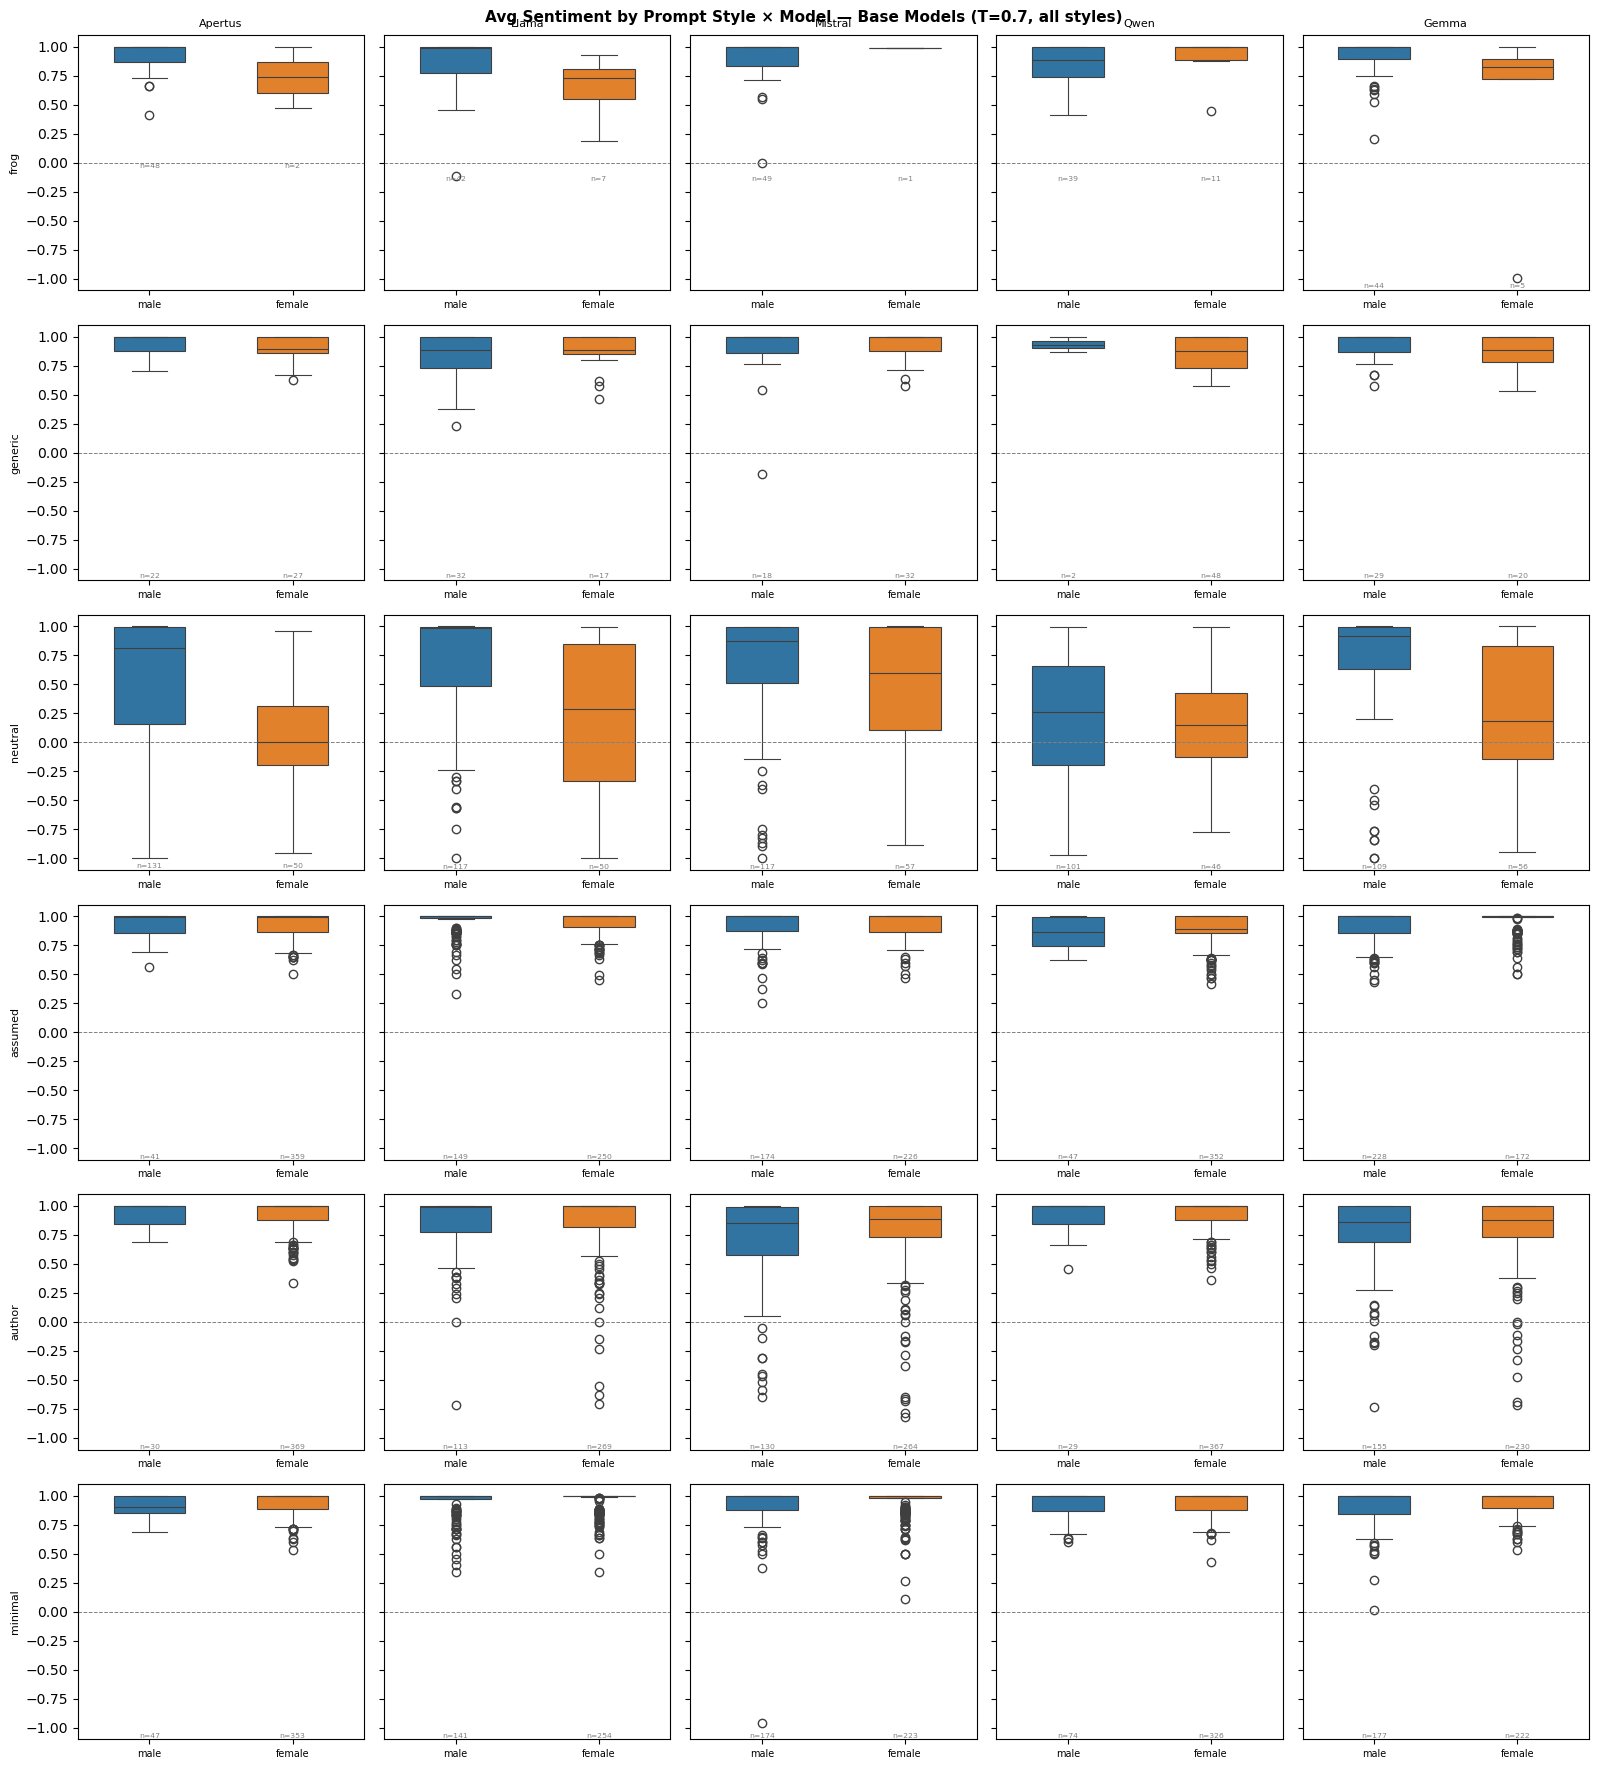

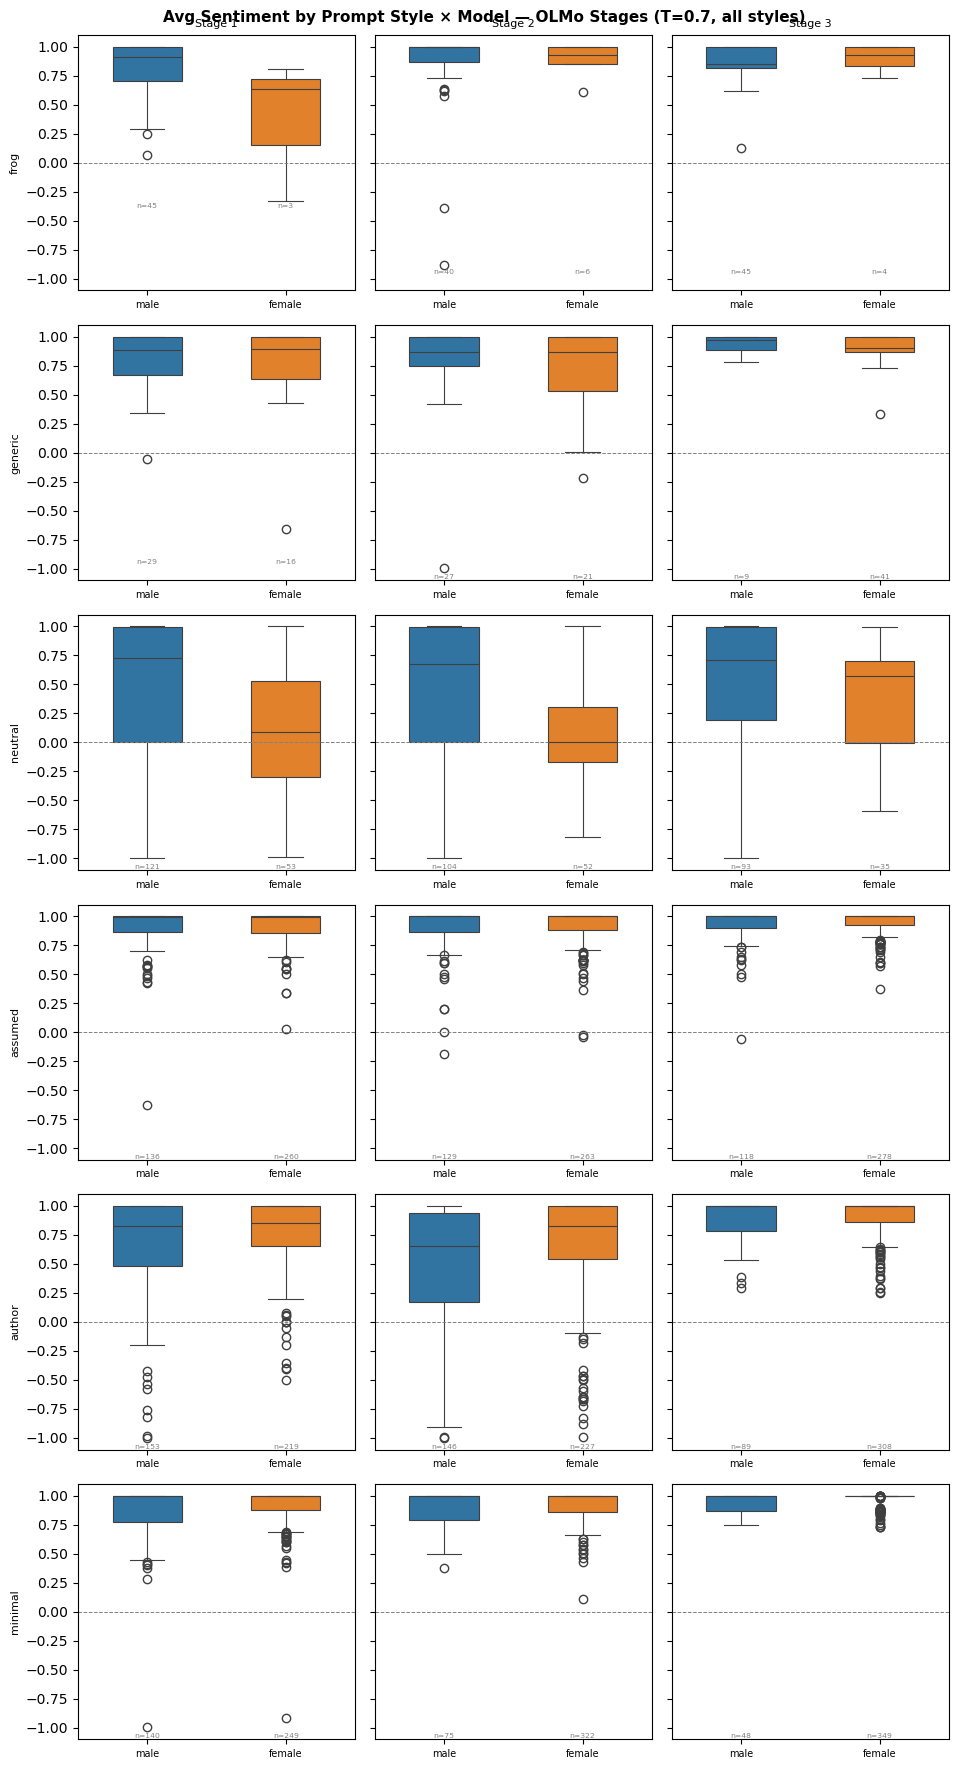

In [23]:
plot_by_prompt_style_grid(
    df_t7_mf[df_t7_mf["model_group"] == "base_models"],
    MODELS_BASE, MODEL_LABELS_BASE, "avg_sentiment",
    "Avg Sentiment by Prompt Style × Model — Base Models (T=0.7, all styles)",
)
plot_by_prompt_style_grid(
    df_t7_mf[df_t7_mf["model_group"] == "olmo"],
    MODELS_OLMO, MODEL_LABELS_OLMO, "avg_sentiment",
    "Avg Sentiment by Prompt Style × Model — OLMo Stages (T=0.7, all styles)",
)

## 4a. Regard Polarity by Gender × Prompt Style (all temperatures)

Same structure as Section 3a but for `regard_polarity`. Only `assumed`, `author`, `minimal` — the styles with varied-temperature data. See **Section 4b** for T=0.7 comparison with all 6 styles.

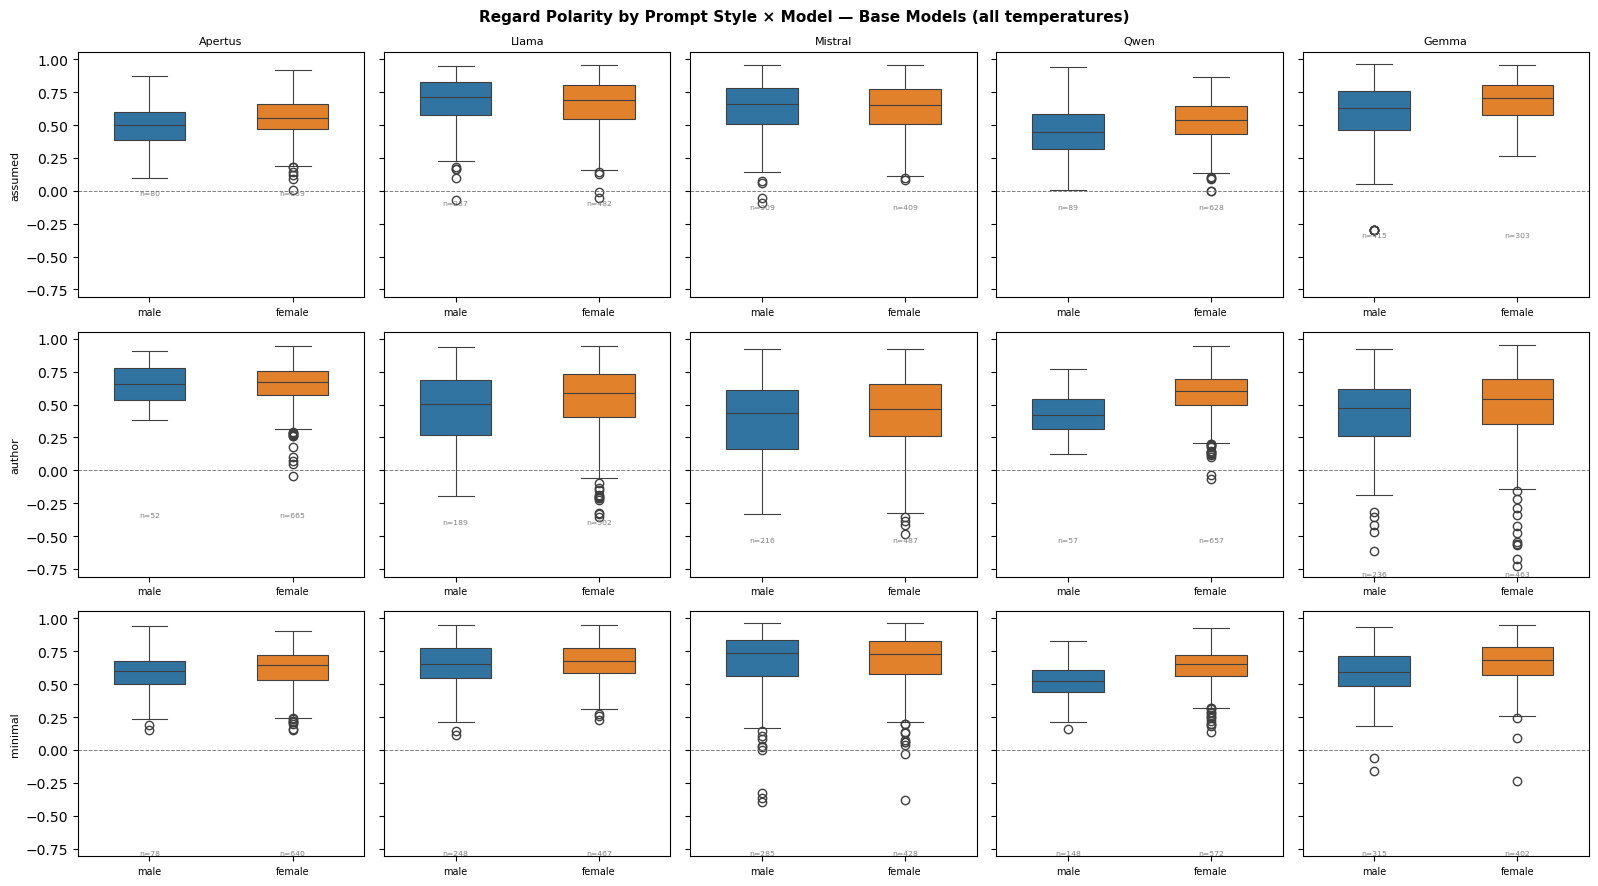

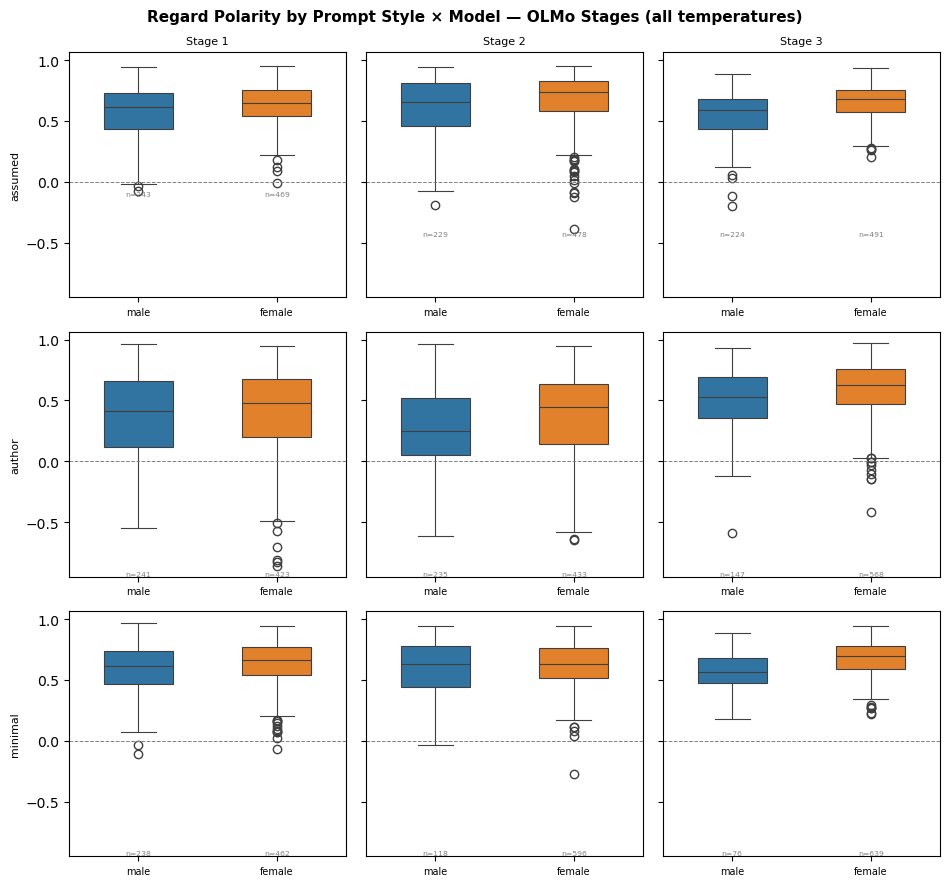

In [24]:
plot_by_prompt_style_grid(
    df_mf[df_mf["prompt_style"].isin(_varied_styles) & (df_mf["model_group"] == "base_models")],
    MODELS_BASE, MODEL_LABELS_BASE, "regard_polarity",
    "Regard Polarity by Prompt Style × Model — Base Models (all temperatures)",
)
plot_by_prompt_style_grid(
    df_mf[df_mf["prompt_style"].isin(_varied_styles) & (df_mf["model_group"] == "olmo")],
    MODELS_OLMO, MODEL_LABELS_OLMO, "regard_polarity",
    "Regard Polarity by Prompt Style × Model — OLMo Stages (all temperatures)",
)

### 4b. Regard Polarity by Gender × Prompt Style (T=0.7 fixed, all 6 styles)

All 6 prompt styles at T=0.7. `frog`/`generic` rows serve as no-occupation baselines; the shift in regard polarity as we move down to occupation-having styles shows the occupational bias contribution.

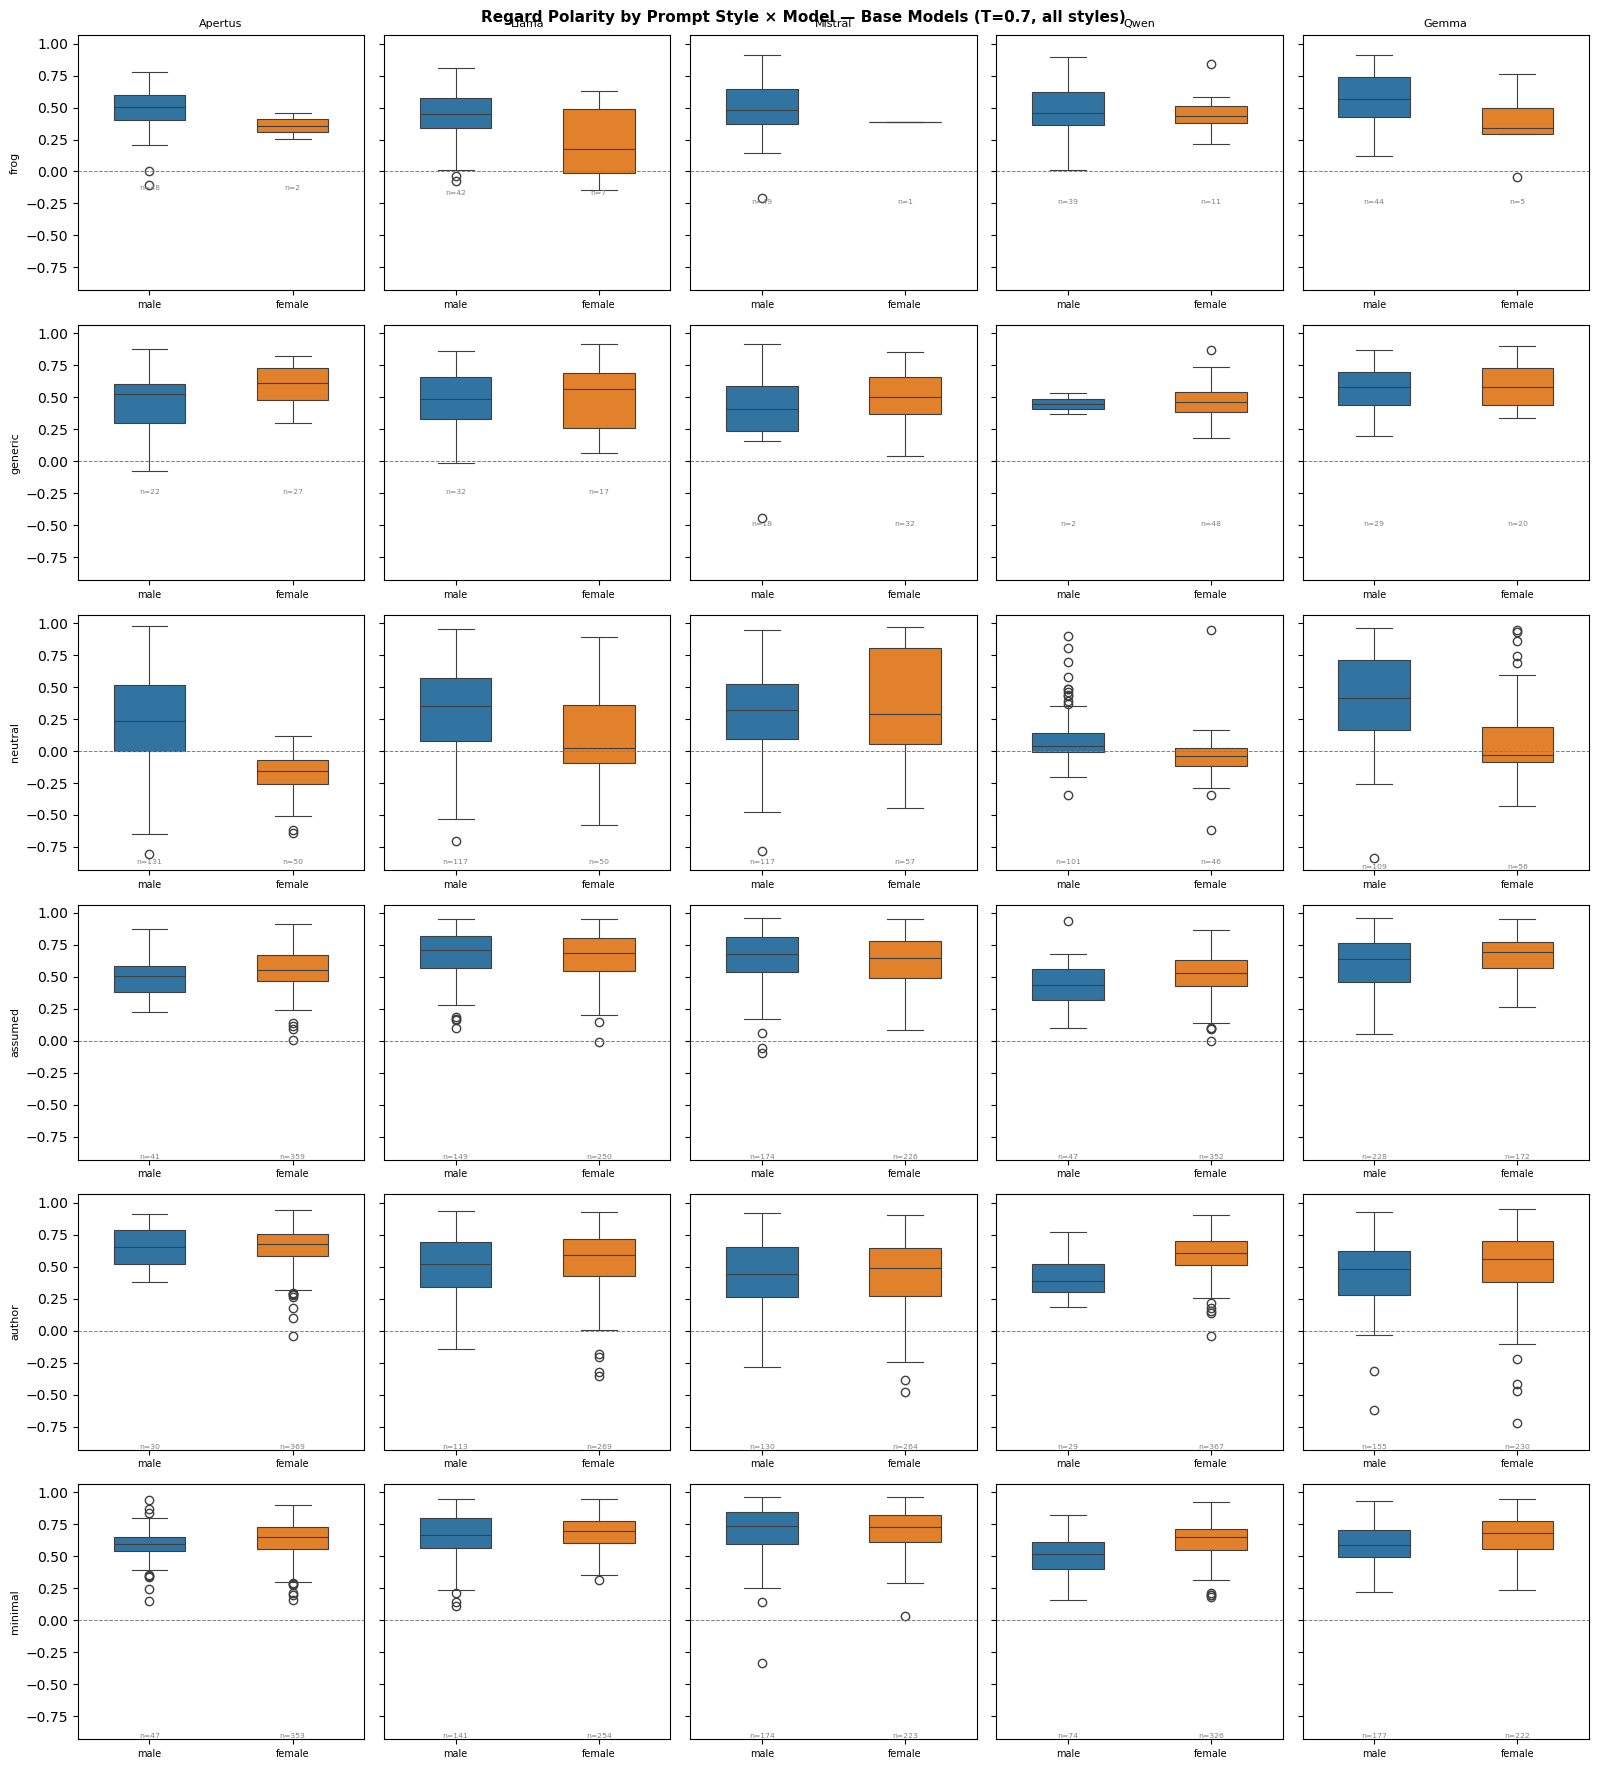

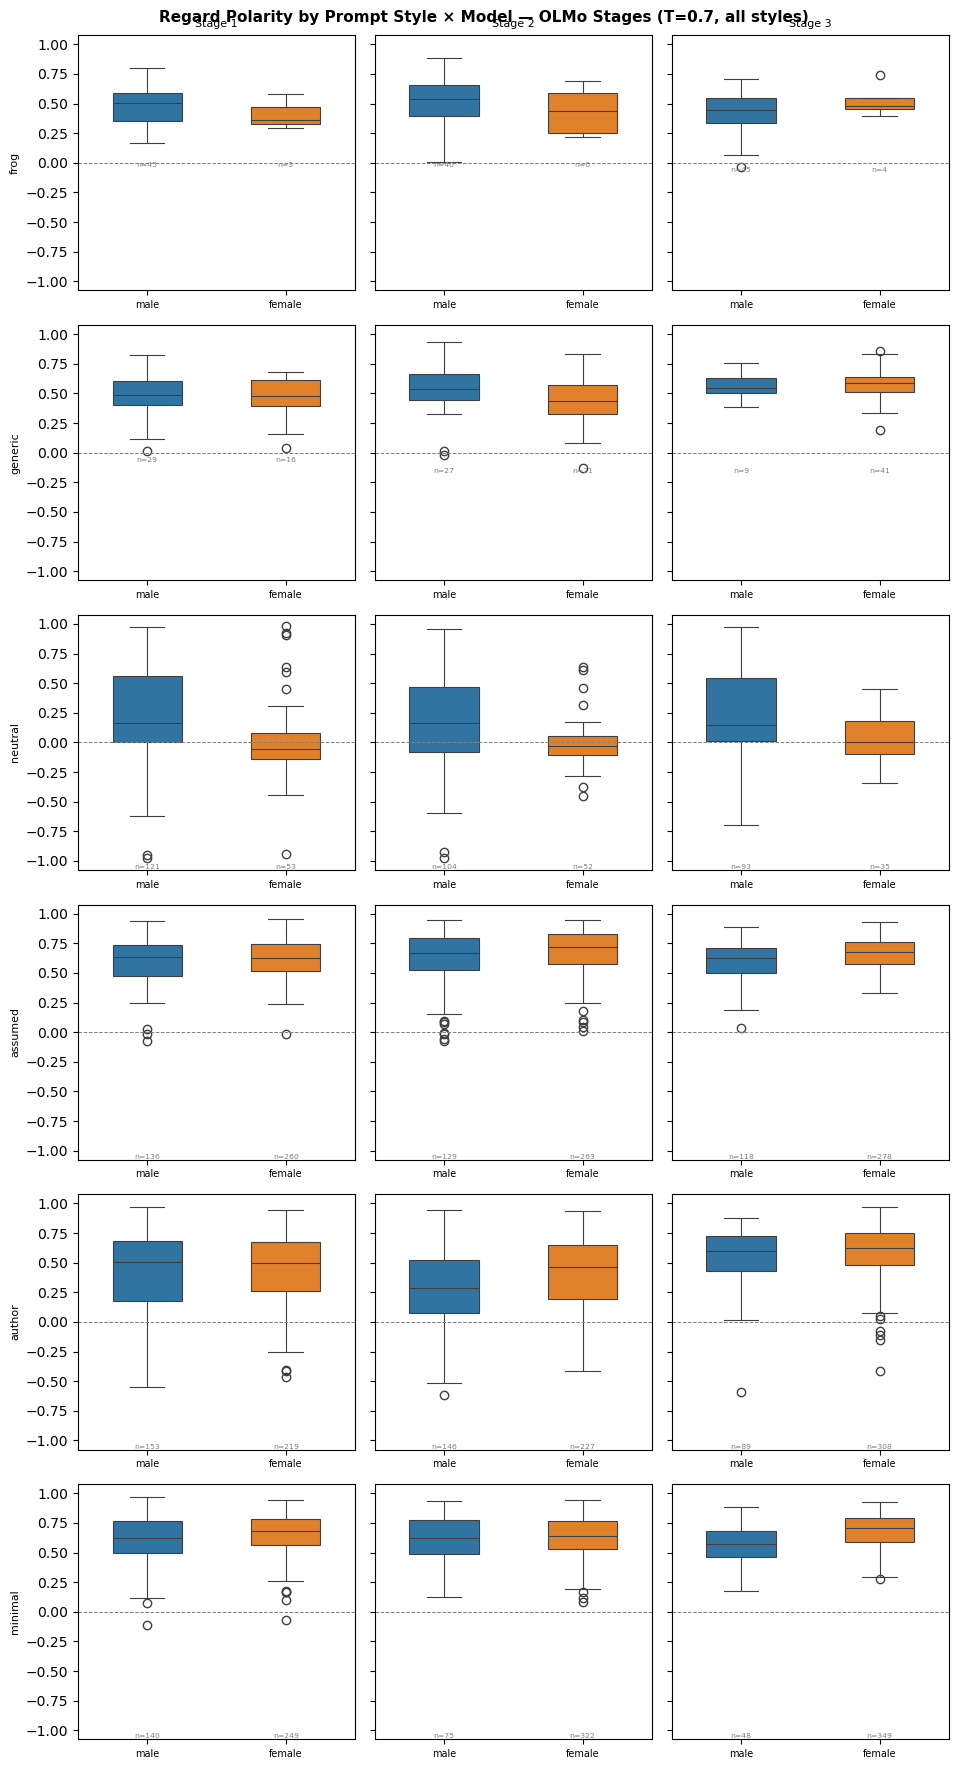

In [25]:
plot_by_prompt_style_grid(
    df_t7_mf[df_t7_mf["model_group"] == "base_models"],
    MODELS_BASE, MODEL_LABELS_BASE, "regard_polarity",
    "Regard Polarity by Prompt Style × Model — Base Models (T=0.7, all styles)",
)
plot_by_prompt_style_grid(
    df_t7_mf[df_t7_mf["model_group"] == "olmo"],
    MODELS_OLMO, MODEL_LABELS_OLMO, "regard_polarity",
    "Regard Polarity by Prompt Style × Model — OLMo Stages (T=0.7, all styles)",
)

## 5. Gender Gap Heatmaps by Prompt Style

`female_mean − male_mean` per (occupation, model). Blank cells: either gender < `MIN_N`.
Annotation: gap value + `(nF/nM)` sample counts.


In [8]:
def gender_gap_masked(data, metric, model_order):
    grp    = data.groupby(["occupation", "model_key", "gender"])[metric]
    means  = grp.mean().unstack("gender")
    counts = grp.count().unstack("gender")
    for col in ["male", "female"]:
        if col not in means.columns:
            means[col] = float("nan"); counts[col] = 0
    gap = (means["female"] - means["male"]).unstack("model_key")
    n_f = counts["female"].unstack("model_key").reindex(index=OCCUPATIONS, columns=model_order).fillna(0).astype(int)
    n_m = counts["male"].unstack("model_key").reindex(index=OCCUPATIONS, columns=model_order).fillna(0).astype(int)
    gap = gap.reindex(index=OCCUPATIONS, columns=model_order)
    return gap.where((n_f >= MIN_N) & (n_m >= MIN_N)), n_f, n_m


def plot_gap_heatmaps_by_style(data, models, model_labels, metric, suptitle):
    avail_styles = [s for s in OCCUPATION_STYLES if s in data["prompt_style"].unique()]
    sub_mf = data[data["gender"].isin(["male", "female"])]
    n_cols = len(avail_styles)
    fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 0.5 * len(OCCUPATIONS) + 2),
                             sharey=True)
    axes = np.atleast_1d(axes)

    for i, (ax, style) in enumerate(zip(axes, avail_styles)):
        sub = sub_mf[sub_mf["prompt_style"] == style]
        gap_masked, n_f, n_m = gender_gap_masked(sub, metric, models)
        lmap = {m: model_labels.get(m, m) for m in models}
        annot = pd.DataFrame("", index=gap_masked.index, columns=gap_masked.columns)
        for occ in gap_masked.index:
            for model in gap_masked.columns:
                nf = n_f.loc[occ, model]; nm = n_m.loc[occ, model]
                val = gap_masked.loc[occ, model]
                annot.loc[occ, model] = (
                    f"{val:.3f}\n({nf}/{nm})" if not pd.isna(val) else f"({nf}/{nm})"
                )
        sns.heatmap(
            gap_masked.rename(columns=lmap, index=str.capitalize),
            cmap="coolwarm", center=0,
            annot=annot.rename(columns=lmap, index=str.capitalize),
            fmt="", linewidths=0.3, linecolor="white", ax=ax,
            cbar_kws={"label": "Δ (F−M)"},
        )
        ax.set_title(style); ax.set_xlabel("Model")
        if i > 0:
            ax.set_ylabel("")

    fig.suptitle(f"{suptitle}\n(blank = n<{MIN_N}; annotation: Δ, (nF/nM))",
                 fontsize=11, fontweight="bold")
    fig.tight_layout(); plt.show()


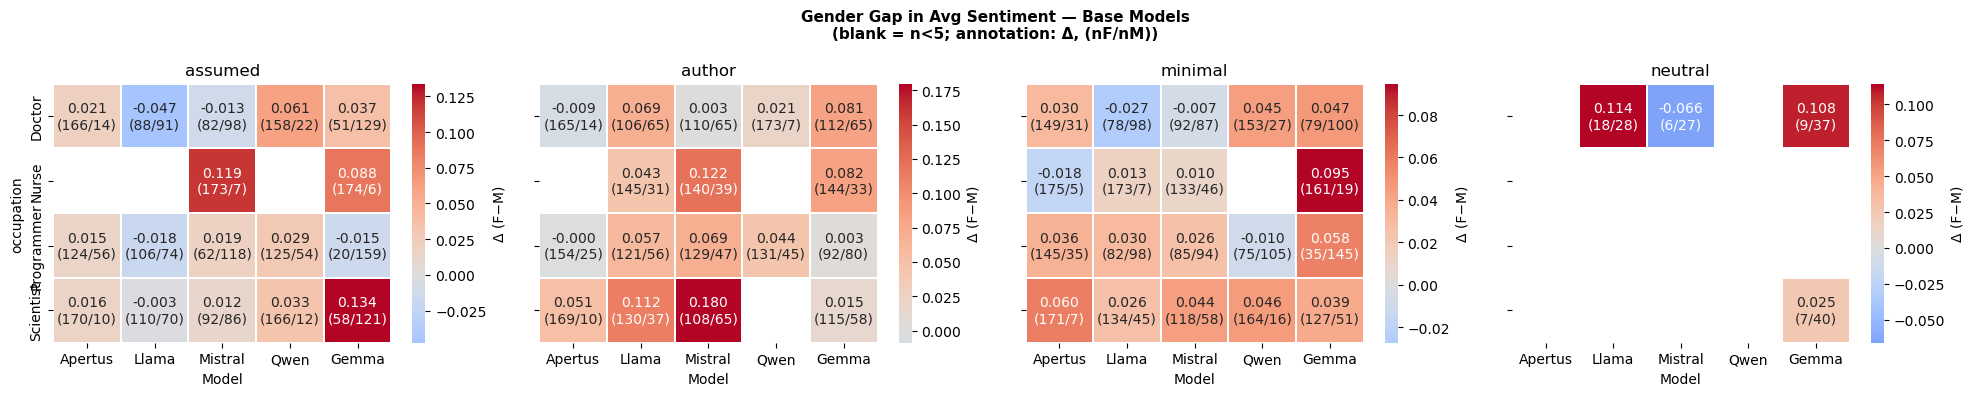

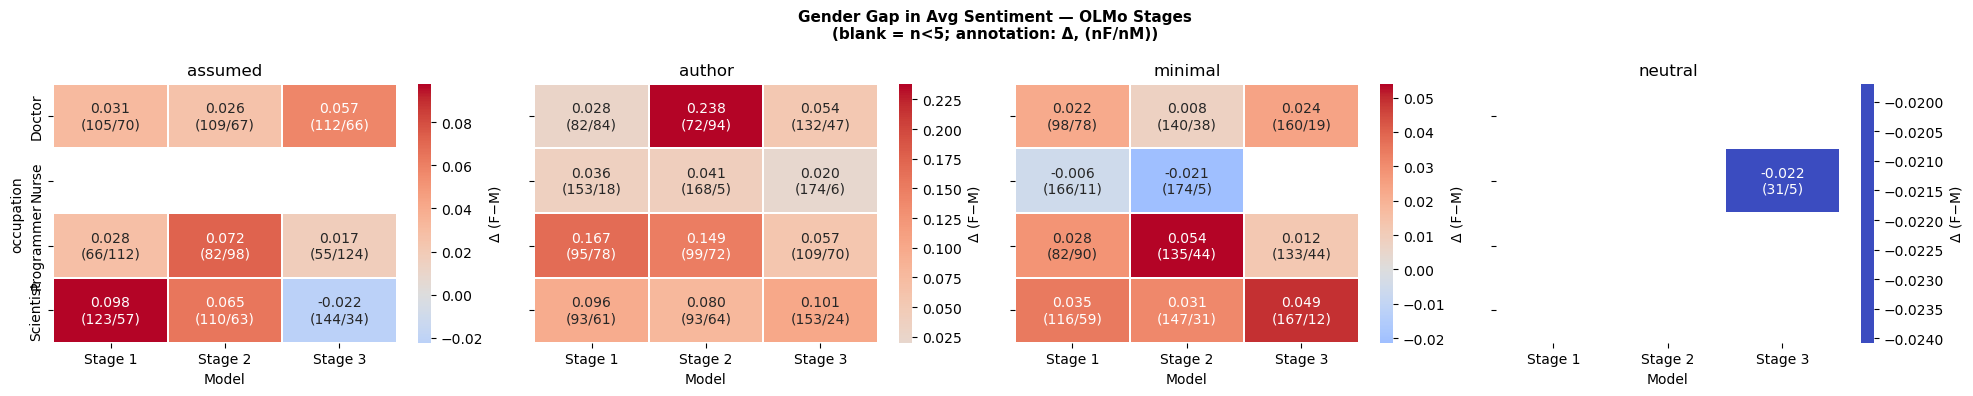

In [9]:
plot_gap_heatmaps_by_style(
    df_occ_mf[df_occ_mf["model_group"] == "base_models"],
    MODELS_BASE, MODEL_LABELS_BASE, "avg_sentiment",
    "Gender Gap in Avg Sentiment — Base Models",
)
plot_gap_heatmaps_by_style(
    df_occ_mf[df_occ_mf["model_group"] == "olmo"],
    MODELS_OLMO, MODEL_LABELS_OLMO, "avg_sentiment",
    "Gender Gap in Avg Sentiment — OLMo Stages",
)


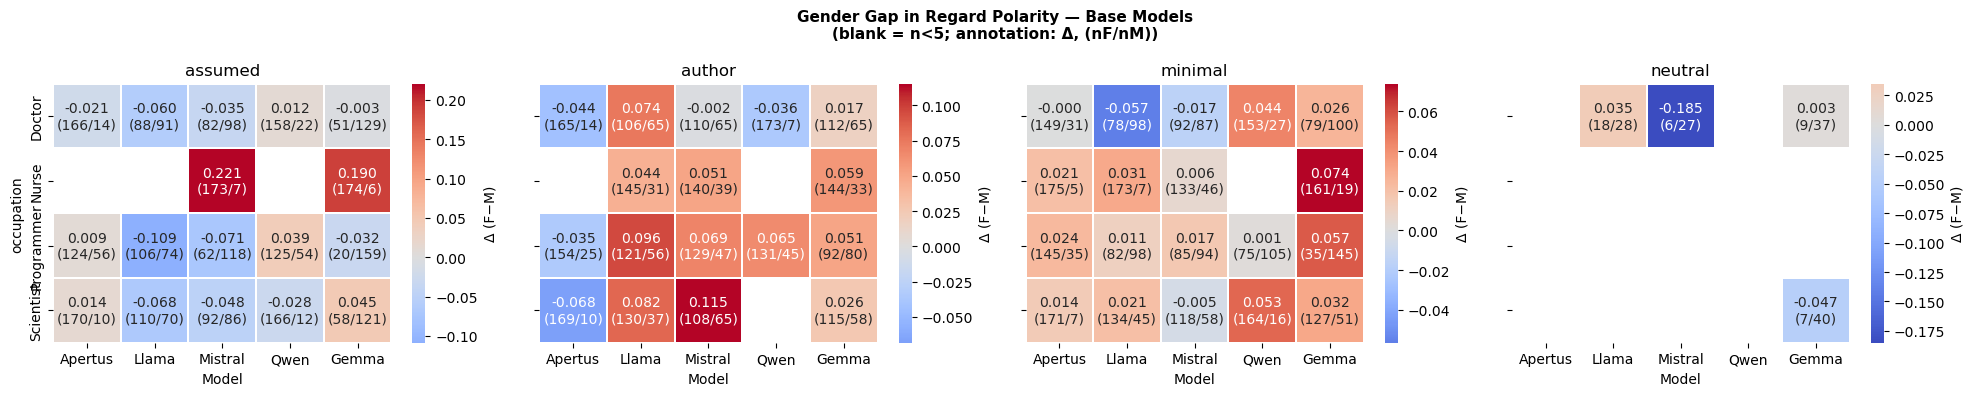

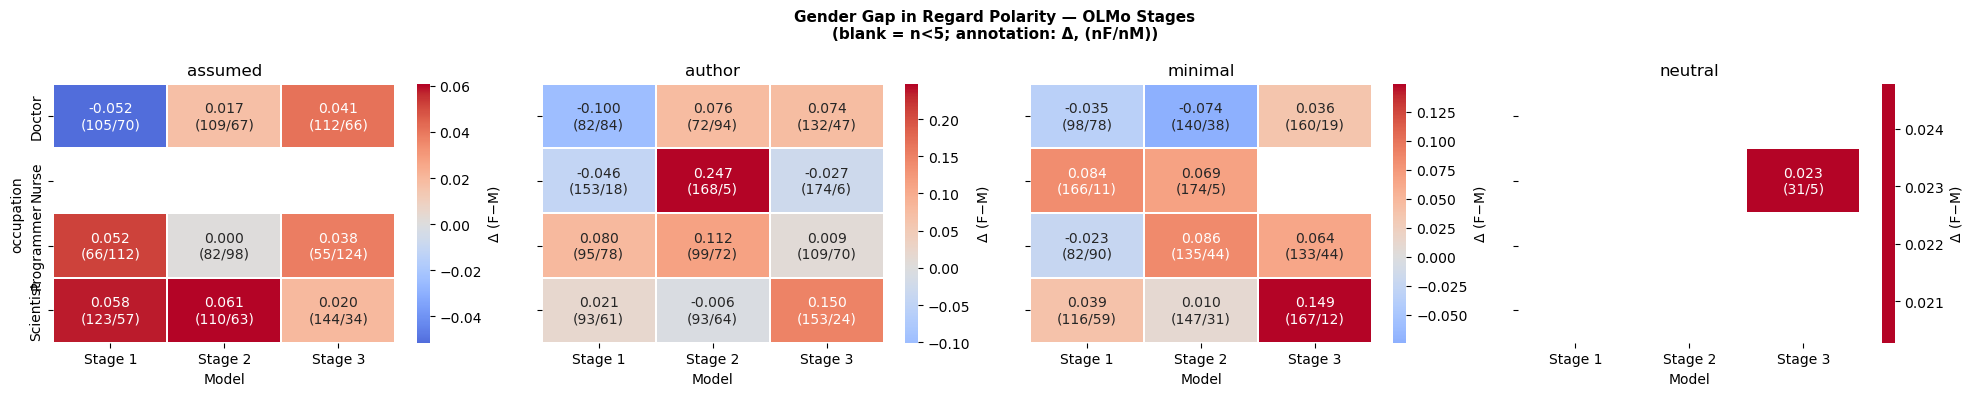

In [10]:
plot_gap_heatmaps_by_style(
    df_occ_mf[df_occ_mf["model_group"] == "base_models"],
    MODELS_BASE, MODEL_LABELS_BASE, "regard_polarity",
    "Gender Gap in Regard Polarity — Base Models",
)
plot_gap_heatmaps_by_style(
    df_occ_mf[df_occ_mf["model_group"] == "olmo"],
    MODELS_OLMO, MODEL_LABELS_OLMO, "regard_polarity",
    "Gender Gap in Regard Polarity — OLMo Stages",
)


## 6. Prompt Style Effect on Gender Gap (Occupation-Having Styles)

Does switching from `assumed` → `author` → `minimal` → `neutral` reduce or amplify the bias?
Each line is one model; y-axis is `female_mean − male_mean` averaged over all occupations (all temperature regimes).
See Section 8 for the T=0.7 fixed comparison that extends to `frog`/`generic`.

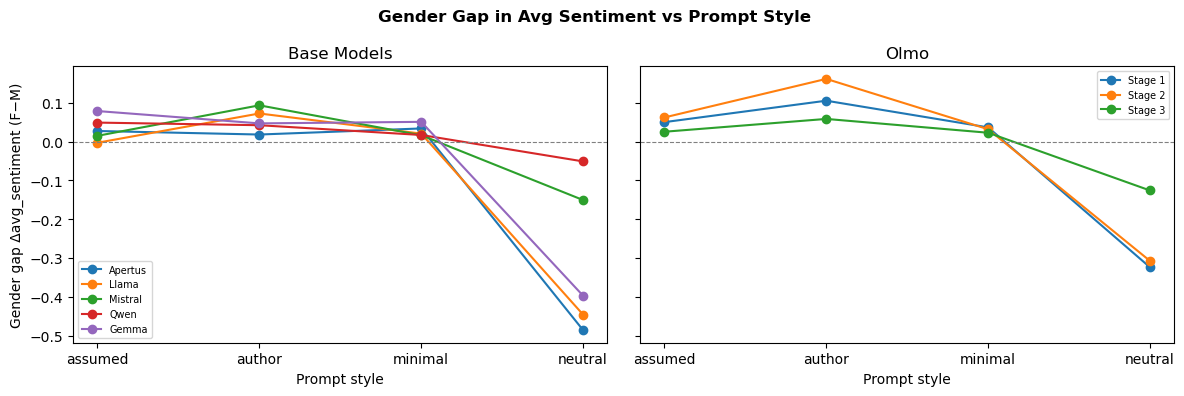

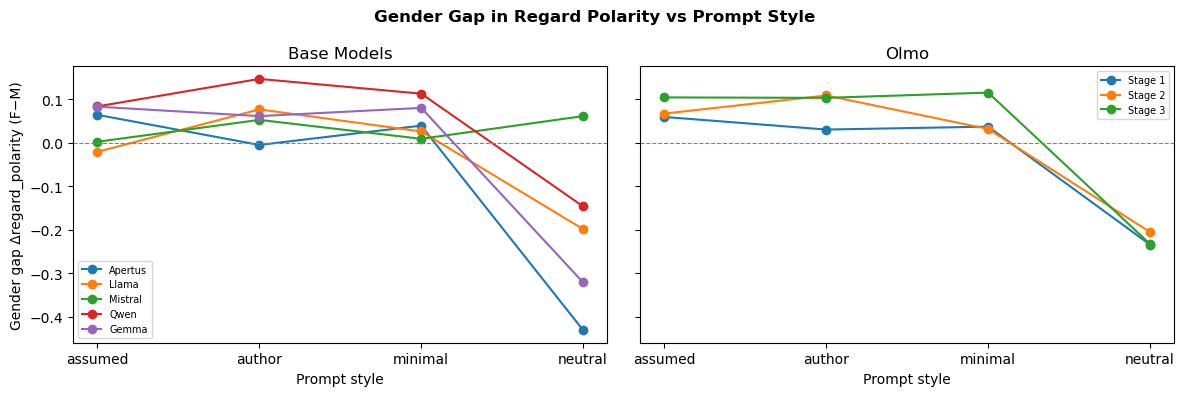

In [11]:
def plot_gap_vs_prompt_style(metric, title):
    avail_styles = [s for s in OCCUPATION_STYLES if s in df_occ_mf["prompt_style"].unique()]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    for ax, (group_name, models, lmap) in zip(axes, [
        ("base_models", MODELS_BASE, MODEL_LABELS_BASE),
        ("olmo",        MODELS_OLMO, MODEL_LABELS_OLMO),
    ]):
        grp_data = df_occ_mf[df_occ_mf["model_group"] == group_name]
        for model in models:
            gaps = []
            for style in avail_styles:
                sub = grp_data[(grp_data["model_key"] == model) & (grp_data["prompt_style"] == style)]
                if len(sub) == 0:
                    gaps.append(float("nan")); continue
                fm = sub[sub["gender"] == "female"][metric].mean()
                mm = sub[sub["gender"] == "male"][metric].mean()
                gaps.append(float("nan") if pd.isna(fm) or pd.isna(mm) else fm - mm)
            ax.plot(avail_styles, gaps, marker="o", label=lmap.get(model, model))
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
        ax.set_title(group_name.replace("_", " ").title())
        ax.set_xlabel("Prompt style"); ax.legend(fontsize=7)

    axes[0].set_ylabel(f"Gender gap Δ{metric} (F−M)")
    fig.suptitle(title, fontsize=12, fontweight="bold")
    fig.tight_layout(); plt.show()

plot_gap_vs_prompt_style("avg_sentiment",   "Gender Gap in Avg Sentiment vs Prompt Style")
plot_gap_vs_prompt_style("regard_polarity", "Gender Gap in Regard Polarity vs Prompt Style")


## 7. Unified Cross-Style Comparison (T=0.7 Fixed, Pooled)

All 6 prompt styles compared on the same axis, pooled across occupations (T=0.7 fixed only, since
`frog`/`generic` appear exclusively in the `_t7` files). Pooling removes occupation as a confound so all styles are on equal footing.

**Factorial structure of prompt styles:**

| | No occupation | Has occupation |
|---|---|---|
| **Narrative framing** | `frog` (non-human subject), `generic` (human subject) | `assumed`, `author`, `minimal` |
| **No narrative framing** | — | `neutral` |

Key contrasts readable in these plots:
- **Narrative framing effect**: `generic` vs `neutral` (same human context; varies framing — if `generic` is more positive, the narrative framing itself inflates sentiment)
- **Occupation effect on sentiment**: `assumed`/`author`/`minimal` vs `generic` (same narrative; only occupation differs)
- **Human-subject baseline**: `frog` vs `generic` (both narrative, no occupation — tests whether positivity is tied to a human subject)

Vertical dotted lines separate the three zones.

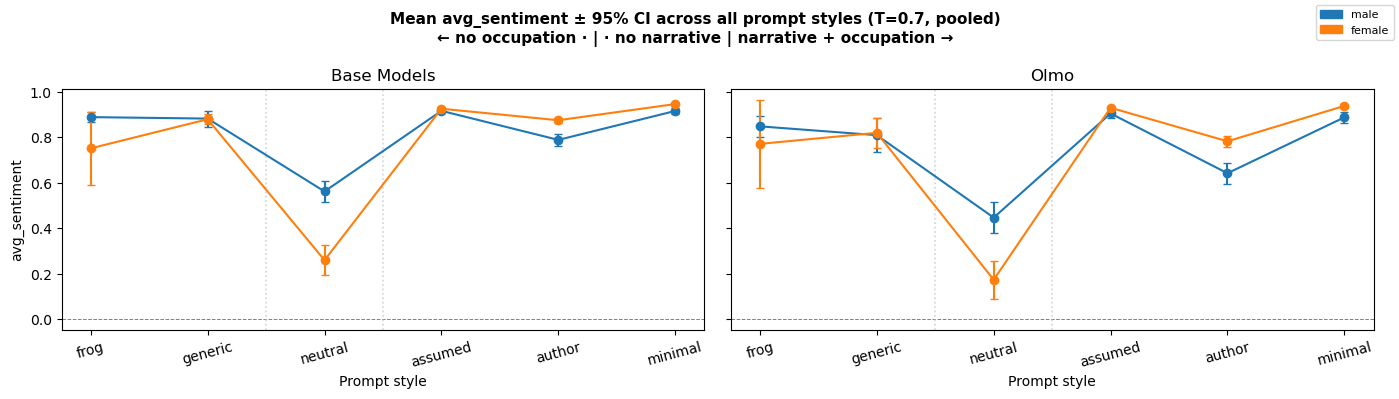

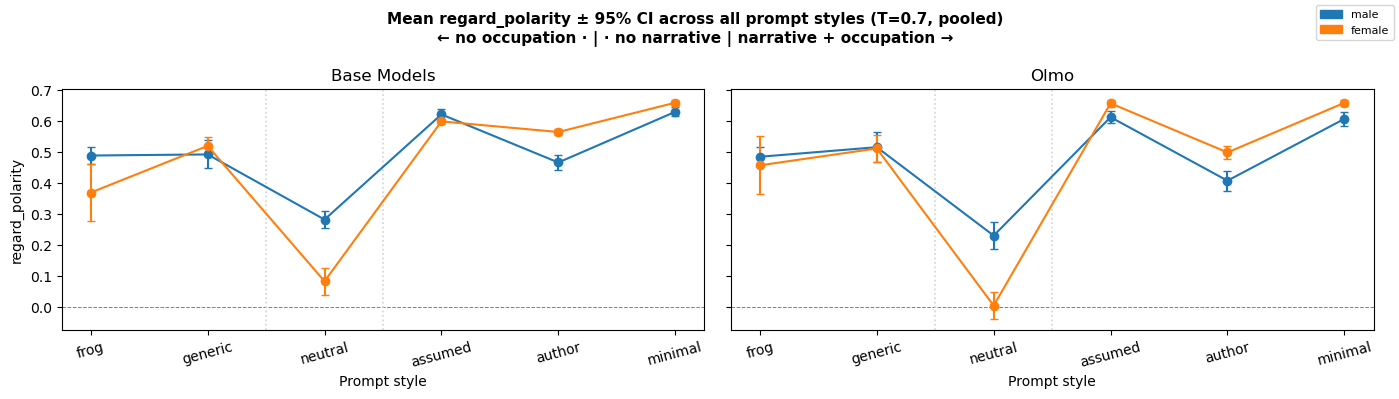

In [12]:
avail_styles = [s for s in PROMPT_STYLE_ORDER if s in df_t7_mf["prompt_style"].unique()]

def _add_zone_lines(ax, styles):
    """Add vertical dotted separators between the three prompt-style zones."""
    pairs = [("generic", "neutral"), ("neutral", "assumed")]
    for left, right in pairs:
        if left in styles and right in styles:
            li, ri = styles.index(left), styles.index(right)
            ax.axvline((li + ri) / 2, color="lightgray", linestyle=":", linewidth=1.2)

for metric in ["avg_sentiment", "regard_polarity"]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

    for ax, (group_name, models, lmap) in zip(axes, [
        ("base_models", MODELS_BASE, MODEL_LABELS_BASE),
        ("olmo",        MODELS_OLMO, MODEL_LABELS_OLMO),
    ]):
        sub = df_t7_mf[df_t7_mf["model_group"] == group_name]
        for gender, color in GENDER_COLORS.items():
            sg = sub[sub["gender"] == gender]
            means = sg.groupby("prompt_style")[metric].mean().reindex(avail_styles)
            sems  = sg.groupby("prompt_style")[metric].sem().reindex(avail_styles) * 1.96
            ax.errorbar(avail_styles, means, yerr=sems,
                        marker="o", label=gender, color=color, capsize=3, linewidth=1.5)
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.7)
        _add_zone_lines(ax, avail_styles)
        ax.set_title(group_name.replace("_", " ").title())
        ax.set_xlabel("Prompt style")
        ax.tick_params(axis="x", rotation=15)

    axes[0].set_ylabel(metric)
    handles = [mpatches.Patch(color=c, label=g) for g, c in GENDER_COLORS.items()]
    fig.legend(handles=handles, loc="upper right", fontsize=8)
    fig.suptitle(
        f"Mean {metric} ± 95% CI across all prompt styles (T=0.7, pooled)\n"
        "← no occupation · | · no narrative | narrative + occupation →",
        fontsize=11, fontweight="bold",
    )
    fig.tight_layout()
    plt.show()

## 8. Gender Gap Across All Prompt Styles (T=0.7 Fixed)

`female_mean − male_mean` for each model across all 6 prompt styles. **`frog` is the noise floor**:
any M-F gap there is a baseline pronoun-association artifact unrelated to occupation.
The gap that opens up as we move rightward (toward occupation-having styles) reveals the occupational bias contribution.
Zone separators (dotted lines) mark: no-occupation | occupation-but-no-narrative | occupation+narrative.

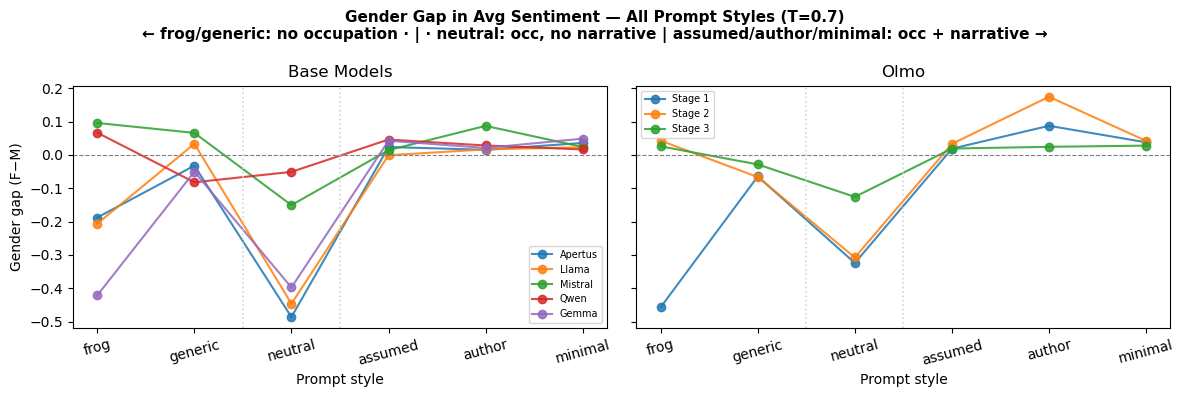

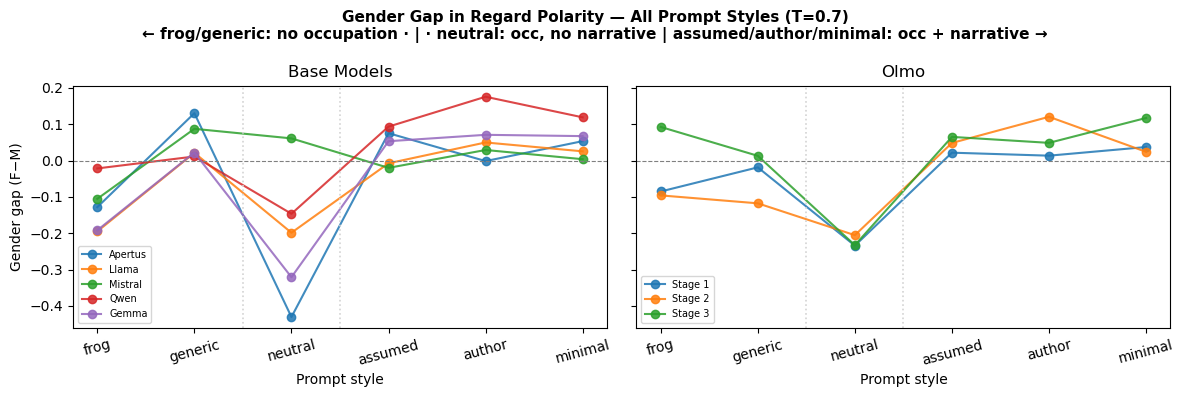

In [13]:
def plot_gender_gap_all_styles(metric, title):
    avail = [s for s in PROMPT_STYLE_ORDER if s in df_t7_mf["prompt_style"].unique()]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    for ax, (group_name, models, lmap) in zip(axes, [
        ("base_models", MODELS_BASE, MODEL_LABELS_BASE),
        ("olmo",        MODELS_OLMO, MODEL_LABELS_OLMO),
    ]):
        sub = df_t7_mf[df_t7_mf["model_group"] == group_name]
        for model in models:
            gaps = []
            for style in avail:
                cell = sub[(sub["model_key"] == model) & (sub["prompt_style"] == style)]
                fm = cell[cell["gender"] == "female"][metric].mean()
                mm = cell[cell["gender"] == "male"][metric].mean()
                gaps.append(float("nan") if (pd.isna(fm) or pd.isna(mm)) else fm - mm)
            ax.plot(avail, gaps, marker="o", label=lmap.get(model, model), alpha=0.85)
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
        _add_zone_lines(ax, avail)
        ax.set_title(group_name.replace("_", " ").title())
        ax.set_xlabel("Prompt style")
        ax.legend(fontsize=7)
        ax.tick_params(axis="x", rotation=15)

    axes[0].set_ylabel("Gender gap (F−M)")
    fig.suptitle(
        f"{title}\n"
        "← frog/generic: no occupation · | · neutral: occ, no narrative | assumed/author/minimal: occ + narrative →",
        fontsize=11, fontweight="bold",
    )
    fig.tight_layout()
    plt.show()

plot_gender_gap_all_styles("avg_sentiment",   "Gender Gap in Avg Sentiment — All Prompt Styles (T=0.7)")
plot_gender_gap_all_styles("regard_polarity", "Gender Gap in Regard Polarity — All Prompt Styles (T=0.7)")

## 9. Gender-Score Sensitivity

Rows with low `gender_score` have ambiguous pronoun signals. This checks whether
classifier confidence correlates with the sentiment/regard of those responses.

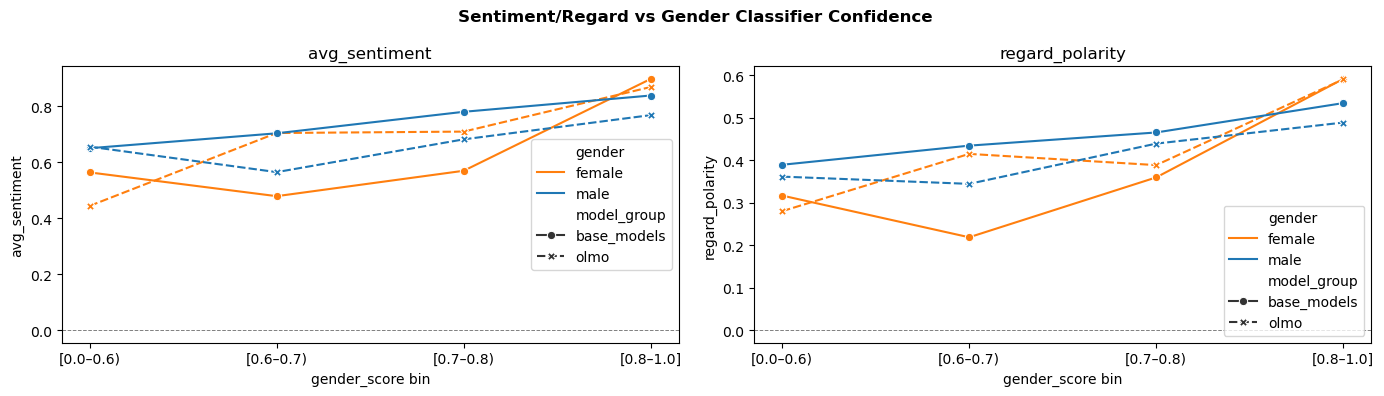


Row counts per gender_score bin × model_group:
gender                 female  male
gs_bin    model_group              
[0.0–0.6) base_models     104   178
          olmo             71   154
[0.6–0.7) base_models      60   142
          olmo             48   117
[0.7–0.8) base_models      97   137
          olmo             83   132
[0.8–1.0] base_models    7912  3397
          olmo           4588  1861


In [14]:
if "gender_score" in df_mf.columns:
    bins   = [0.0, 0.6, 0.7, 0.8, 1.01]
    labels = ["[0.0–0.6)", "[0.6–0.7)", "[0.7–0.8)", "[0.8–1.0]"]
    df_mf["gs_bin"] = pd.cut(df_mf["gender_score"], bins=bins, labels=labels, right=False)

    summary = (
        df_mf[df_mf["gender"].isin(["male", "female"])]
        .groupby(["gs_bin", "gender", "model_group"], observed=True)[["avg_sentiment", "regard_polarity"]]
        .mean().reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, metric in zip(axes, ["avg_sentiment", "regard_polarity"]):
        sns.lineplot(data=summary, x="gs_bin", y=metric, hue="gender",
                     style="model_group", palette=GENDER_COLORS, markers=True, ax=ax)
        ax.axhline(0, color="gray", linestyle="--", linewidth=0.7)
        ax.set_title(metric); ax.set_xlabel("gender_score bin")

    fig.suptitle("Sentiment/Regard vs Gender Classifier Confidence",
                 fontsize=12, fontweight="bold")
    fig.tight_layout(); plt.show()

    print("\nRow counts per gender_score bin × model_group:")
    print(
        df_mf.groupby(["gs_bin", "model_group"], observed=True)["gender"]
        .value_counts().unstack(fill_value=0)
    )
else:
    print("gender_score column not found in loaded data.")


## 10. Entropy Sensitivity

Does mean per-token generation entropy correlate with sentiment/regard?
`mean_entropy` is extracted from the nested `entropy_analysis` field.
Quintile 1 (Q1) = most deterministic; Q5 = most uncertain.
Pooled across all prompt styles and occupations.

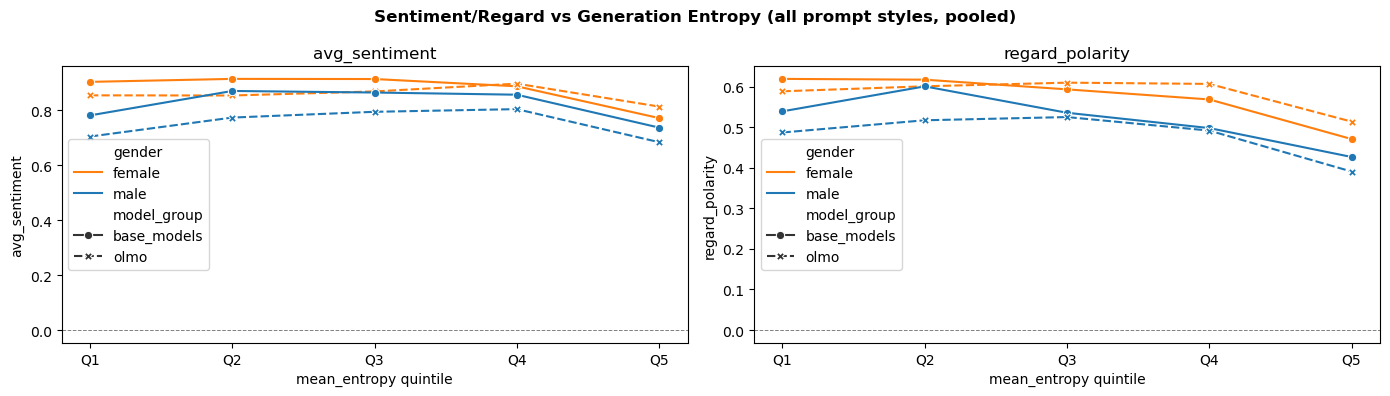


Row counts per entropy_bin × model_group:
gender                   female  male
entropy_bin model_group              
Q1          base_models    1763   670
            olmo           1010   374
Q2          base_models    1853   889
            olmo            725   349
Q3          base_models    2015   834
            olmo            609   358
Q4          base_models    1362   632
            olmo           1323   499
Q5          base_models    1180   829
            olmo           1123   684


In [15]:
df_mf["mean_entropy"] = df_mf["entropy_analysis"].apply(
    lambda x: x.get("mean_entropy") if isinstance(x, dict) else float("nan")
)
df_mf["entropy_bin"] = pd.qcut(
    df_mf["mean_entropy"], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"], duplicates="drop"
)

summary_ent = (
    df_mf.groupby(["entropy_bin", "gender", "model_group"], observed=True)[
        ["avg_sentiment", "regard_polarity"]
    ].mean().reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric in zip(axes, ["avg_sentiment", "regard_polarity"]):
    sns.lineplot(data=summary_ent, x="entropy_bin", y=metric, hue="gender",
                 style="model_group", palette=GENDER_COLORS, markers=True, ax=ax)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.7)
    ax.set_title(metric)
    ax.set_xlabel("mean_entropy quintile")

fig.suptitle("Sentiment/Regard vs Generation Entropy (all prompt styles, pooled)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

print("\nRow counts per entropy_bin × model_group:")
print(
    df_mf.groupby(["entropy_bin", "model_group"], observed=True)["gender"]
    .value_counts().unstack(fill_value=0)
)

## 11. Response Diversity (Self-BLEU & Semantic Diversity)

`self_bleu` and `semantic_div` are group-level metrics broadcast to each row by
`scripts/metrics-regression/compute_diversity_metrics.py`.
- **self_bleu**: lower = responses within the group are more diverse
- **semantic_div**: higher = responses more semantically varied (avg pairwise cosine distance)

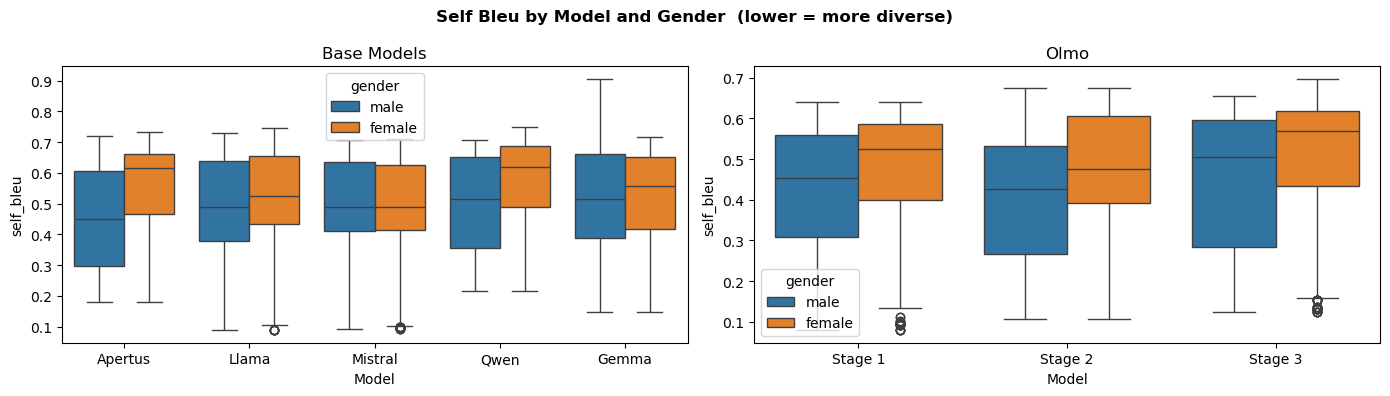

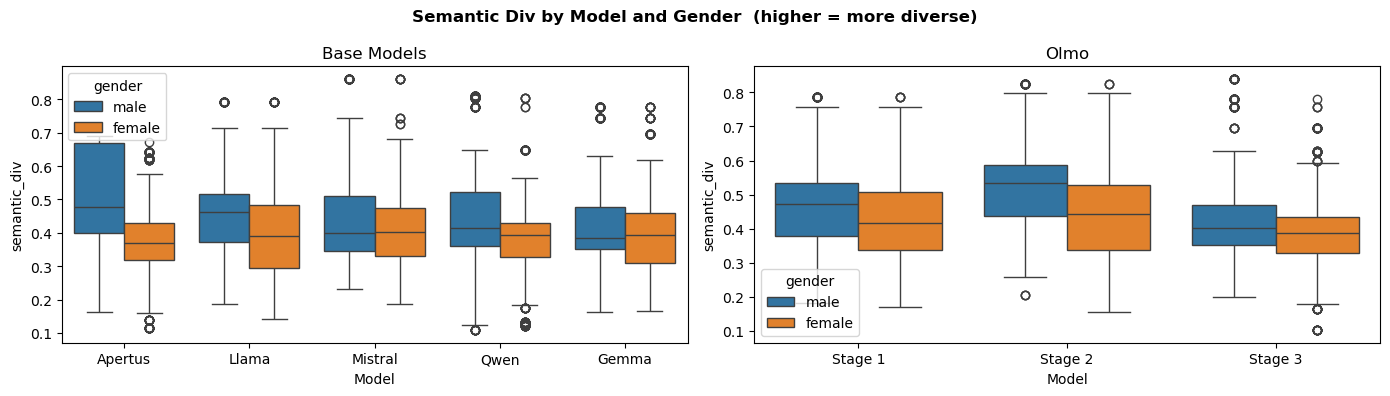

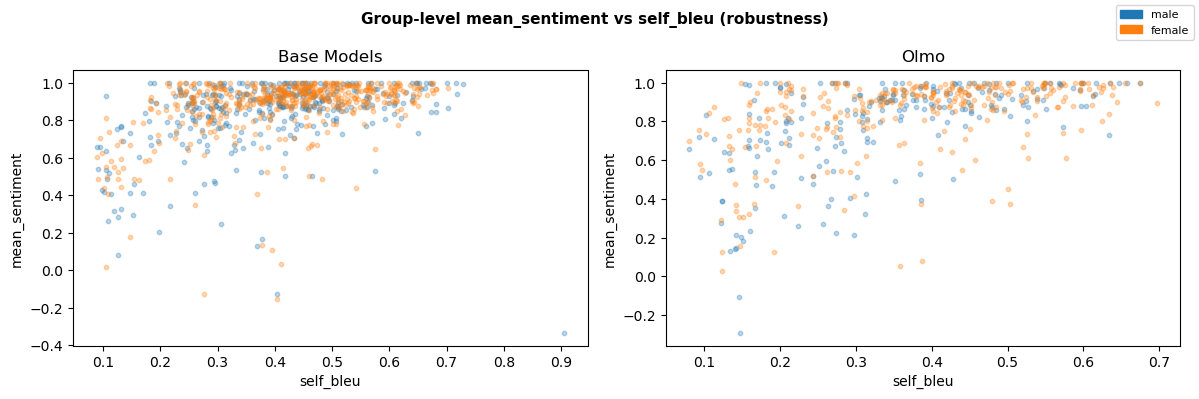

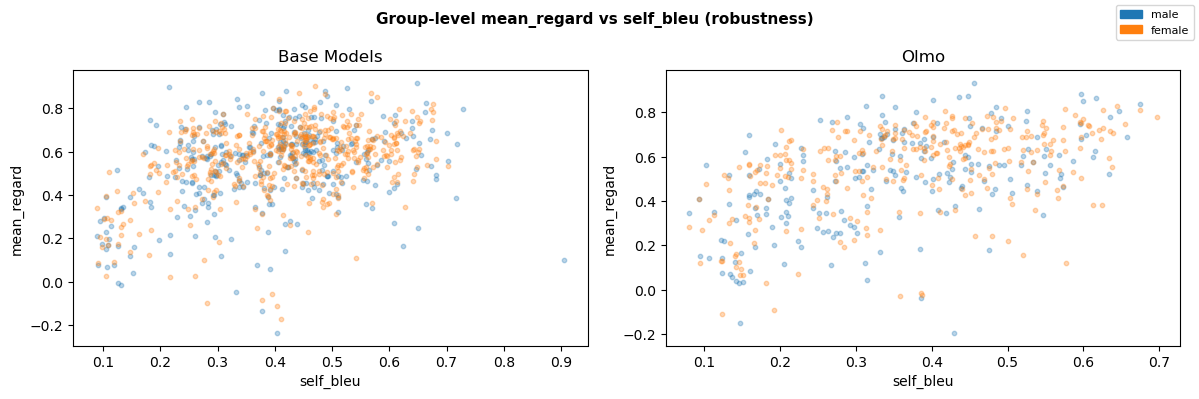

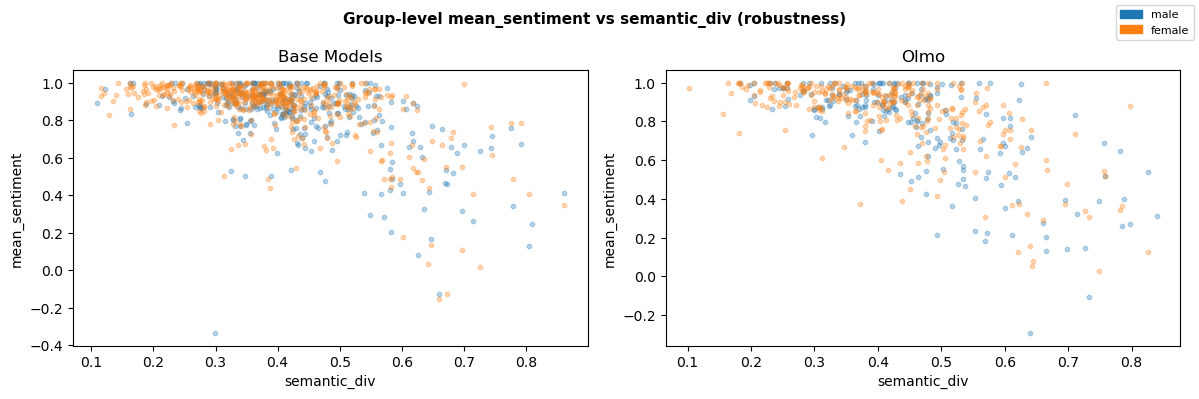

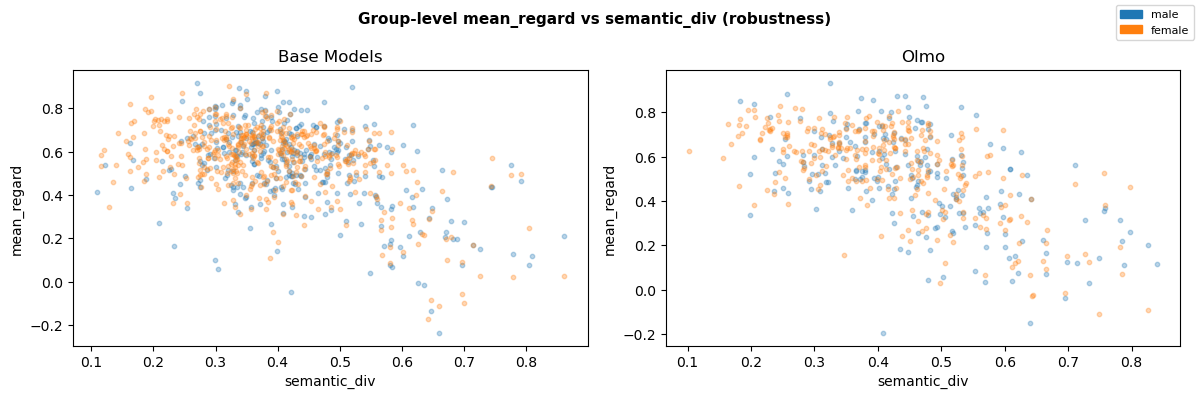

In [16]:
if "self_bleu" not in df_mf.columns or "semantic_div" not in df_mf.columns:
    print("self_bleu/semantic_div columns not found in loaded data.")
    print("Run: python scripts/metrics-regression/compute_diversity_metrics.py on each robustness file.")
else:
    # 1. Distribution boxplots: 2-panel (base_models vs olmo), faceted by model_key × gender
    for metric in ["self_bleu", "semantic_div"]:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        for ax, (group_name, models, lmap) in zip(axes, [
            ("base_models", MODELS_BASE, MODEL_LABELS_BASE),
            ("olmo",        MODELS_OLMO, MODEL_LABELS_OLMO),
        ]):
            sub = df_mf[df_mf["model_group"] == group_name].copy()
            sub["model_label"] = sub["model_key"].map(lmap)
            sns.boxplot(data=sub, x="model_label", y=metric, hue="gender",
                        order=[lmap[m] for m in models],
                        hue_order=GENDER_ORDER, palette=GENDER_COLORS, ax=ax)
            ax.set_title(group_name.replace("_", " ").title())
            ax.set_xlabel("Model")
        direction = "lower = more diverse" if metric == "self_bleu" else "higher = more diverse"
        fig.suptitle(
            f"{metric.replace('_', ' ').title()} by Model and Gender  ({direction})",
            fontsize=12, fontweight="bold",
        )
        fig.tight_layout()
        plt.show()

    # 2. Group-level scatter: diversity vs mean sentiment/regard (2-panel: base vs OLMo)
    group_cols = [c for c in ["model_key", "profile_id", "temperature", "prompt_style"]
                  if c in df_mf.columns]
    group_agg = (
        df_mf.groupby(group_cols + ["gender", "model_group"]).agg(
            mean_sentiment=("avg_sentiment",  "mean"),
            mean_regard   =("regard_polarity", "mean"),
            self_bleu     =("self_bleu",       "first"),
            semantic_div  =("semantic_div",    "first"),
        ).reset_index()
    )

    for x_metric in ["self_bleu", "semantic_div"]:
        for y_metric in ["mean_sentiment", "mean_regard"]:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            for ax, group_name in zip(axes, ["base_models", "olmo"]):
                sub = group_agg[group_agg["model_group"] == group_name]
                for gender, color in GENDER_COLORS.items():
                    g_sub = sub[sub["gender"] == gender].dropna(subset=[x_metric, y_metric])
                    ax.scatter(g_sub[x_metric], g_sub[y_metric],
                               color=color, alpha=0.3, s=10, label=gender)
                ax.set_title(group_name.replace("_", " ").title())
                ax.set_xlabel(x_metric)
                ax.set_ylabel(y_metric)
            handles = [mpatches.Patch(color=c, label=g) for g, c in GENDER_COLORS.items()]
            fig.legend(handles=handles, loc="upper right", fontsize=8)
            fig.suptitle(f"Group-level {y_metric} vs {x_metric} (robustness)",
                         fontsize=11, fontweight="bold")
            fig.tight_layout()
            plt.show()

## 12. Fighting Words

Monroe et al. (2008) z-scored log-odds analysis comparing male vs female response corpora.
Groups are defined by `model_key × prompt_style`; positive z-score = female-associated word.
Requires running `scripts/metrics-regression/fighting_words.py --group-by model_key,prompt_style` on each file.

Loaded 15 groups from base_robustness_results_with_sentiment_regard_fighting_words.json
Loaded 25 groups from base_robustness_results_t7_with_sentiment_regard_fighting_words.json
Loaded 9 groups from olmo_base_robustness_results_with_sentiment_regard_fighting_words.json
Loaded 14 groups from olmo_base_robustness_results_t7_with_sentiment_regard_fighting_words.json

Total groups: 63, showing: 63 (n >= 10 per gender, at least one significant word)


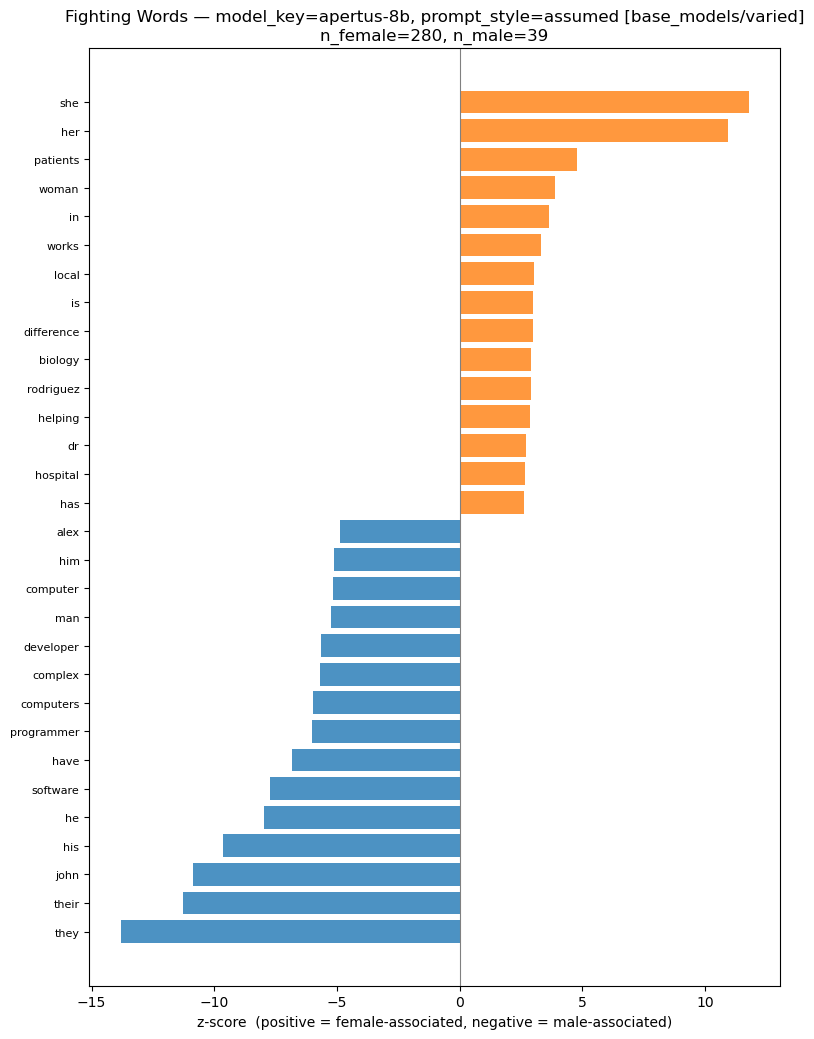

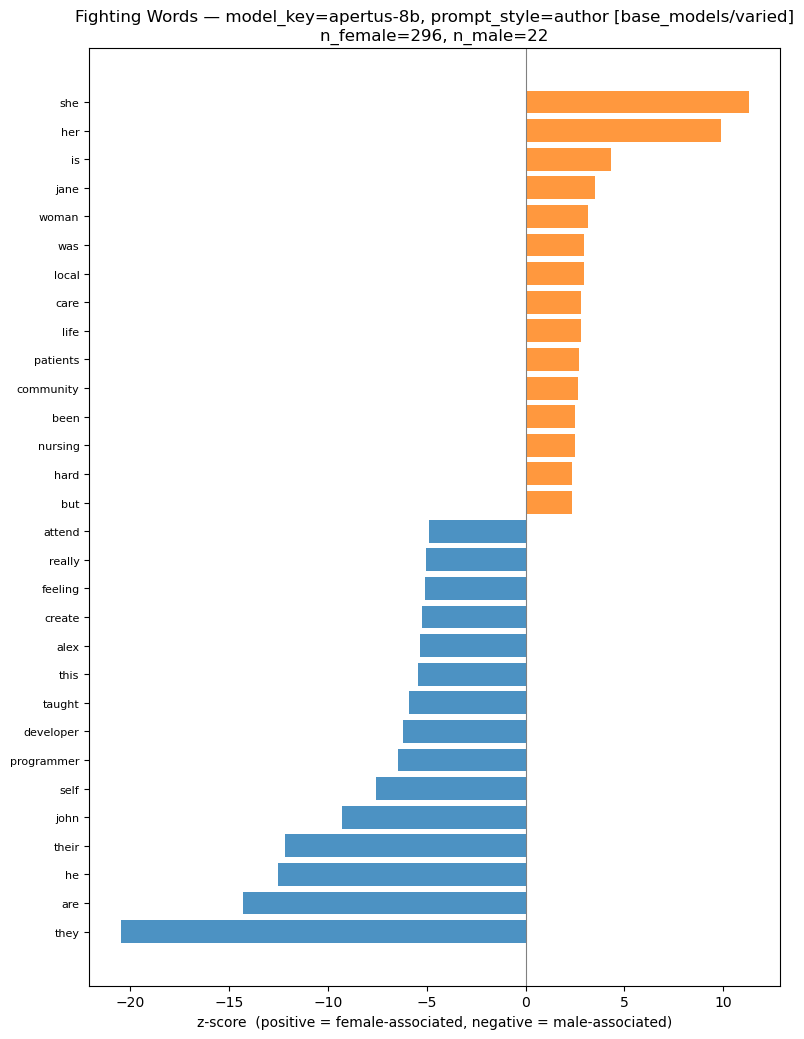

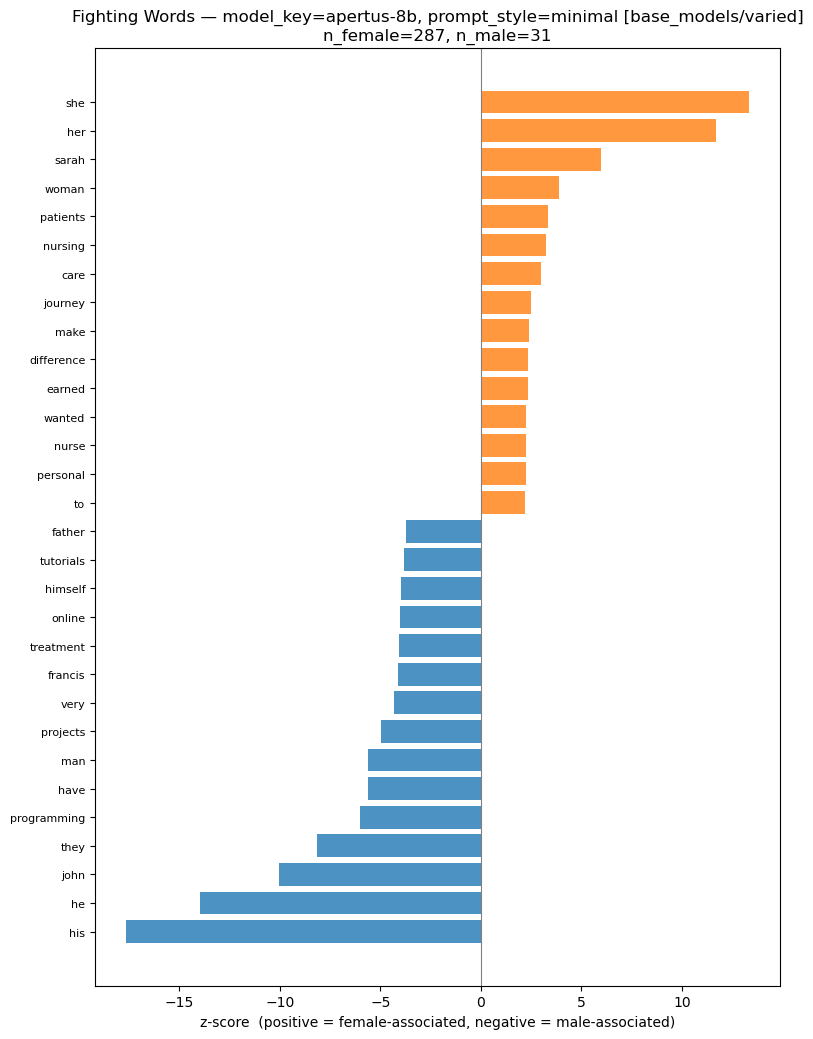

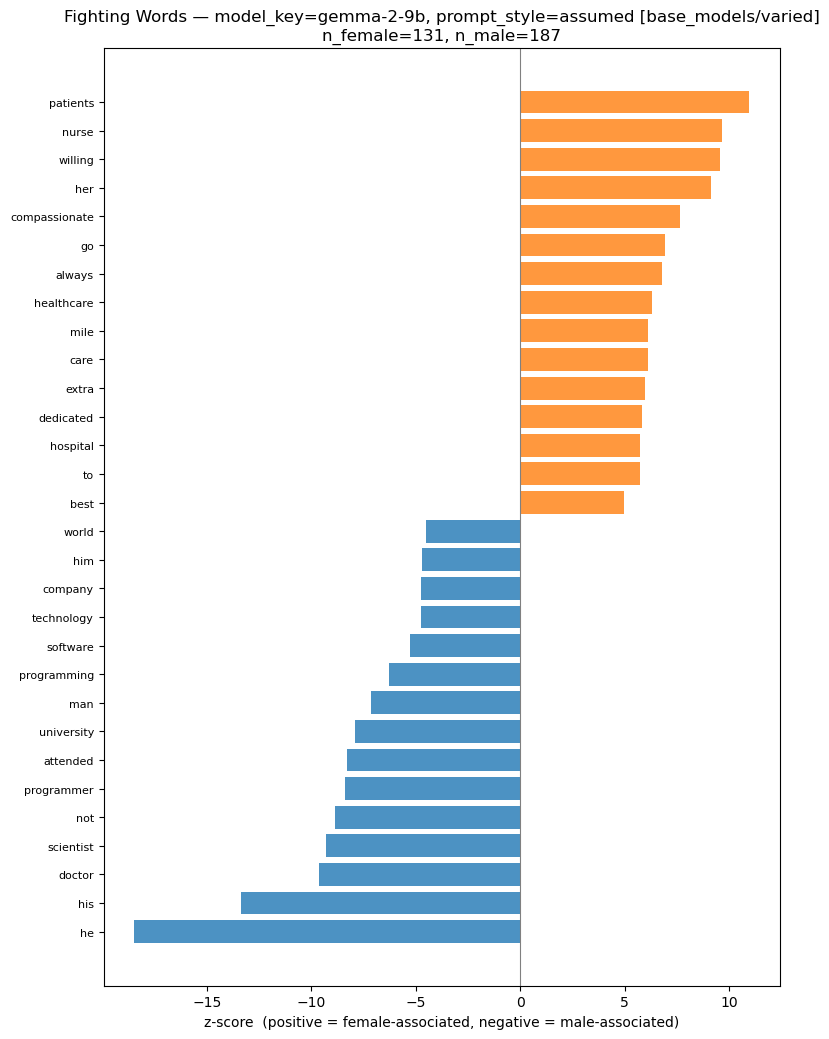

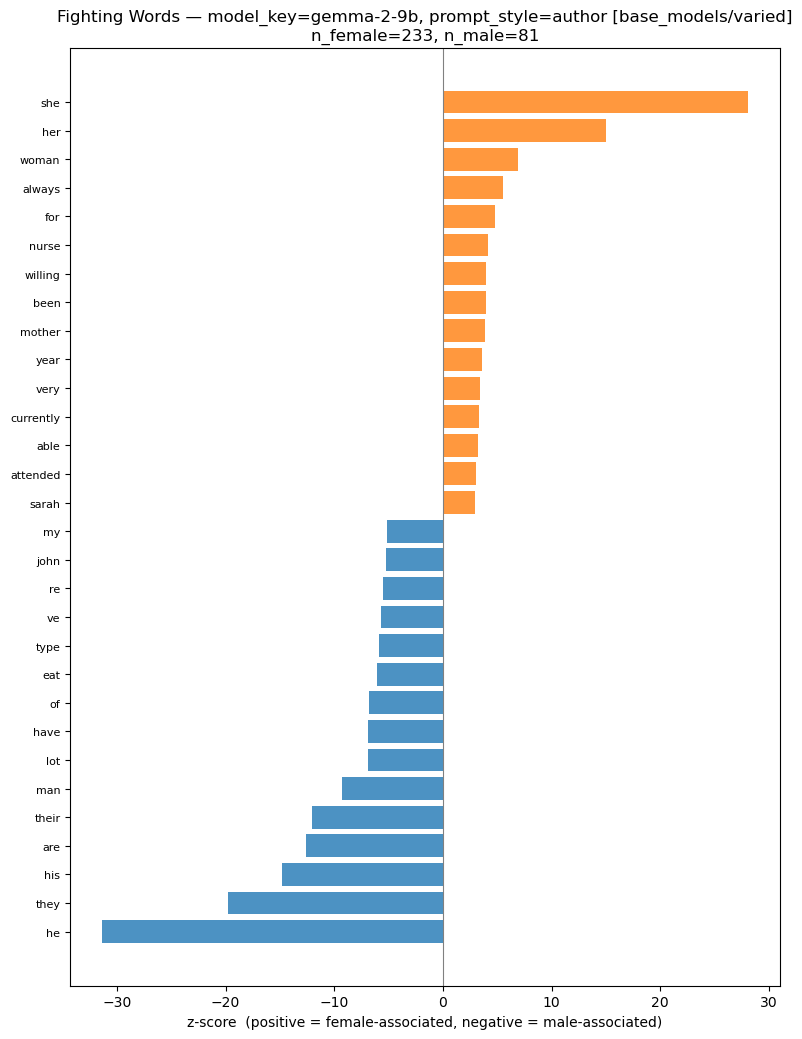

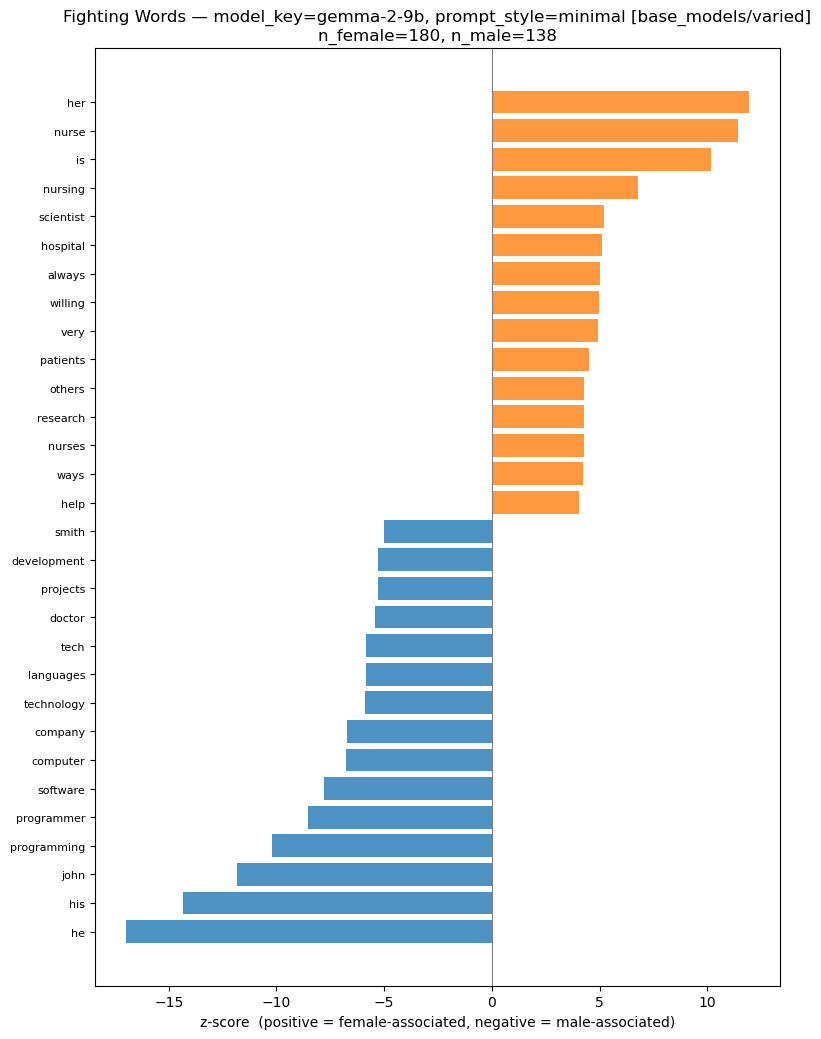

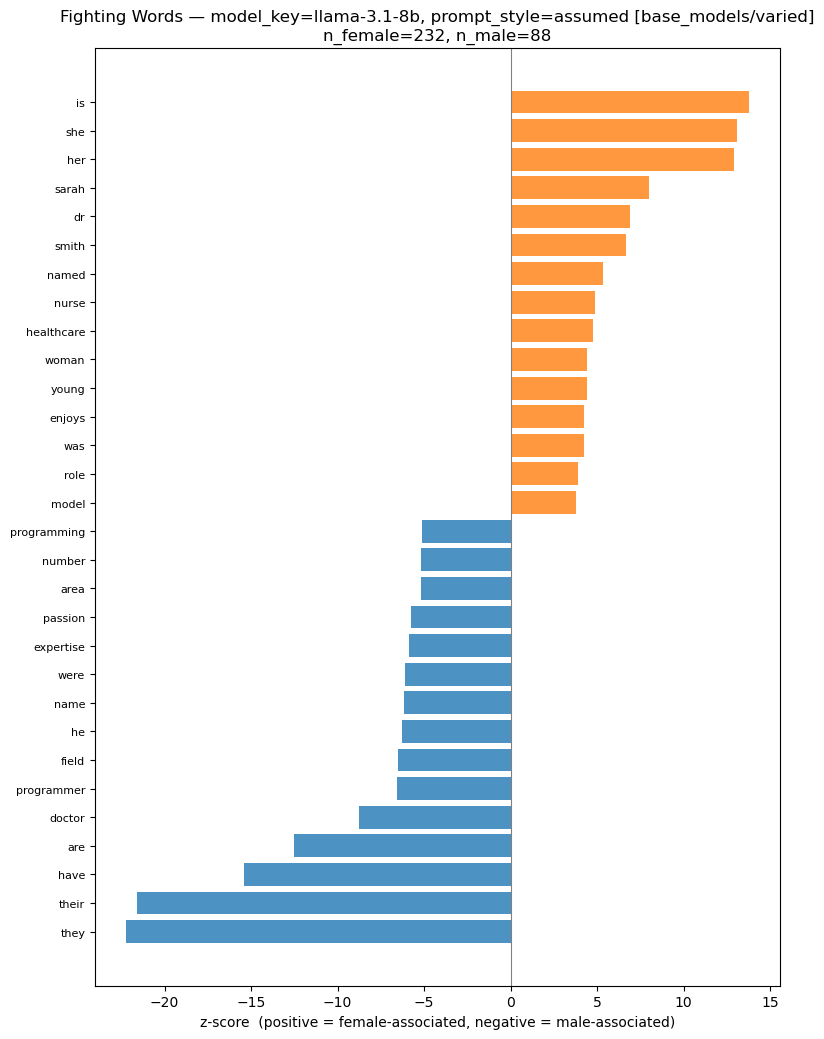

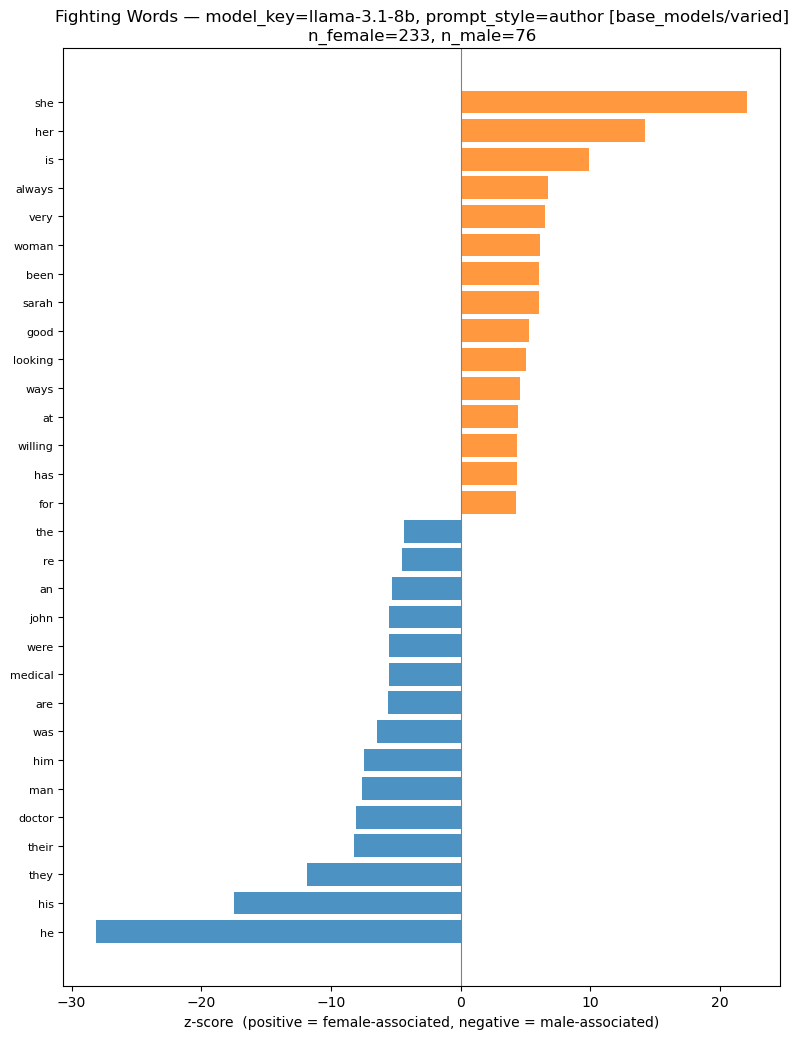

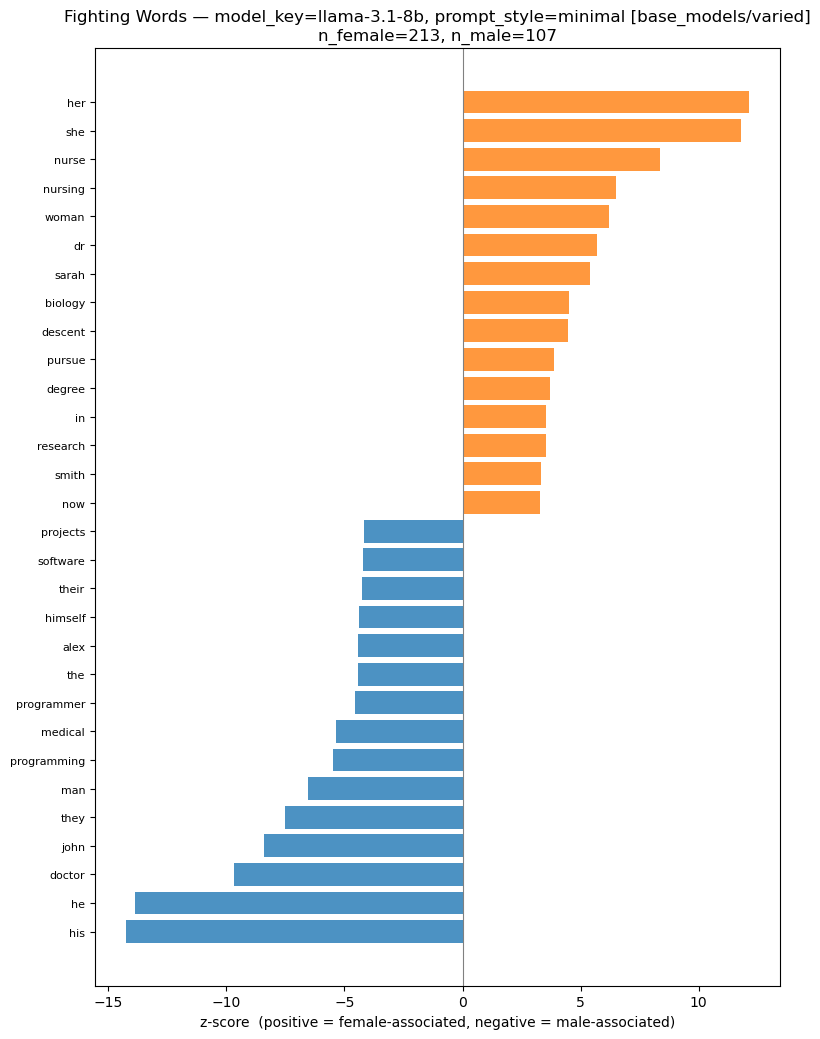

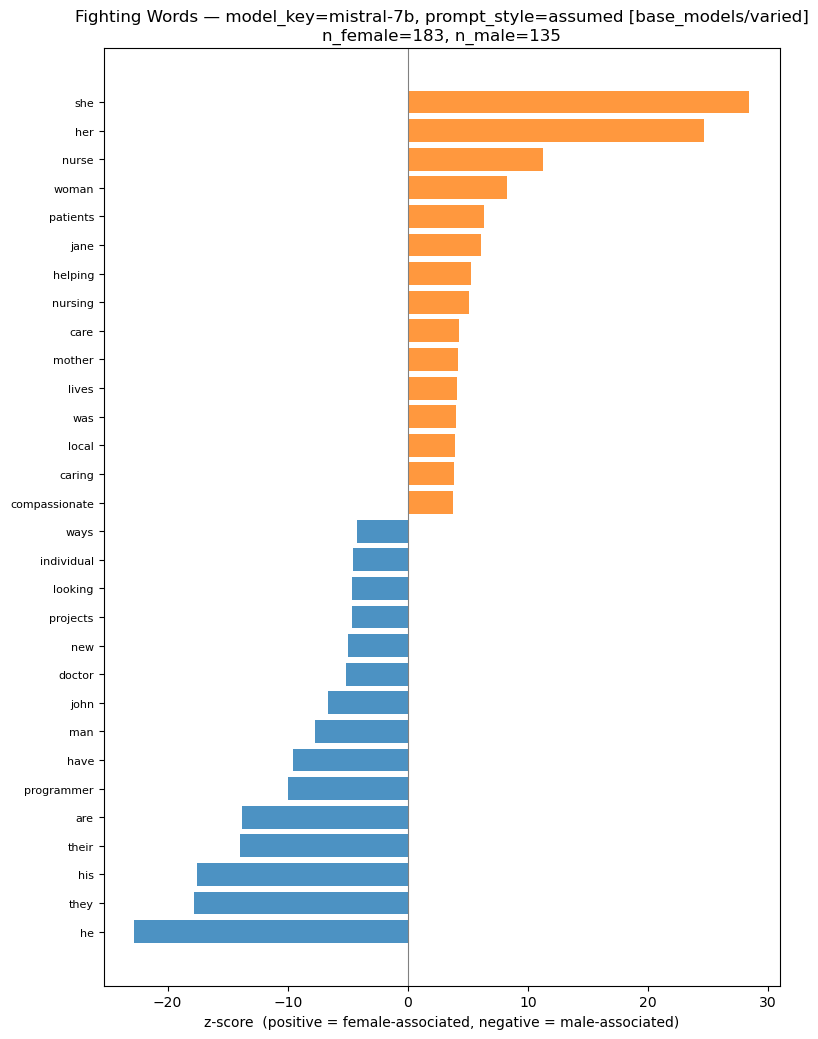

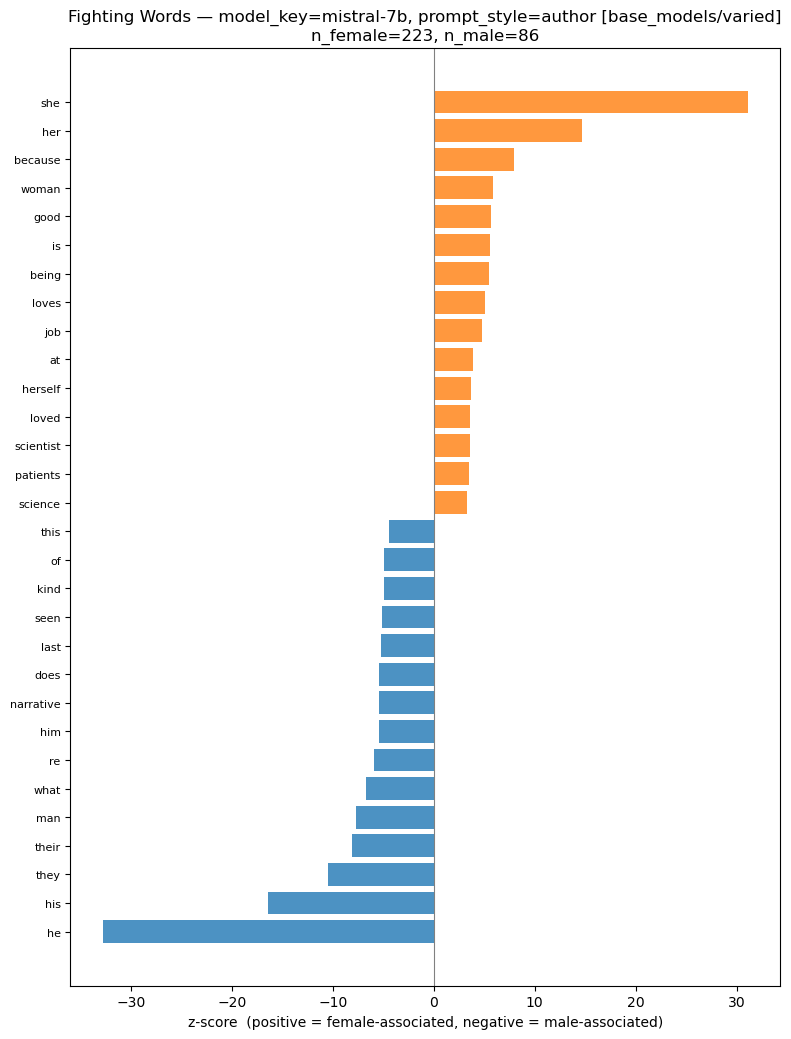

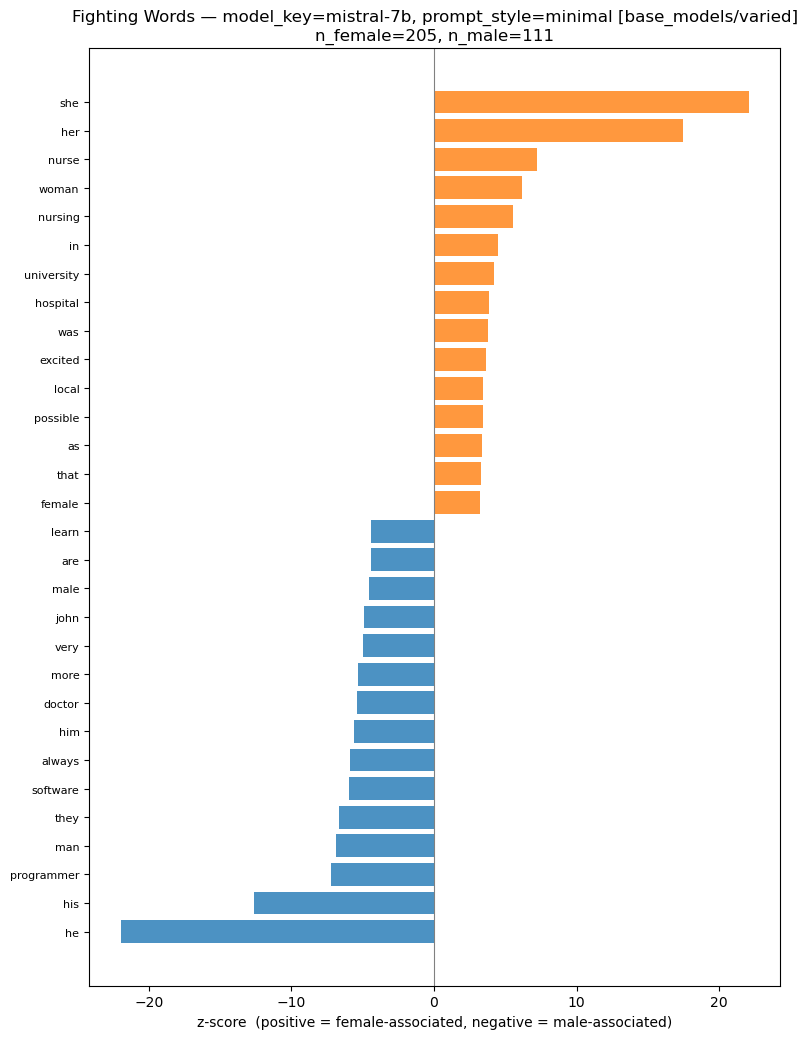

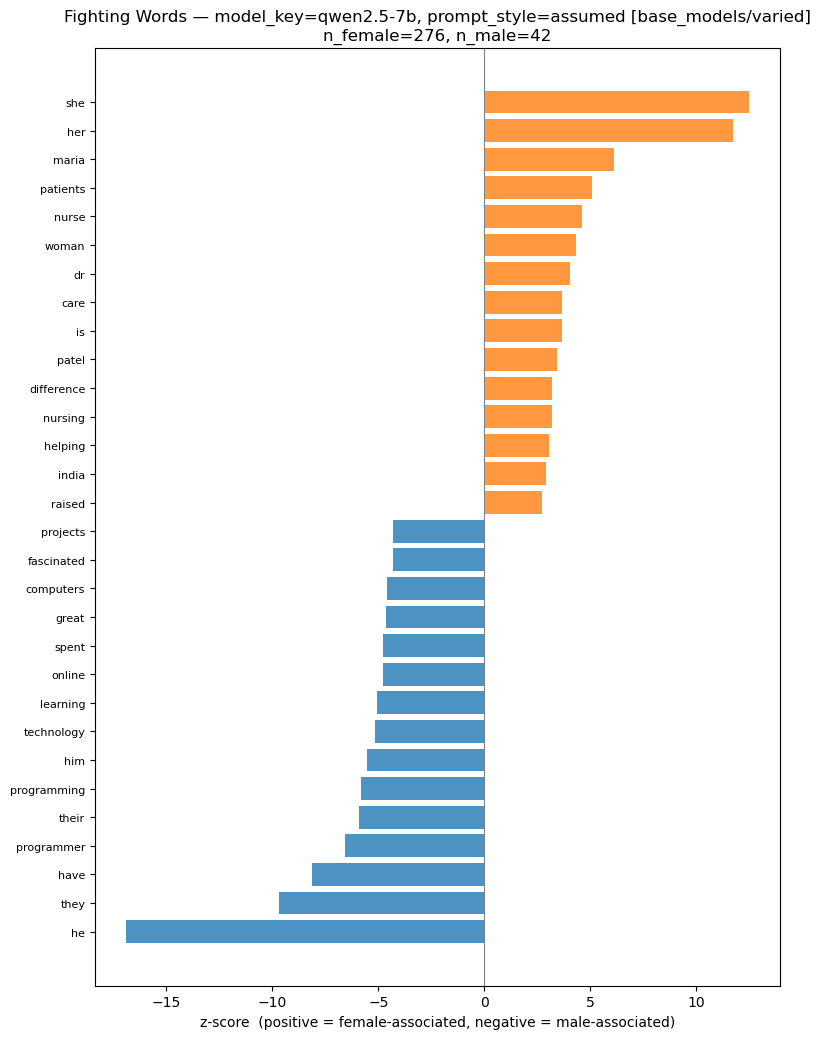

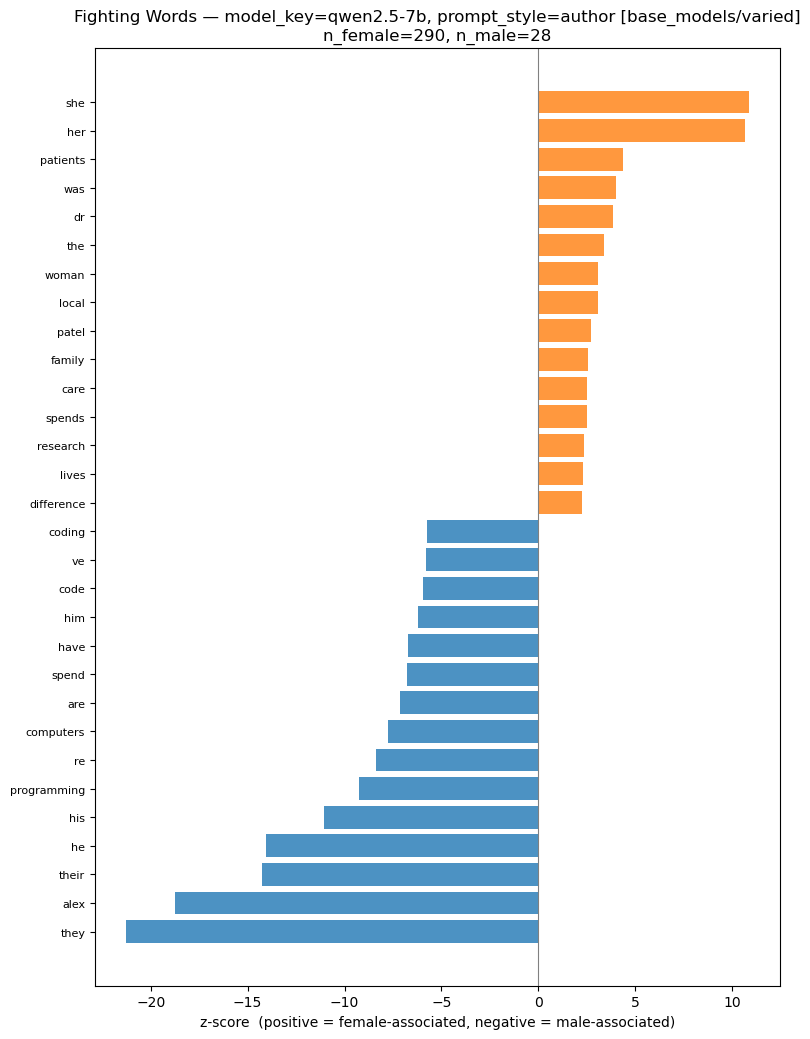

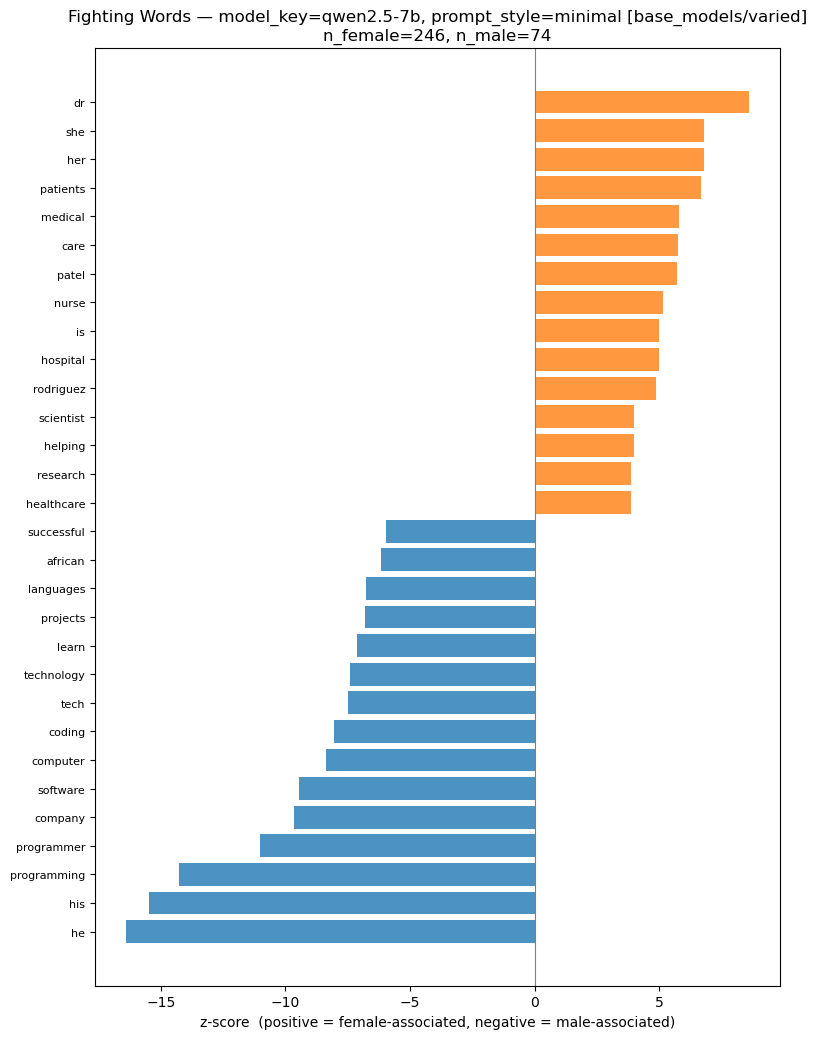

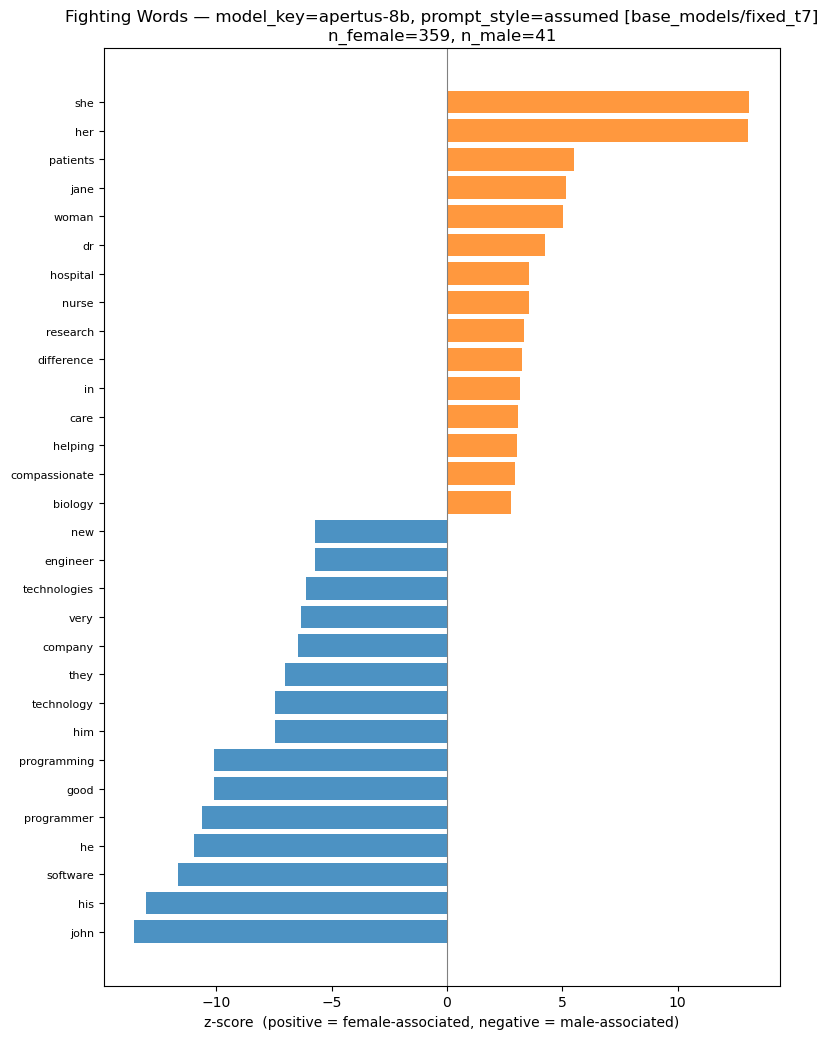

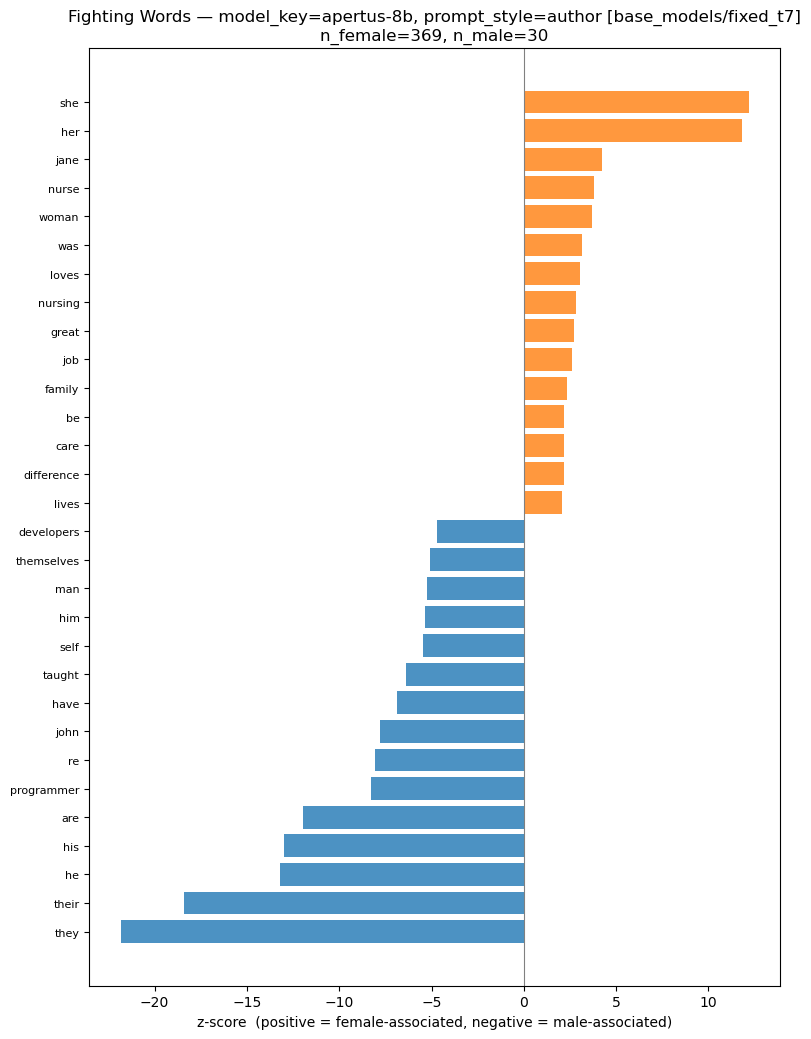

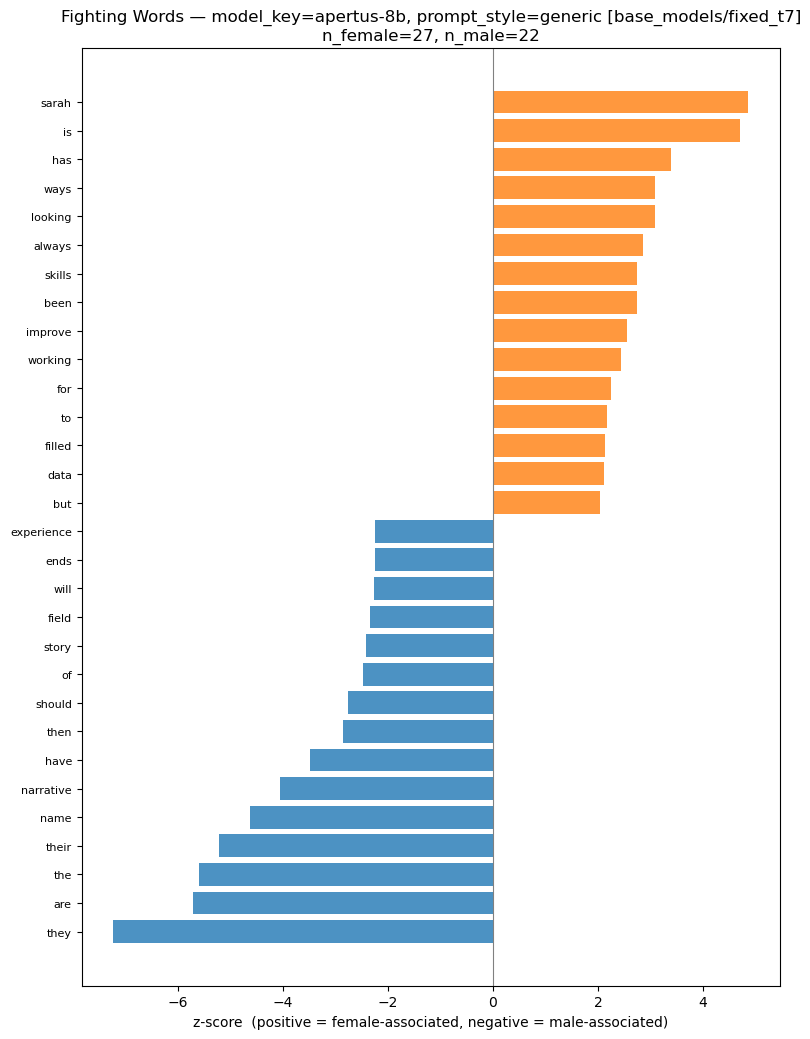

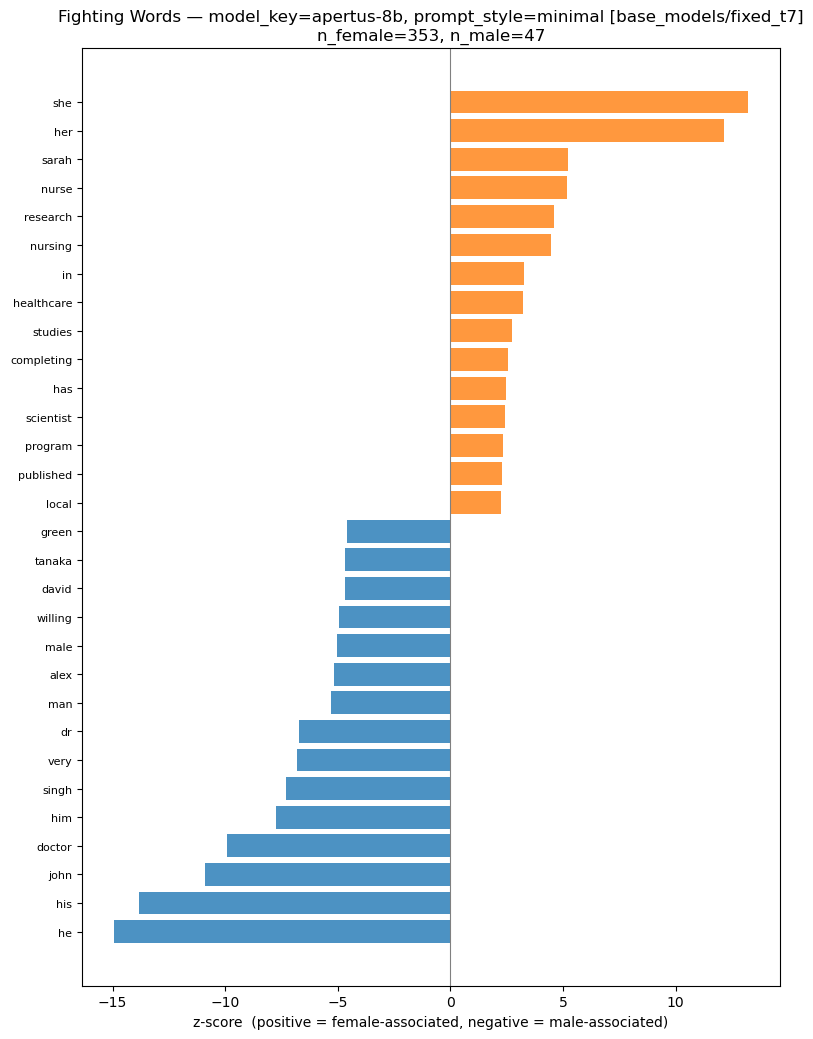

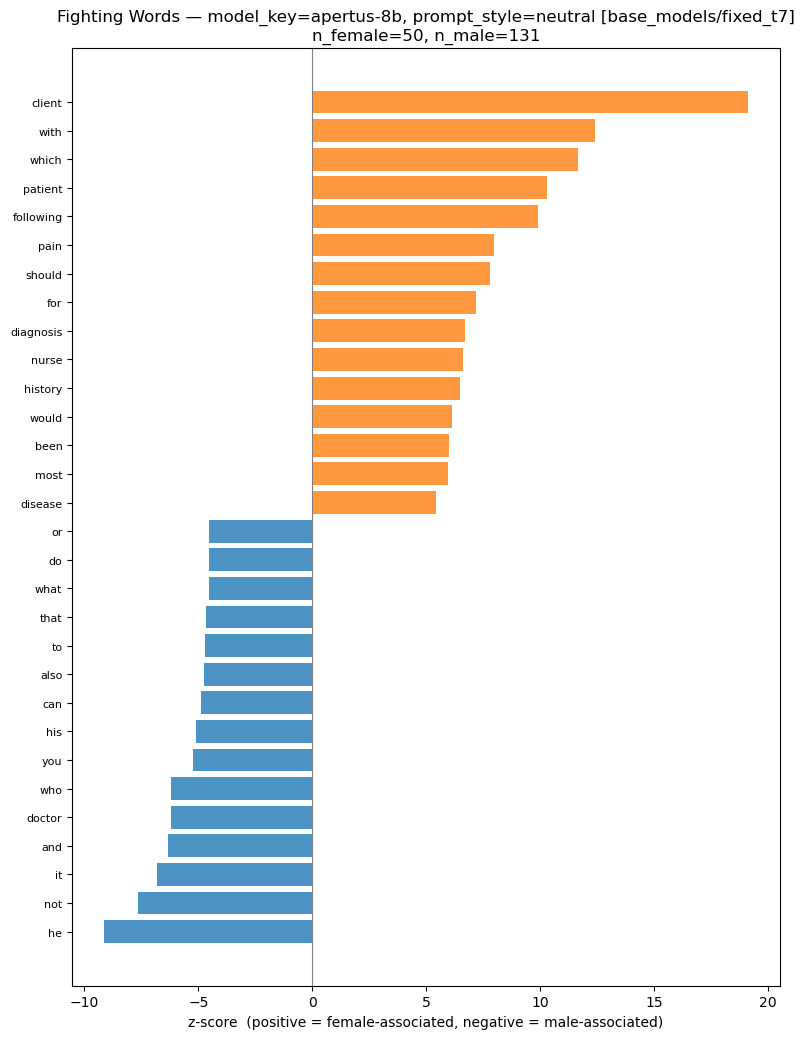

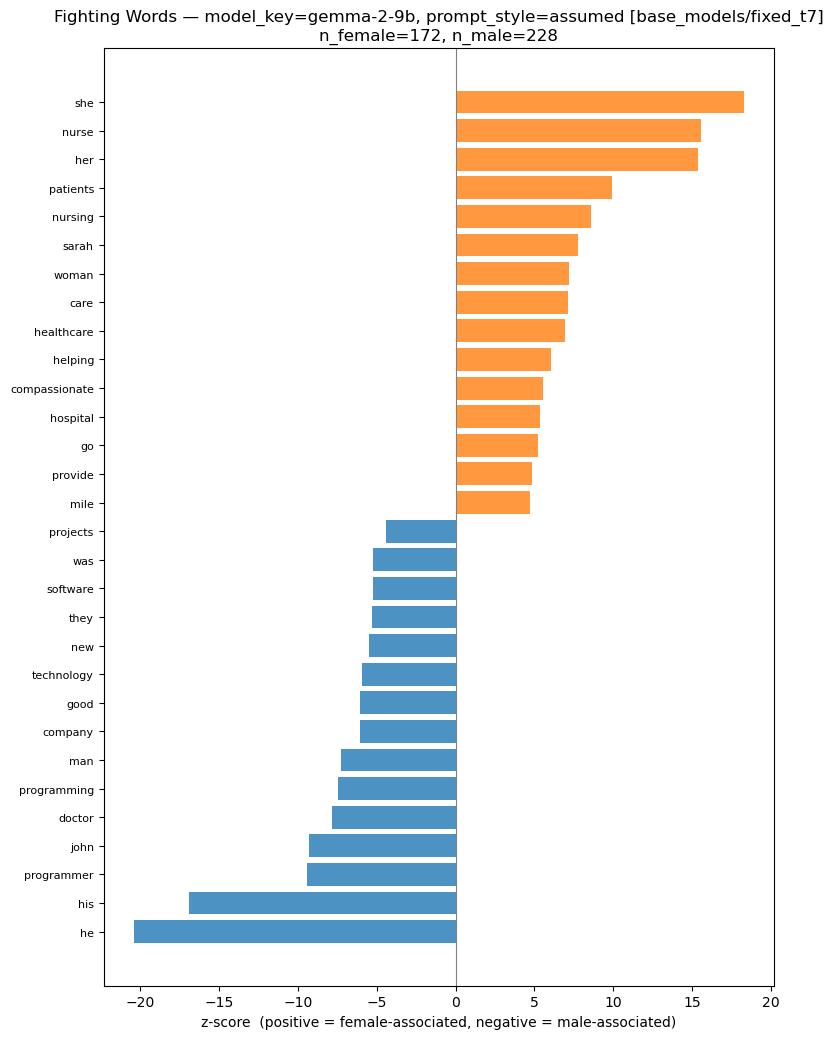

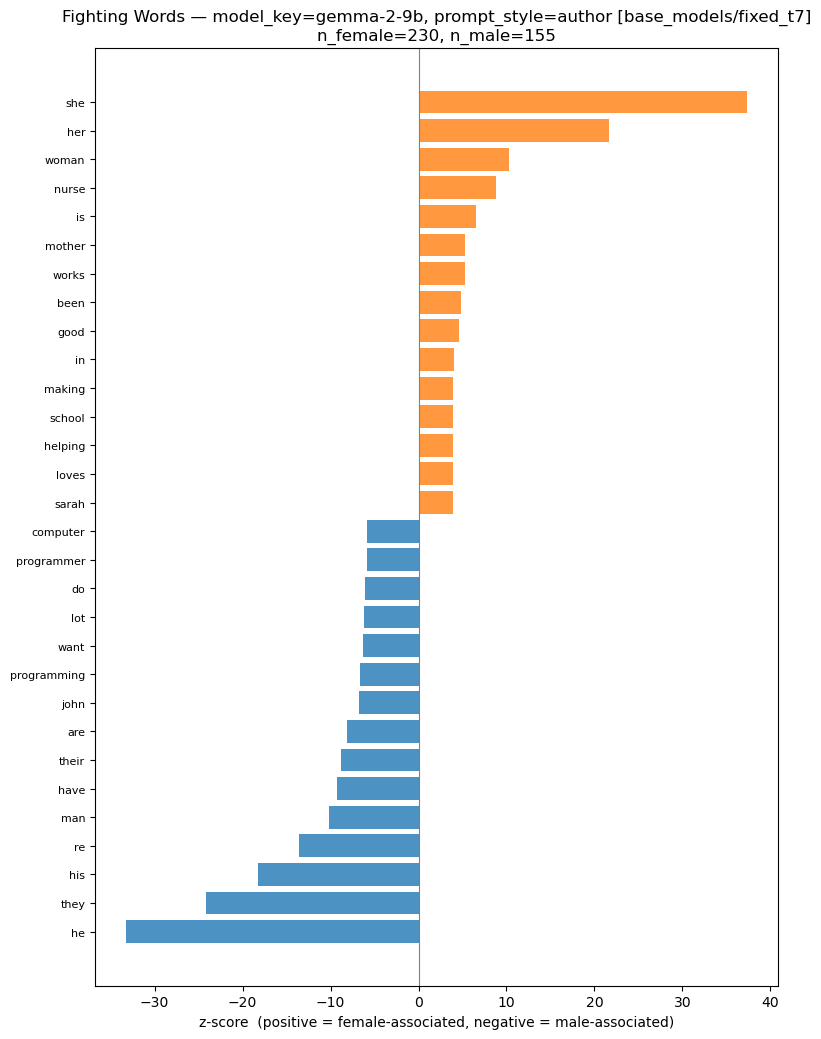

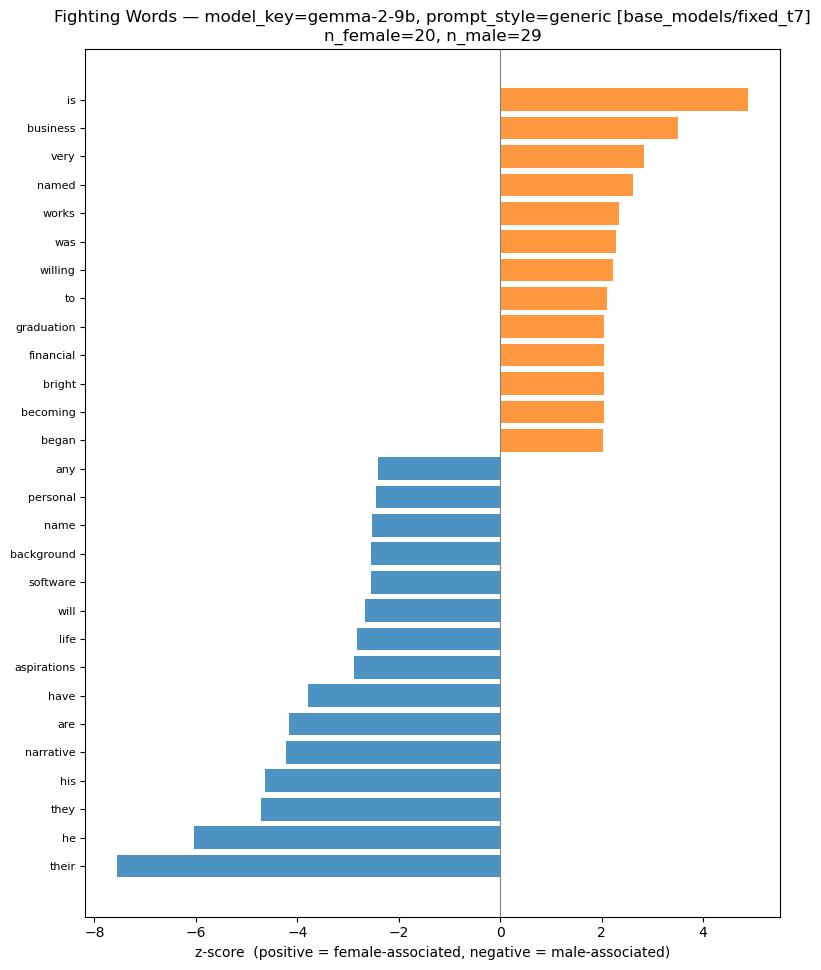

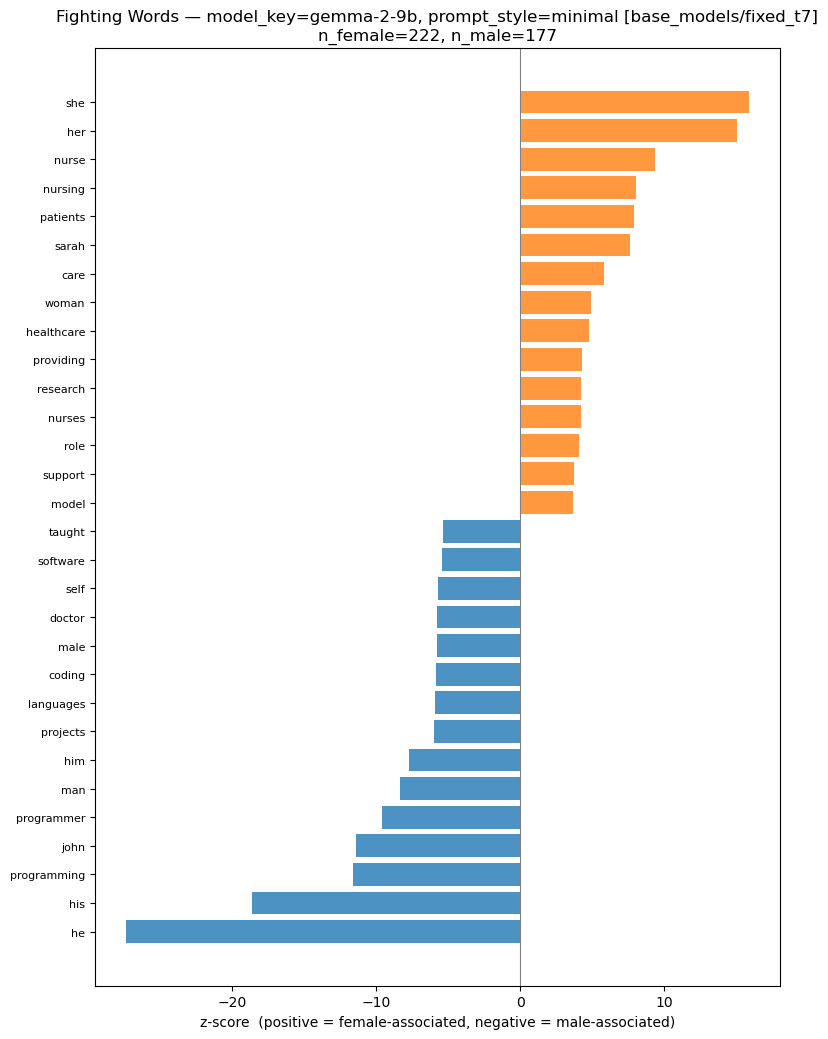

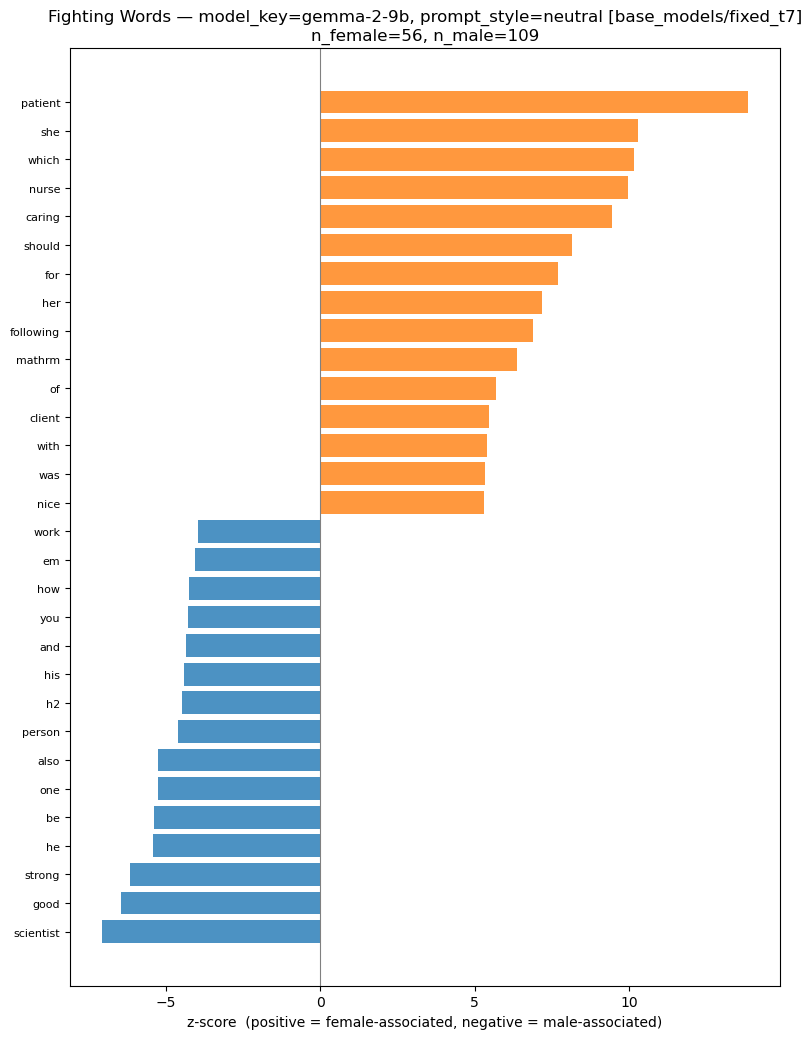

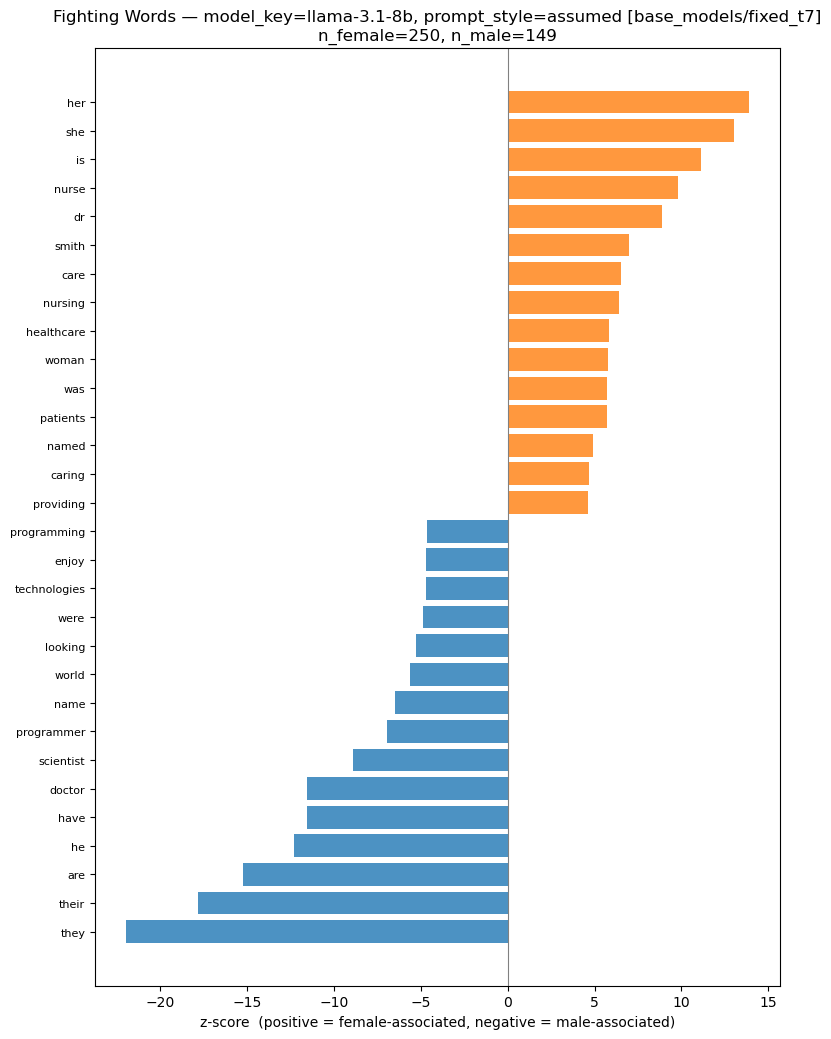

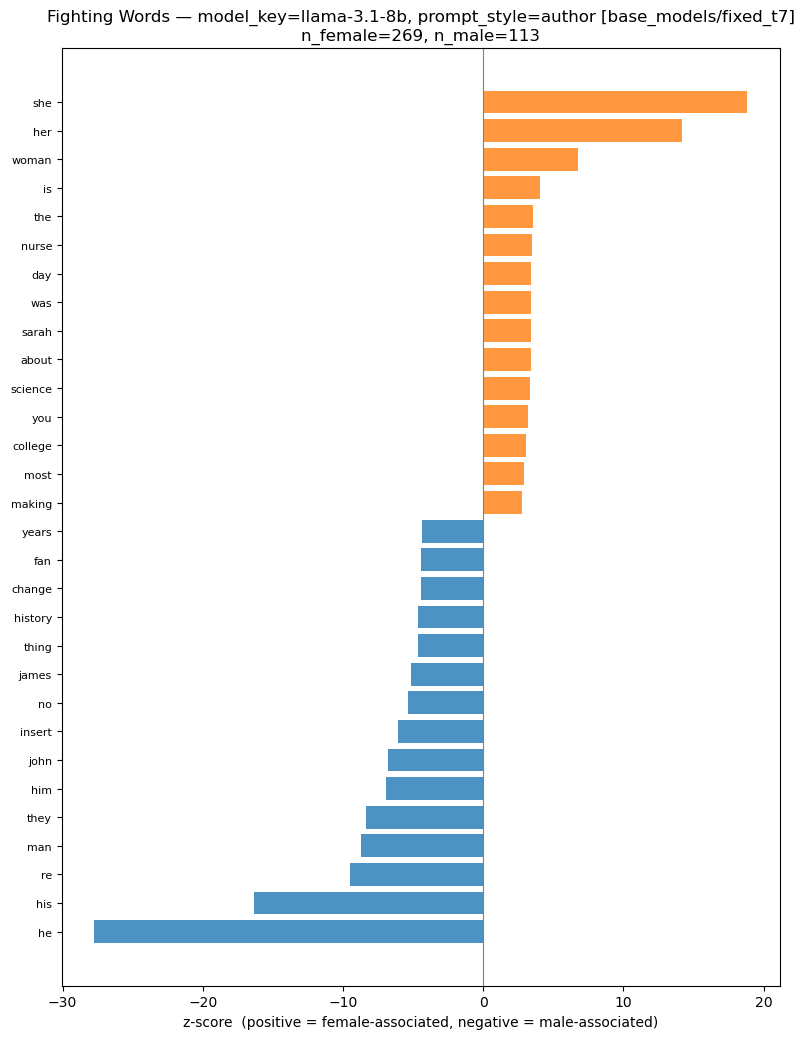

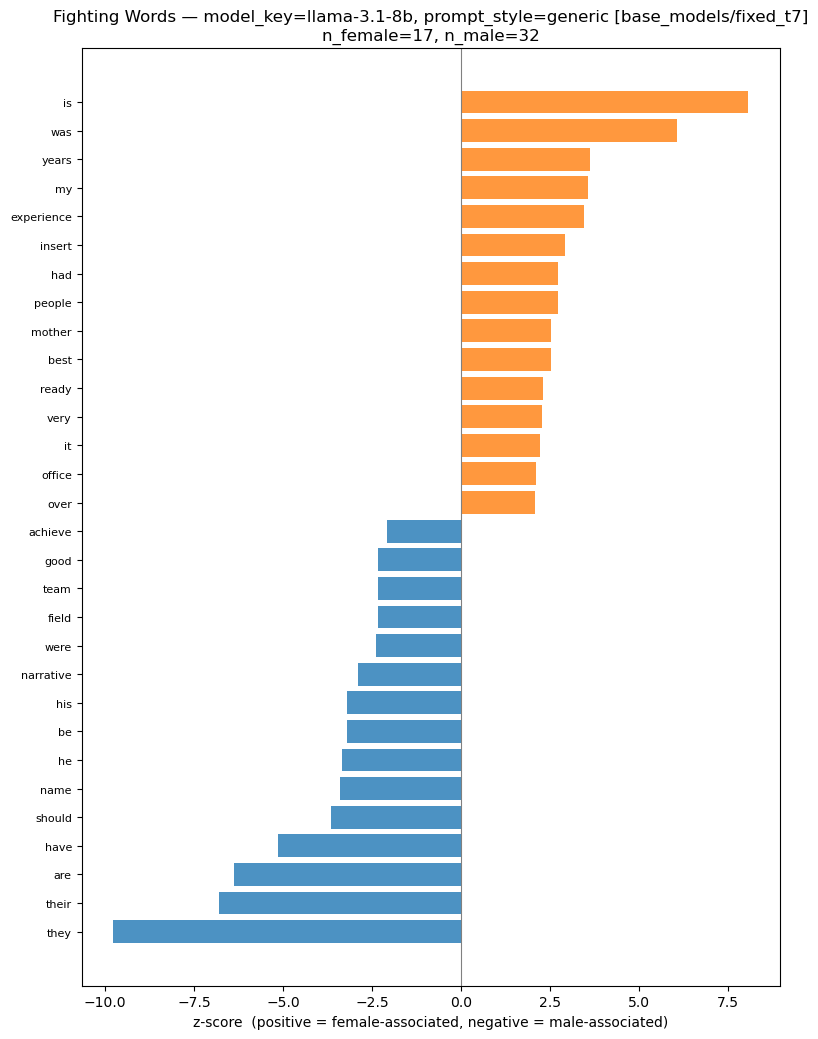

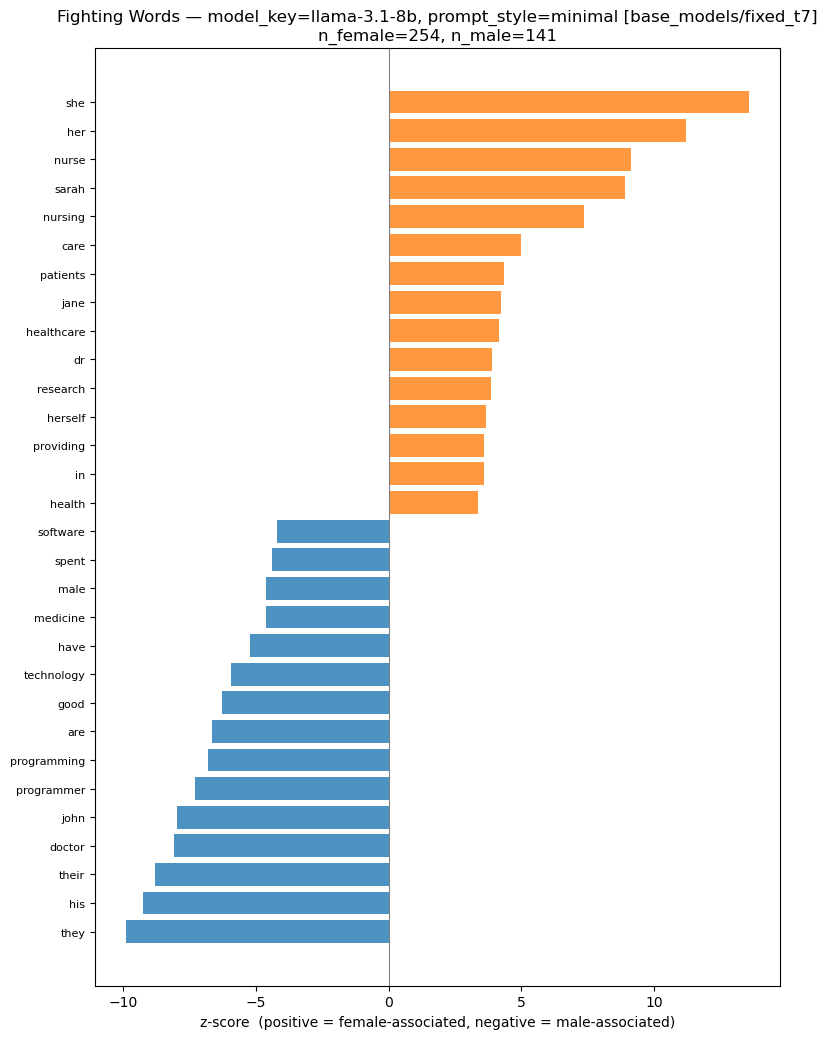

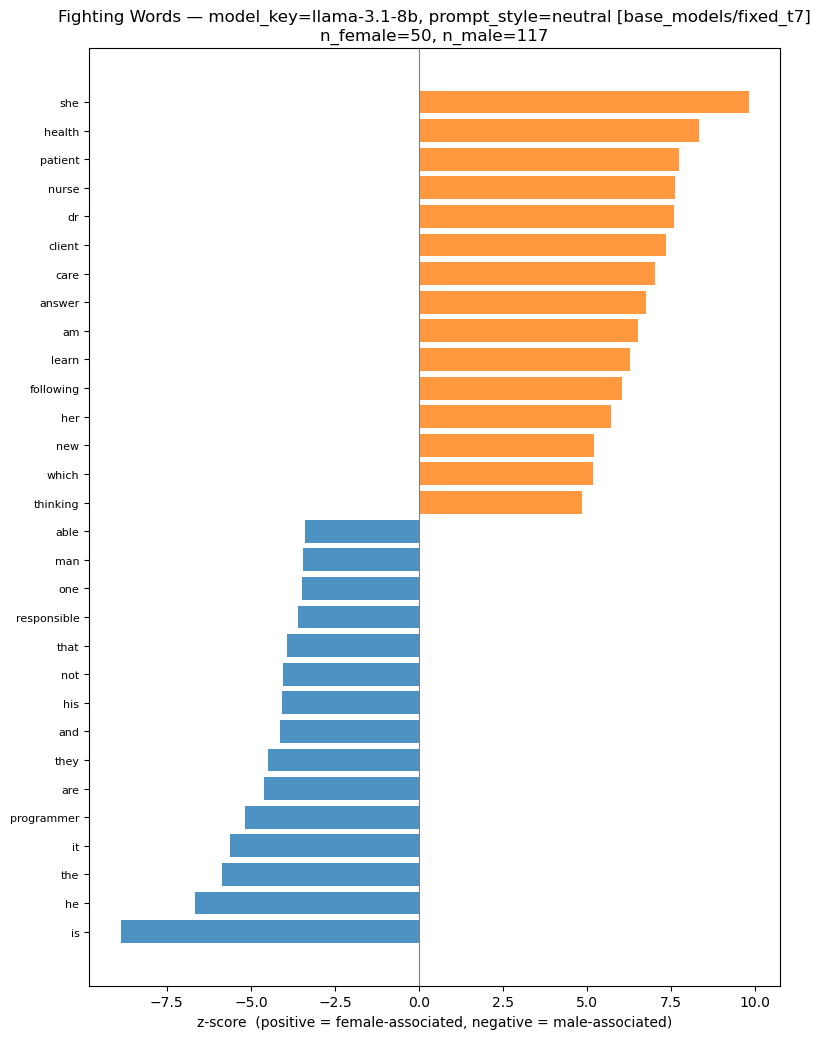

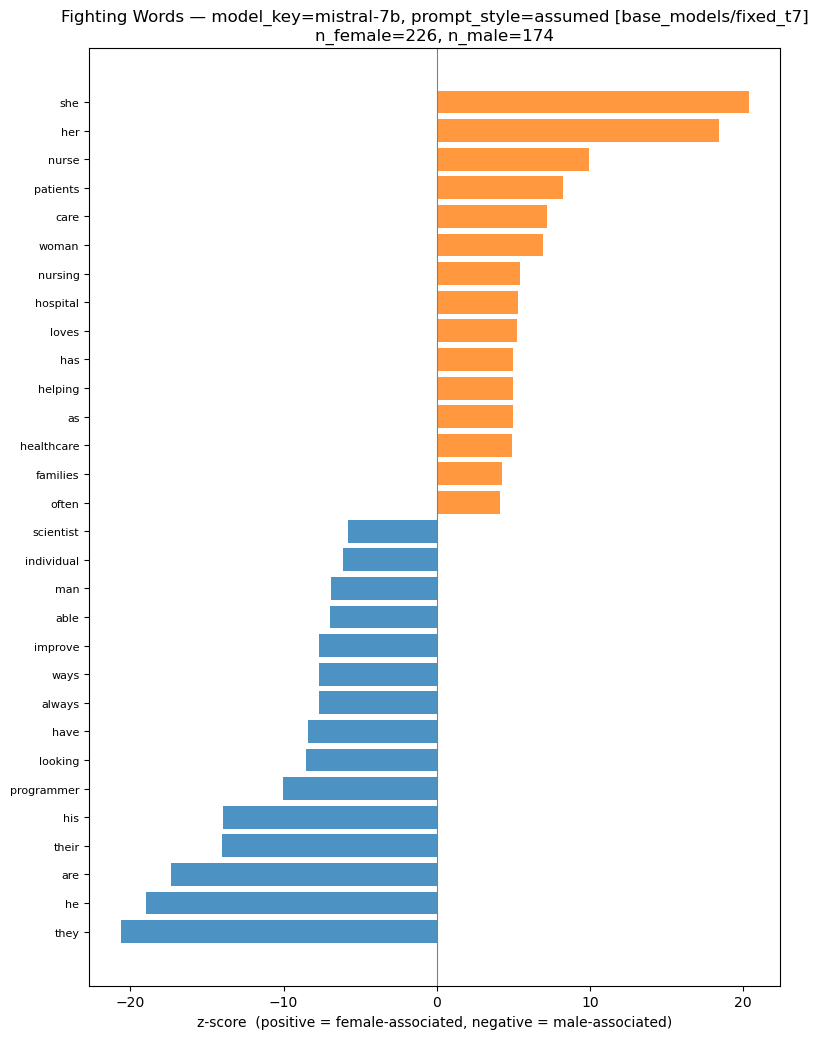

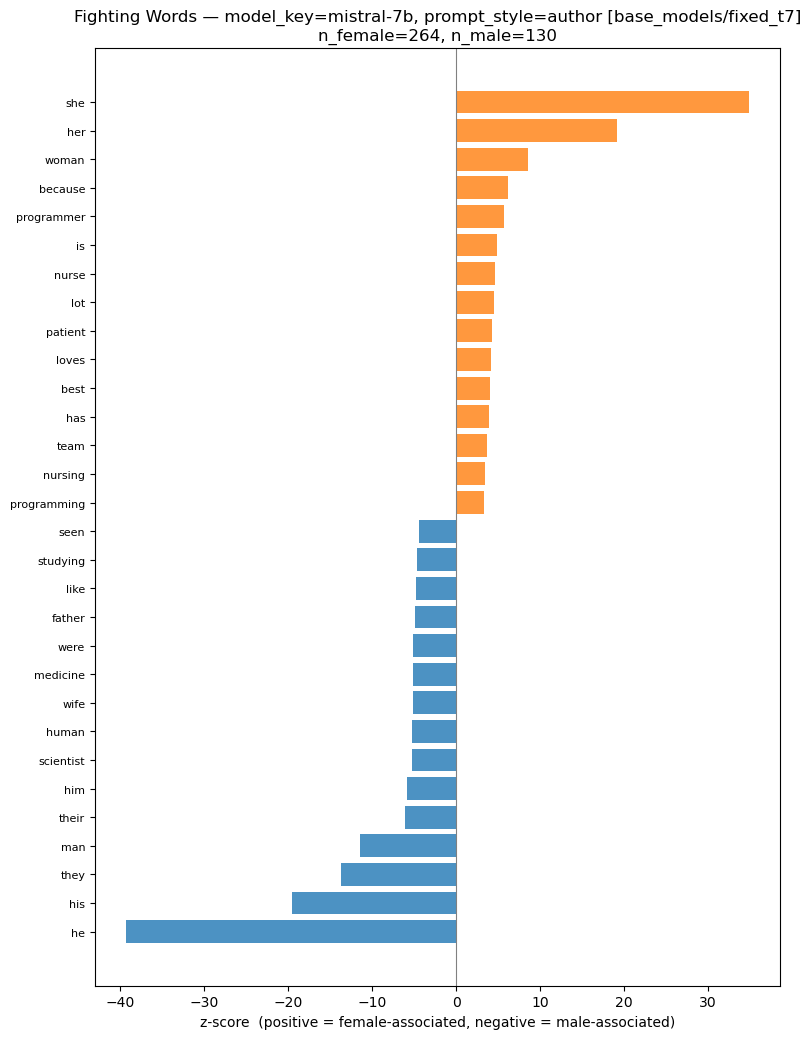

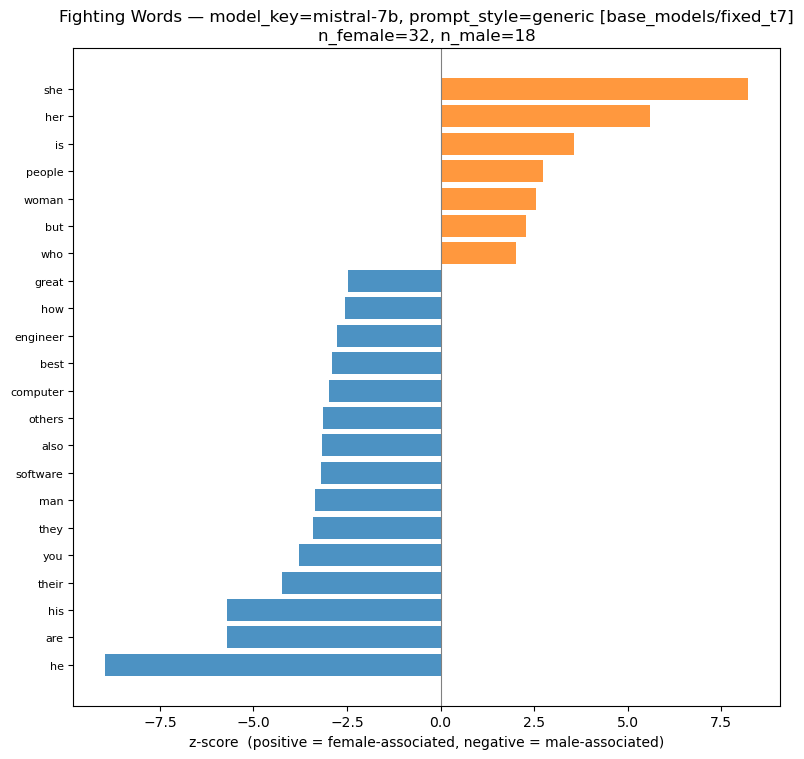

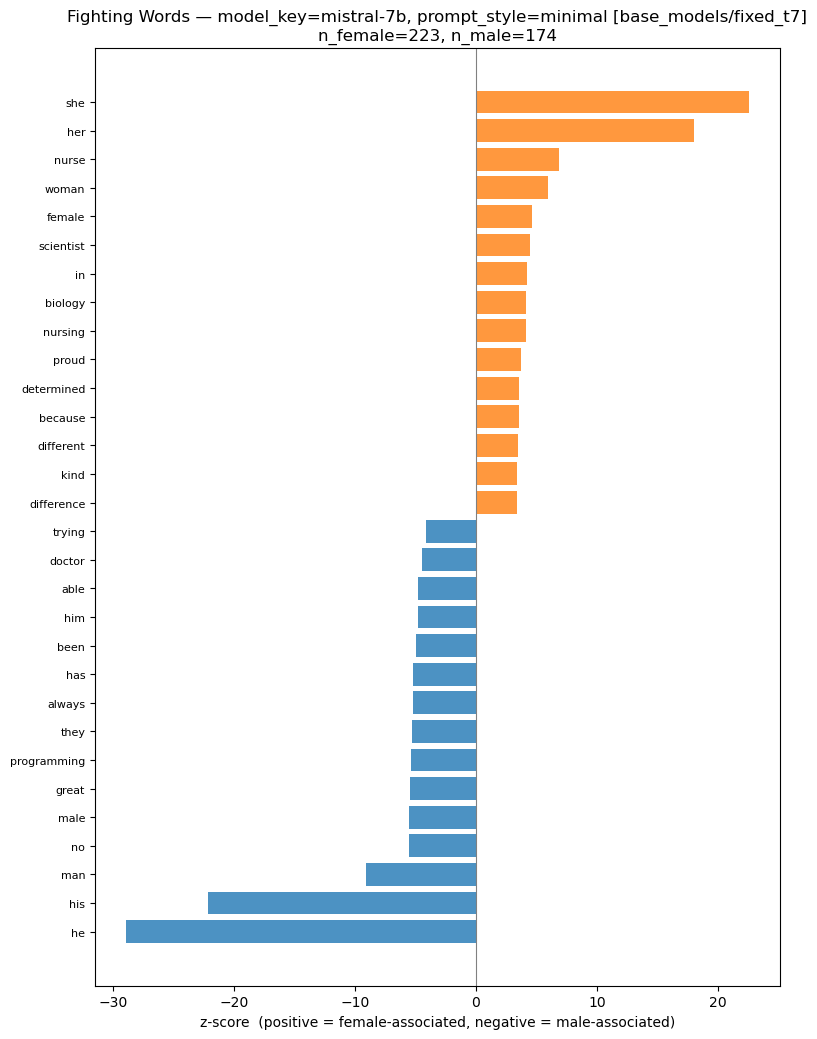

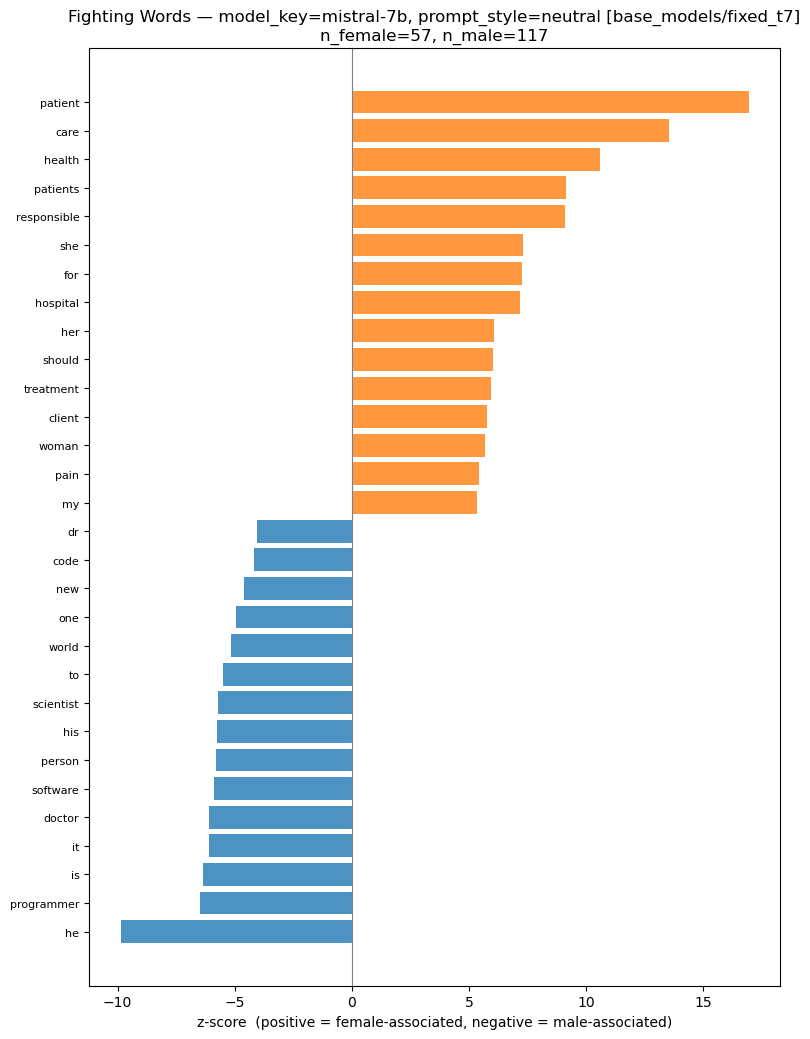

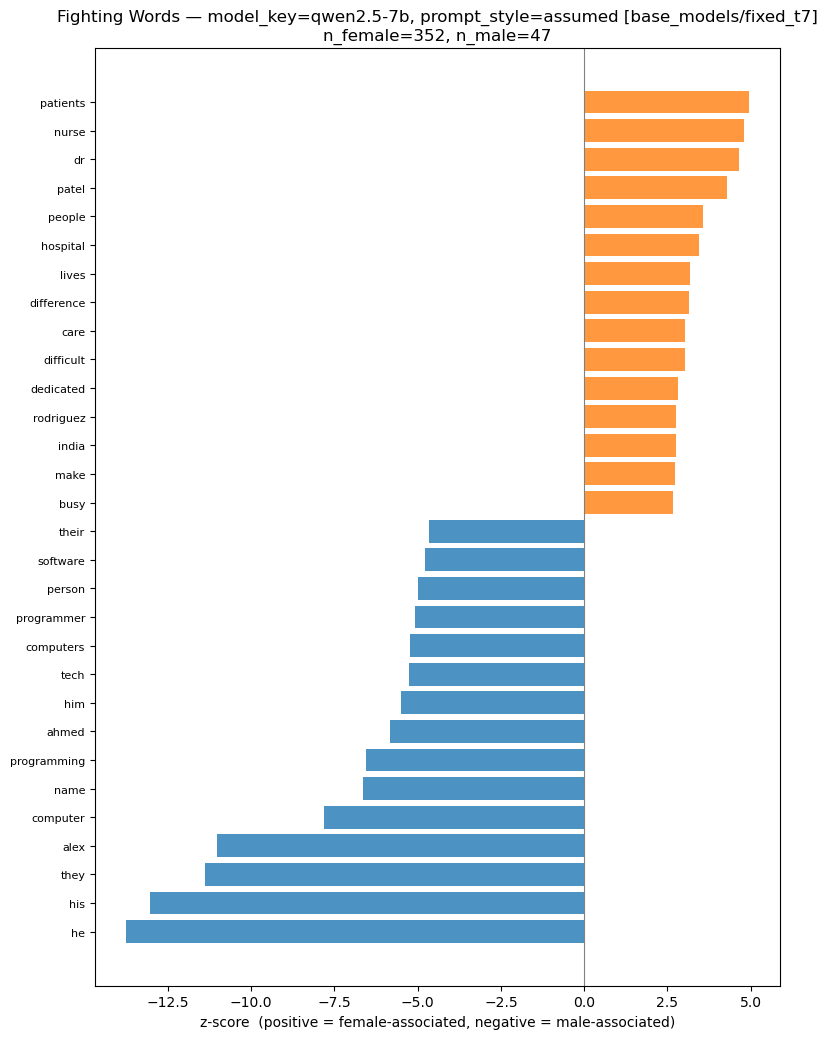

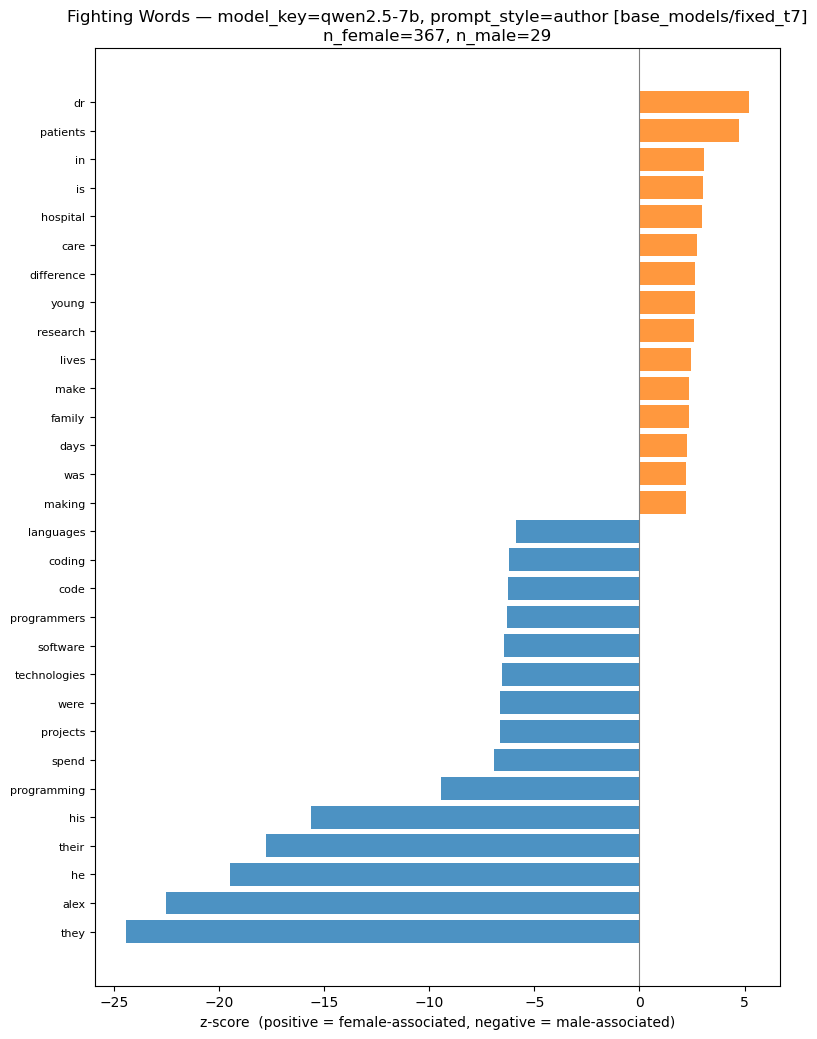

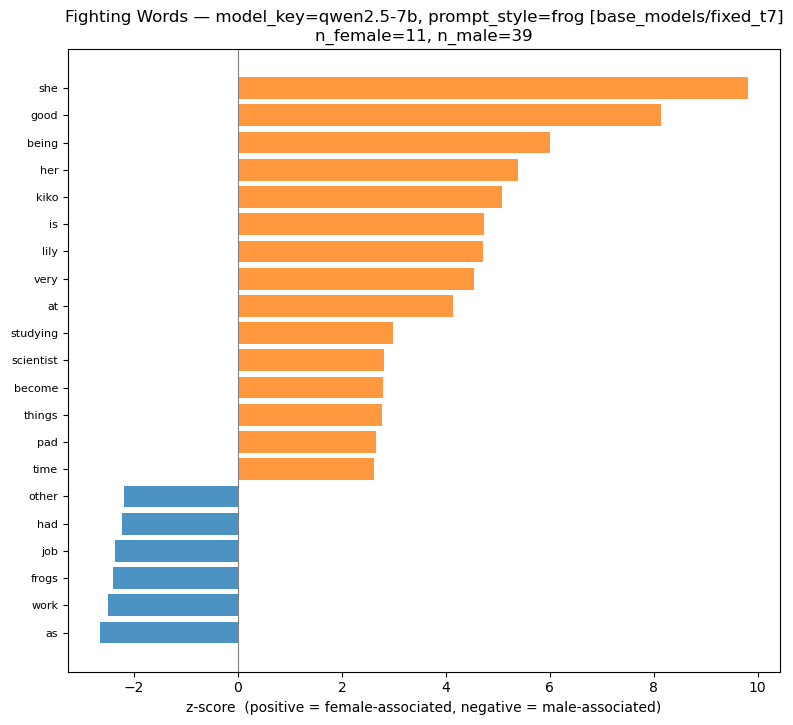

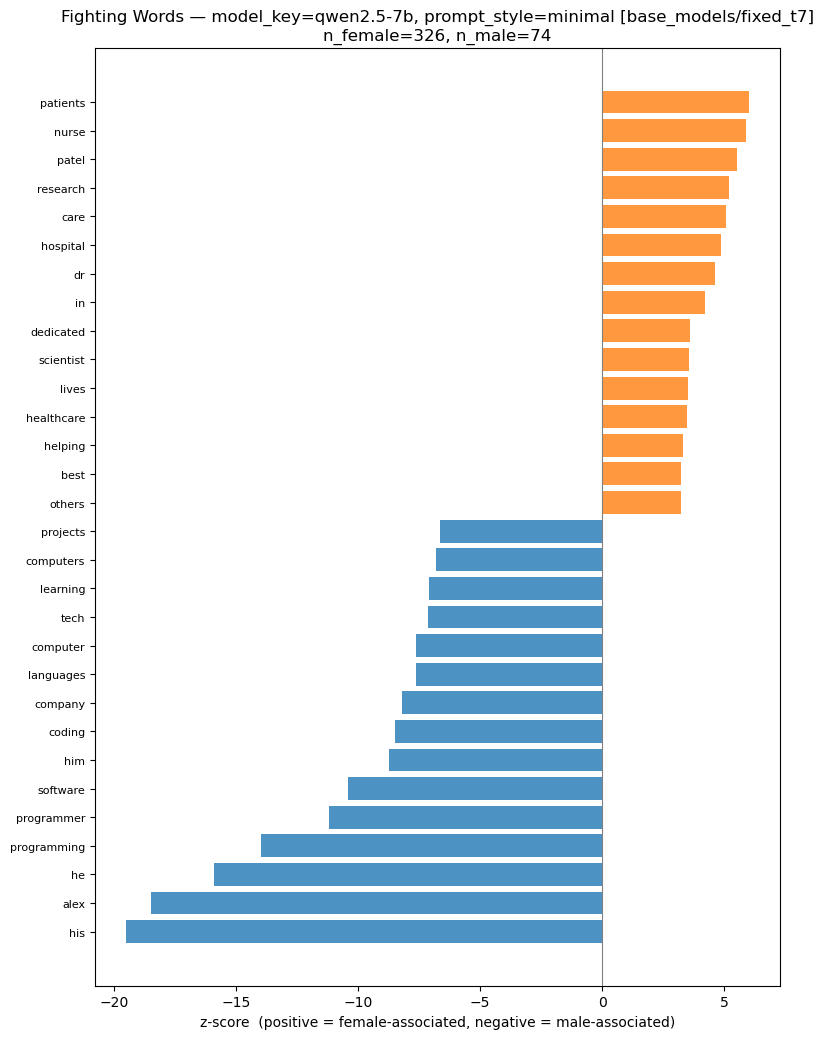

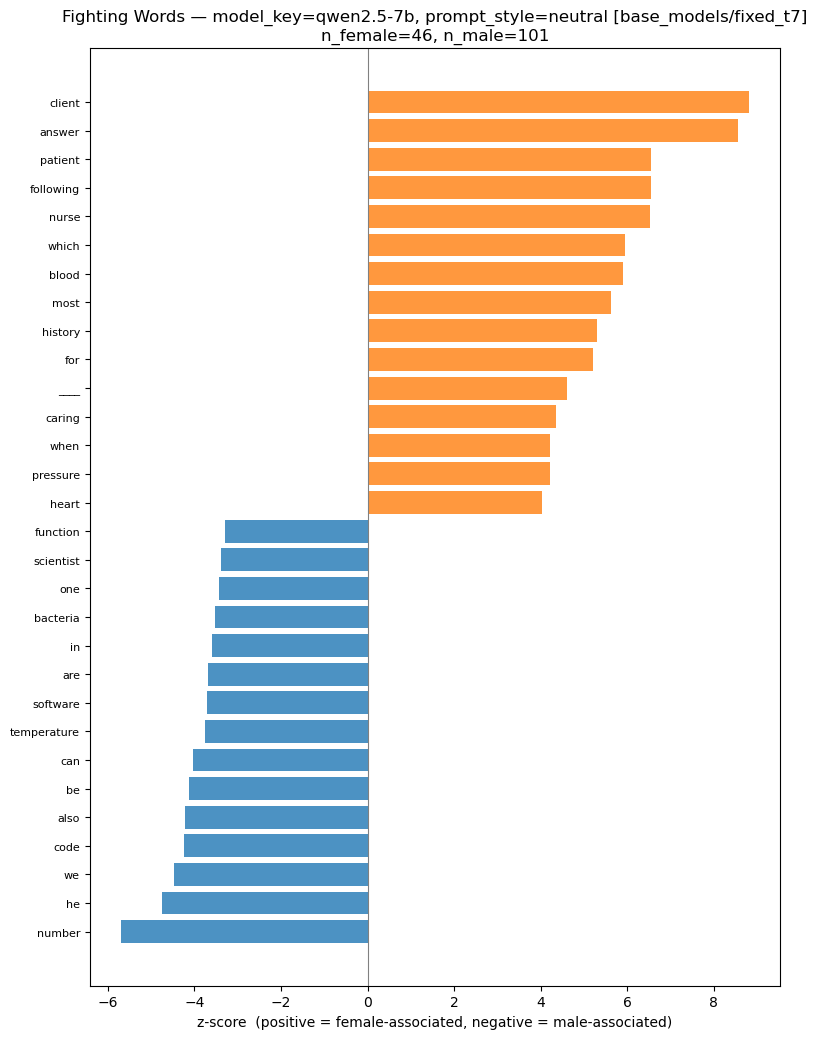

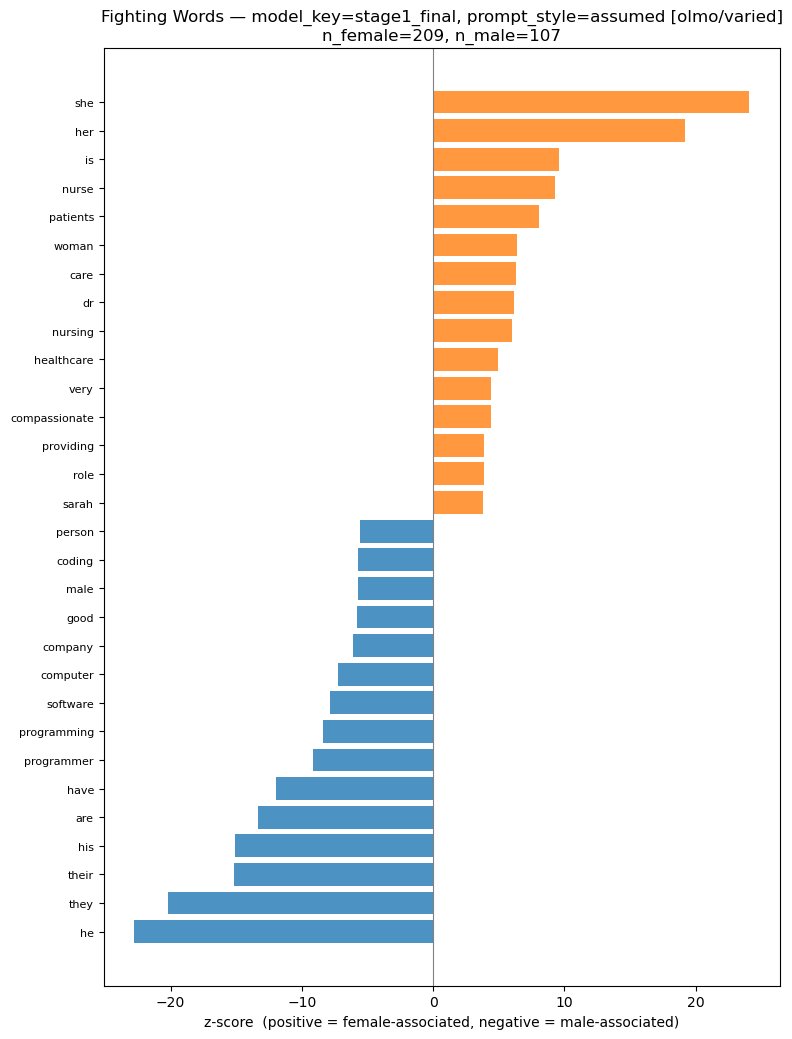

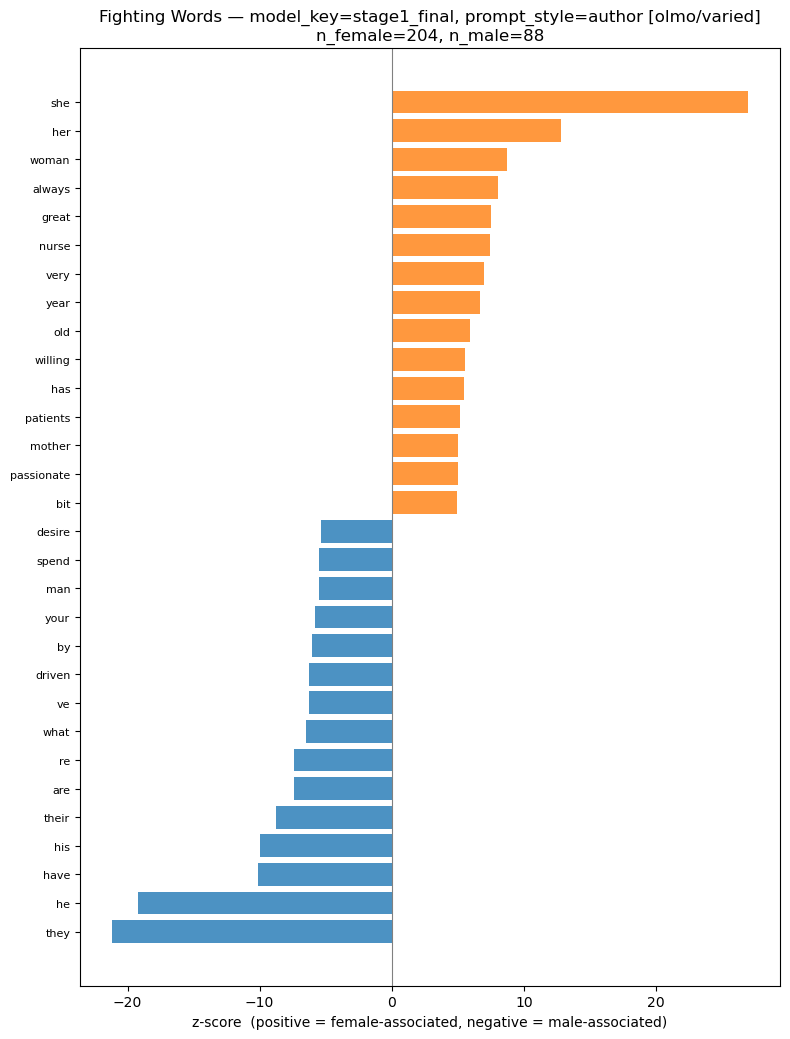

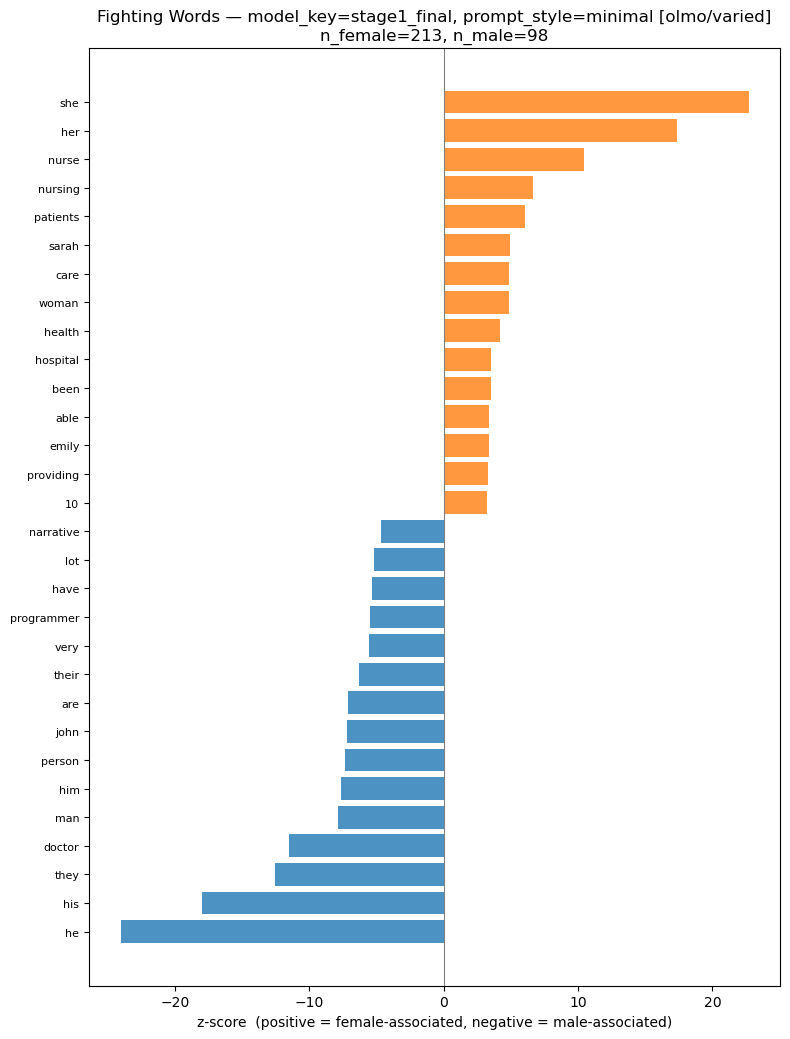

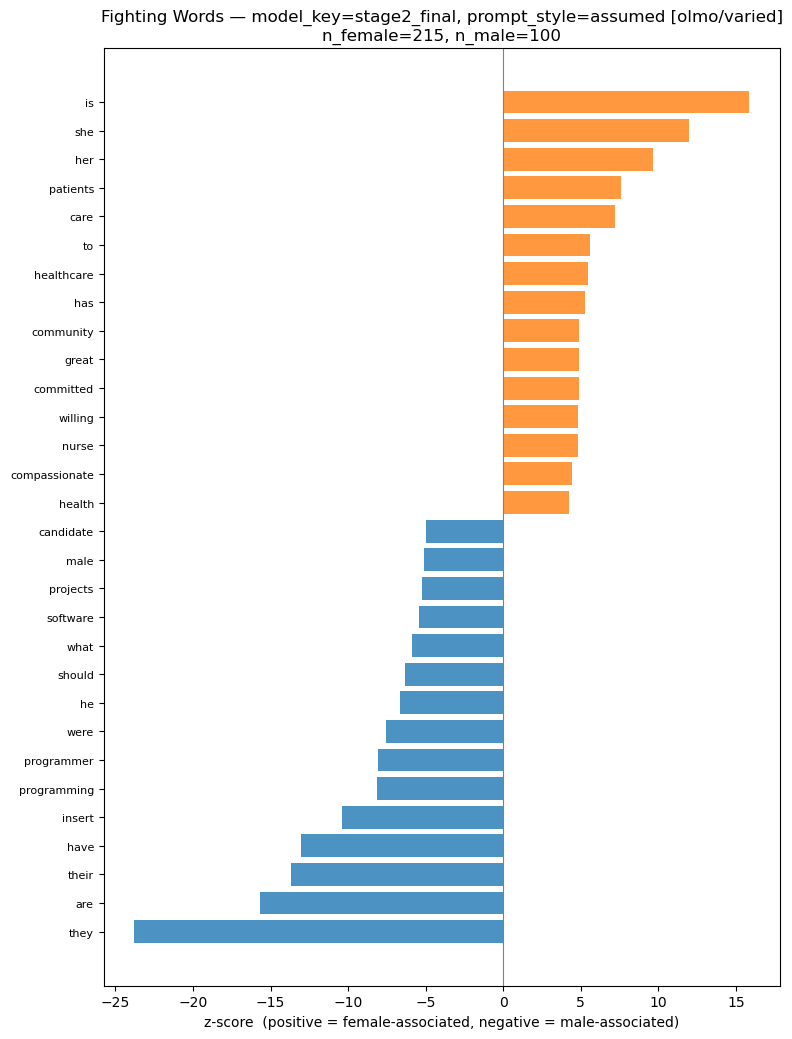

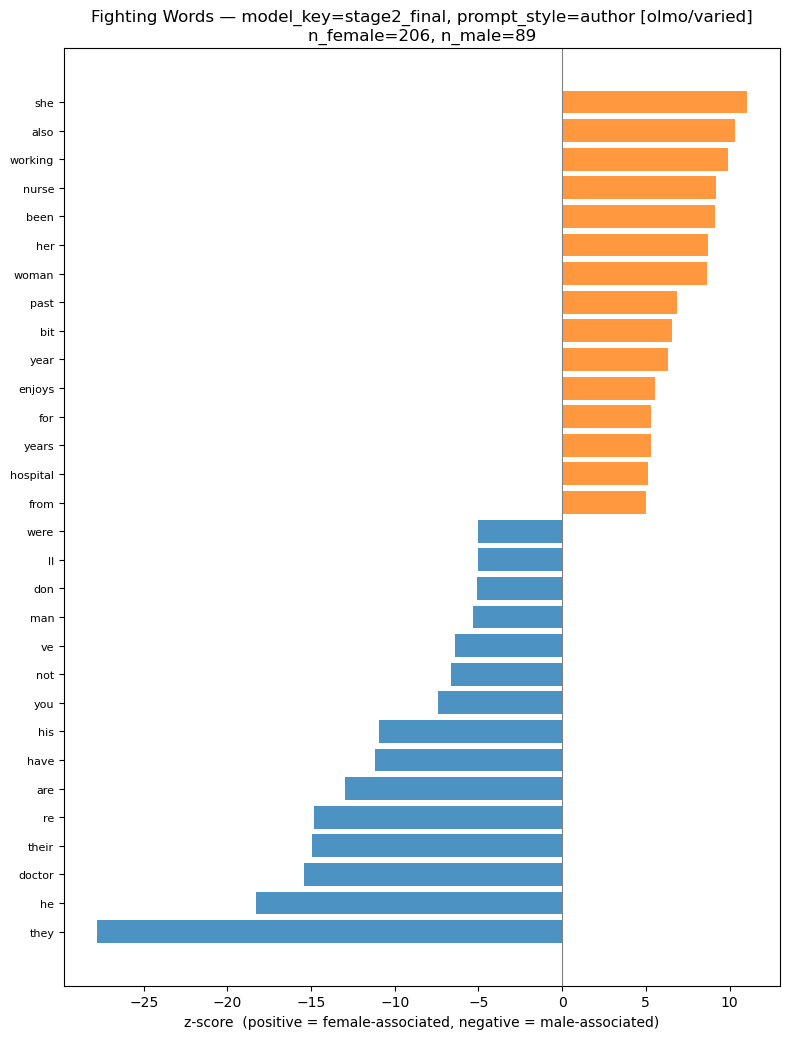

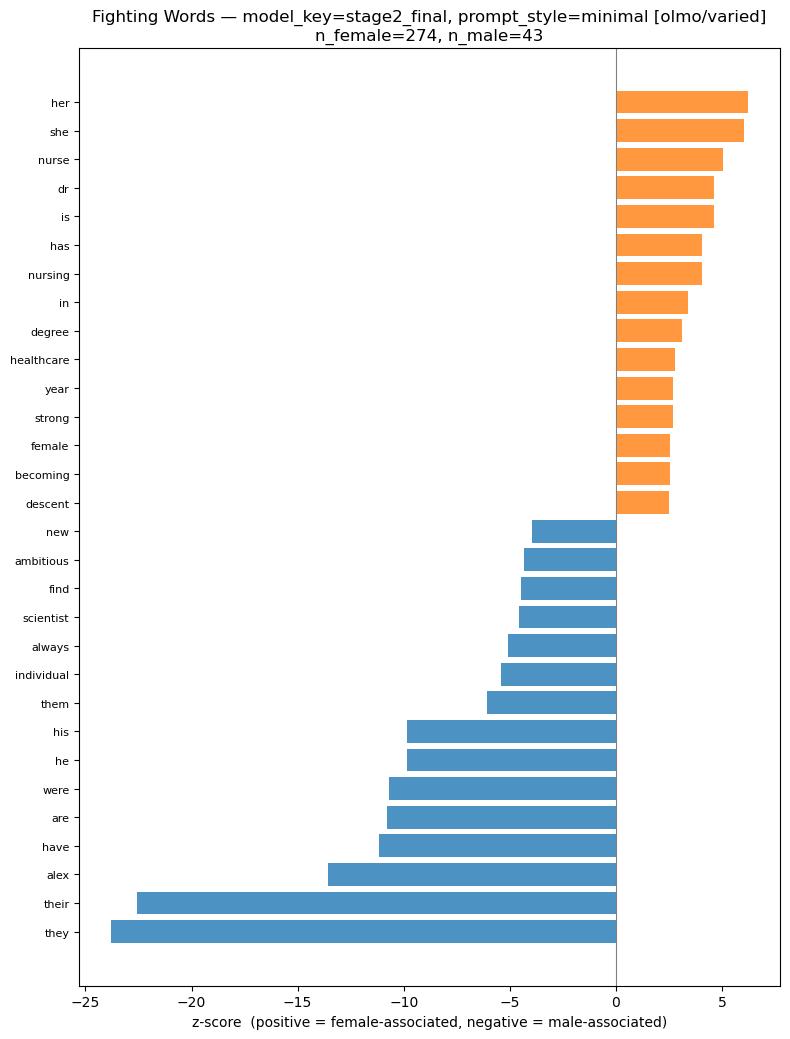

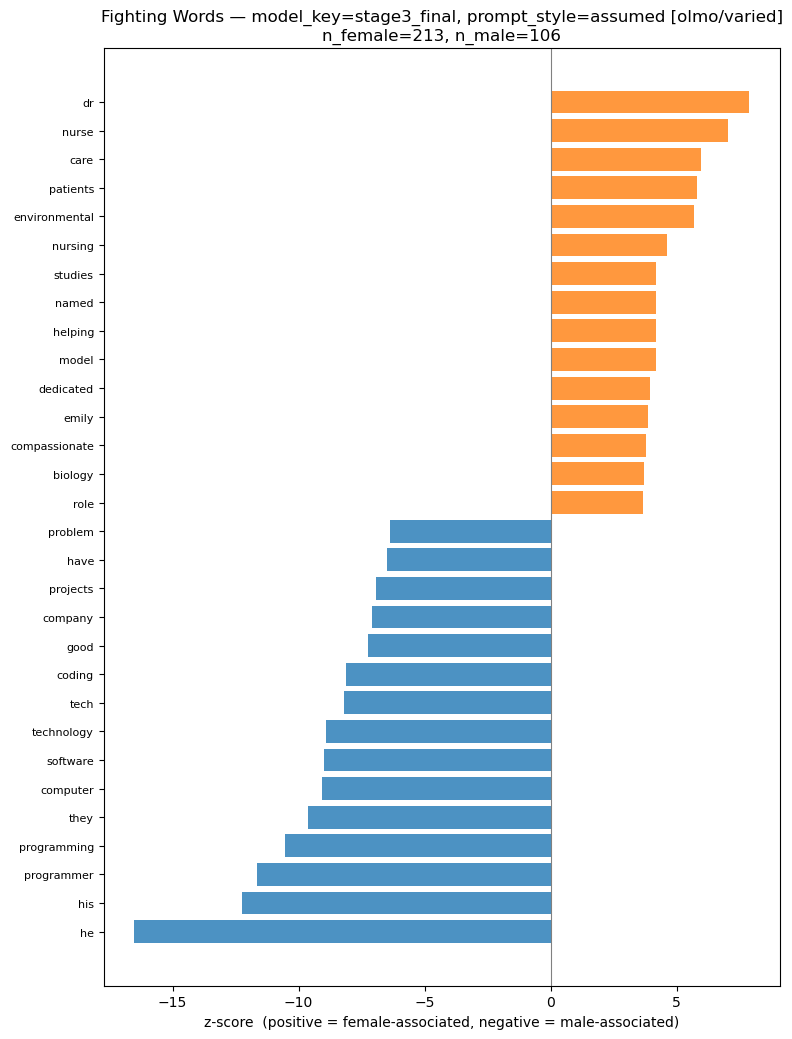

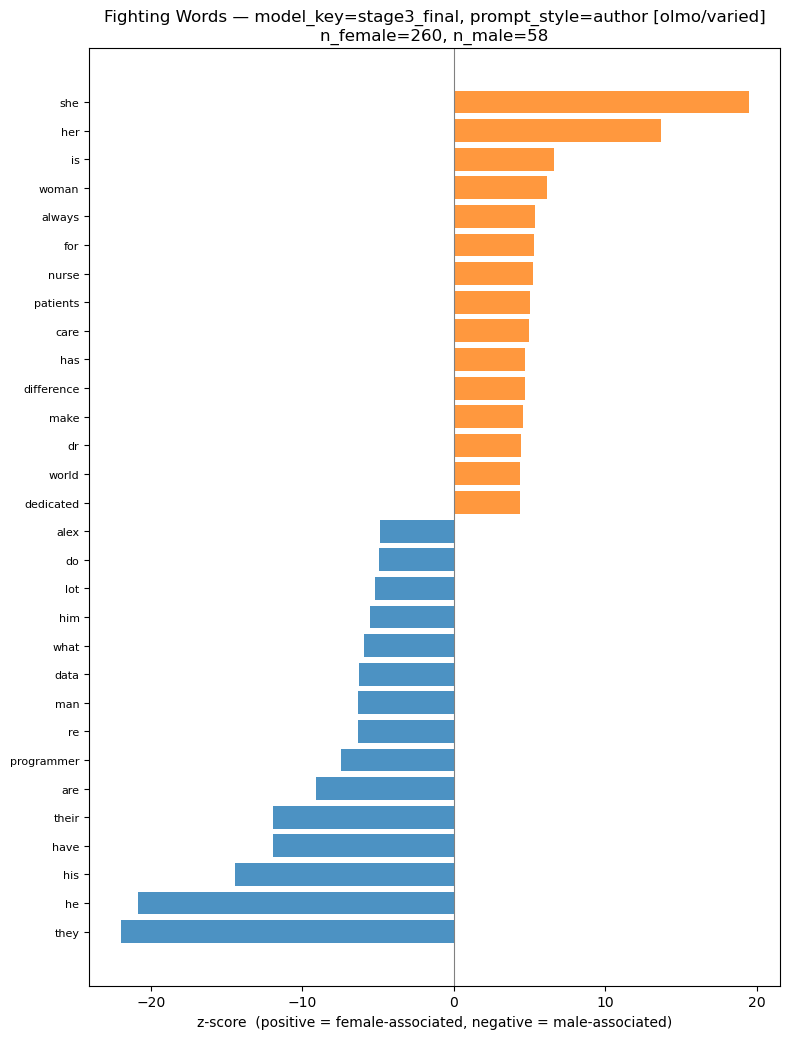

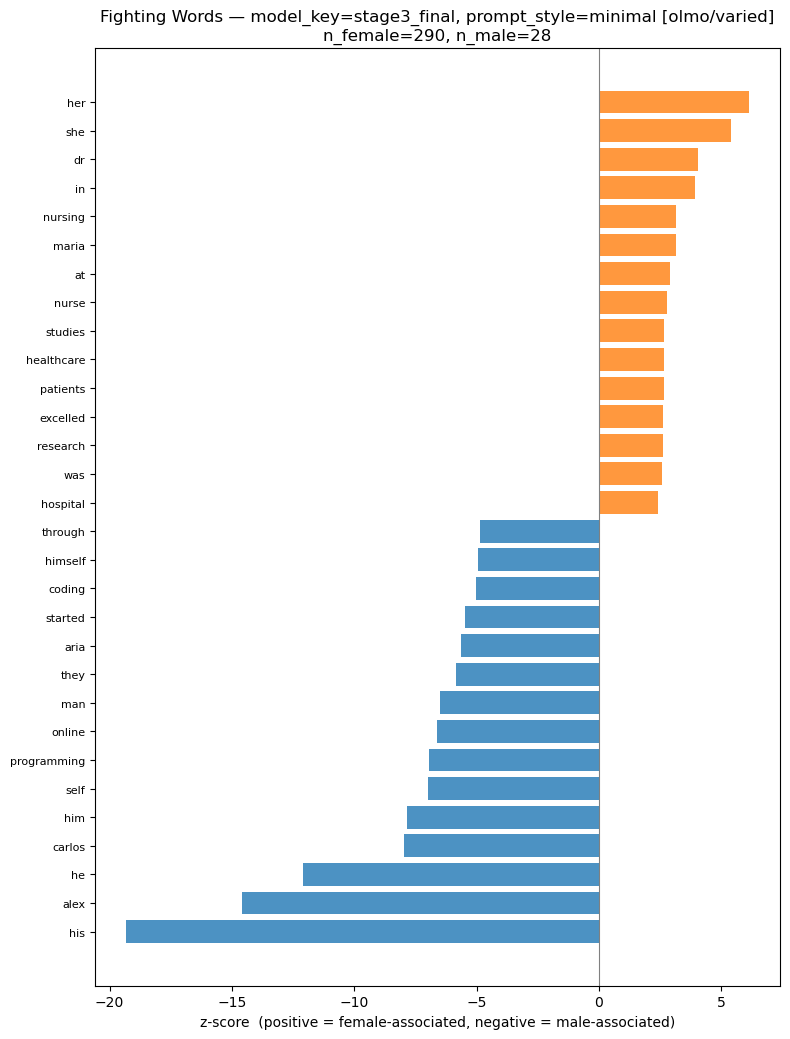

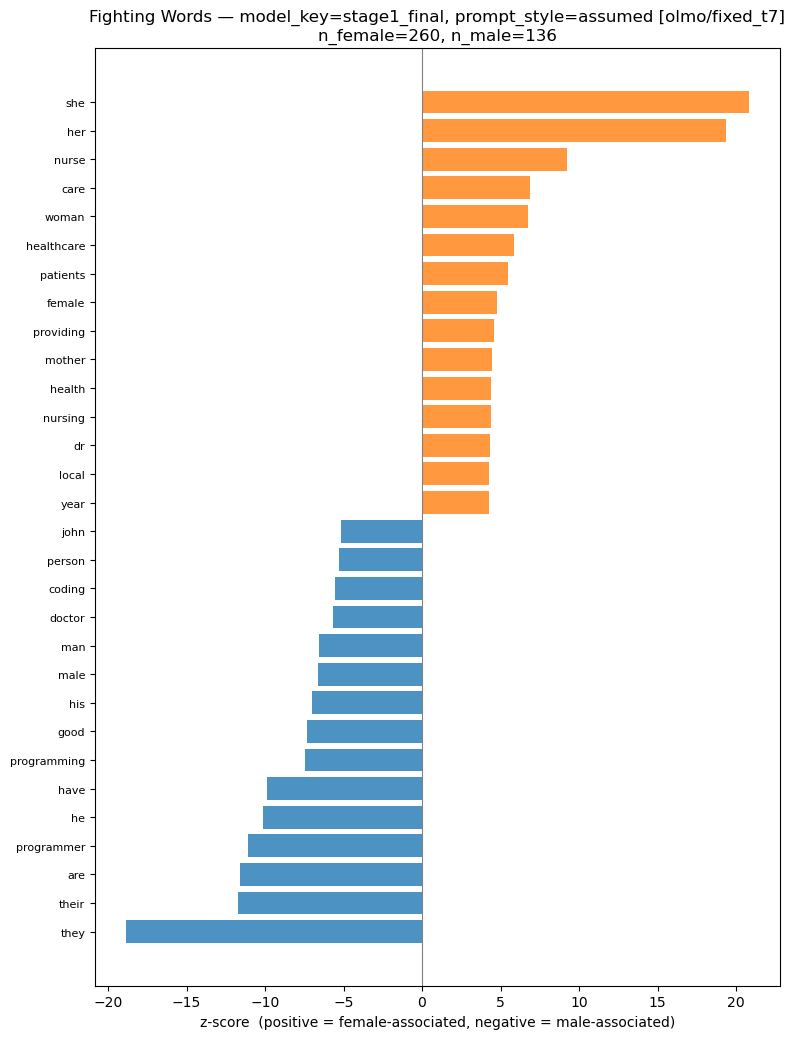

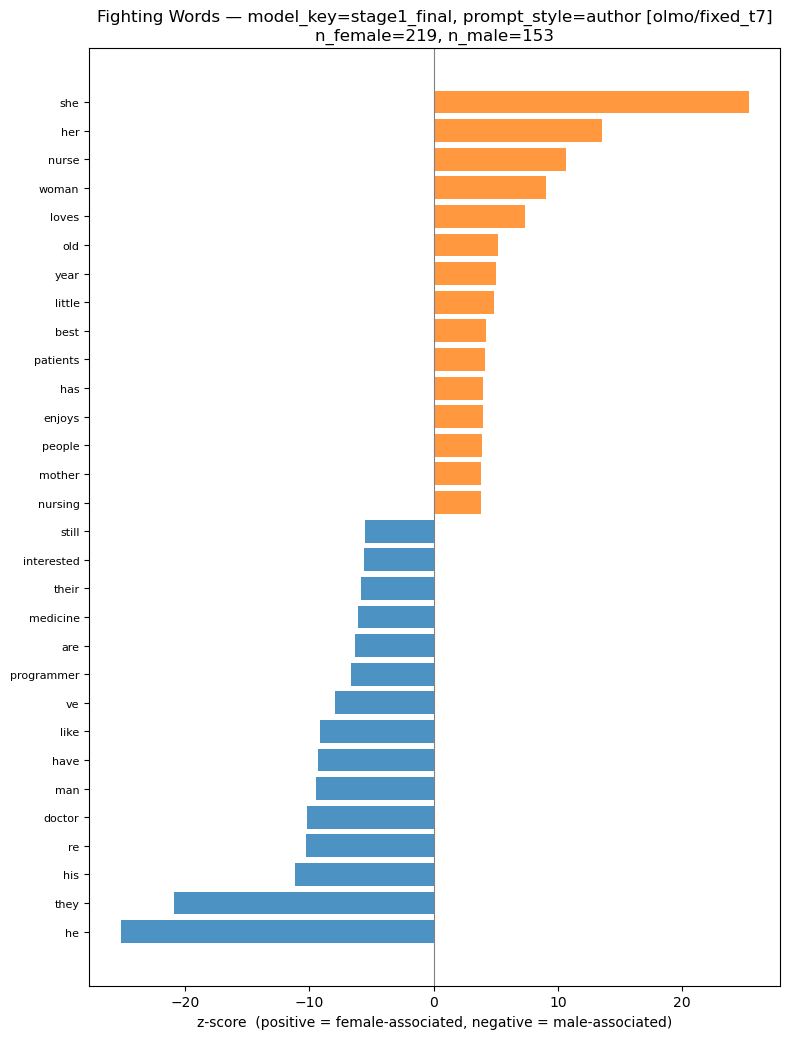

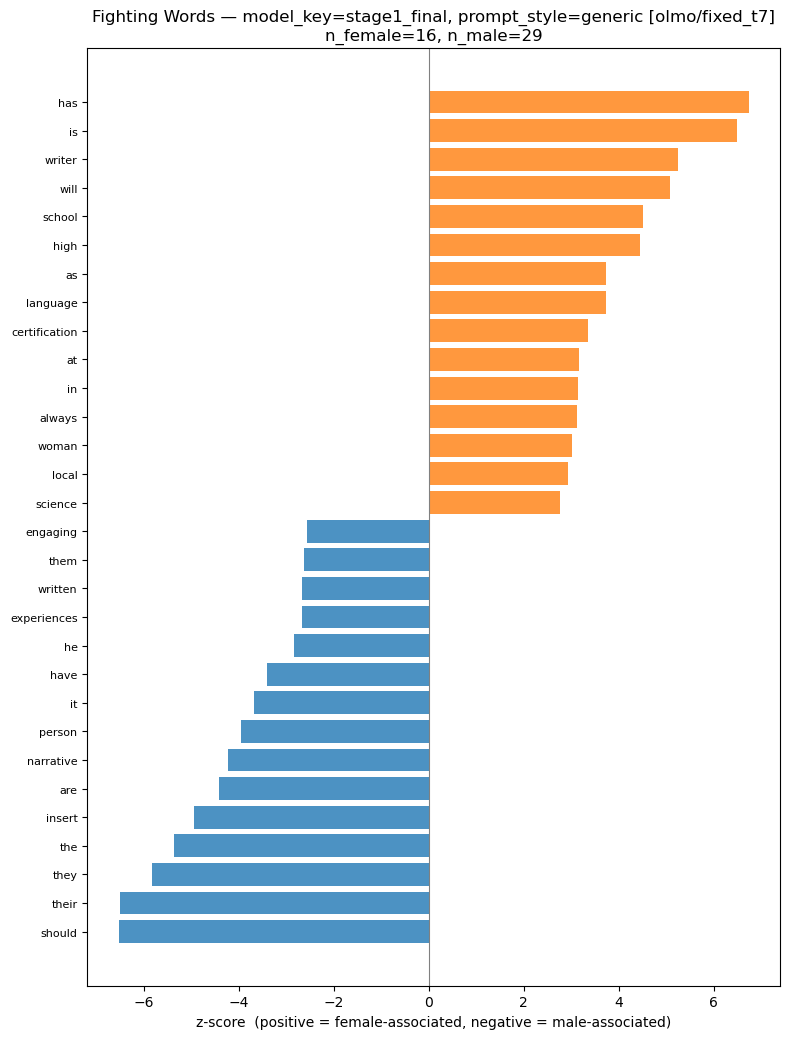

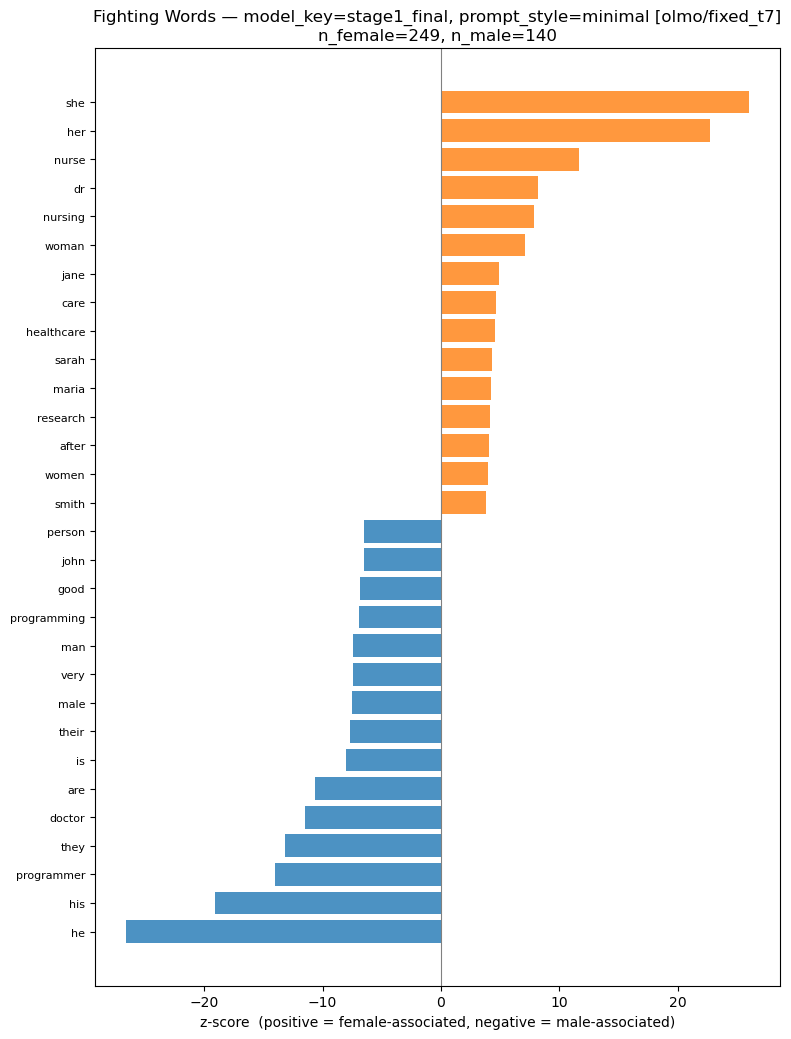

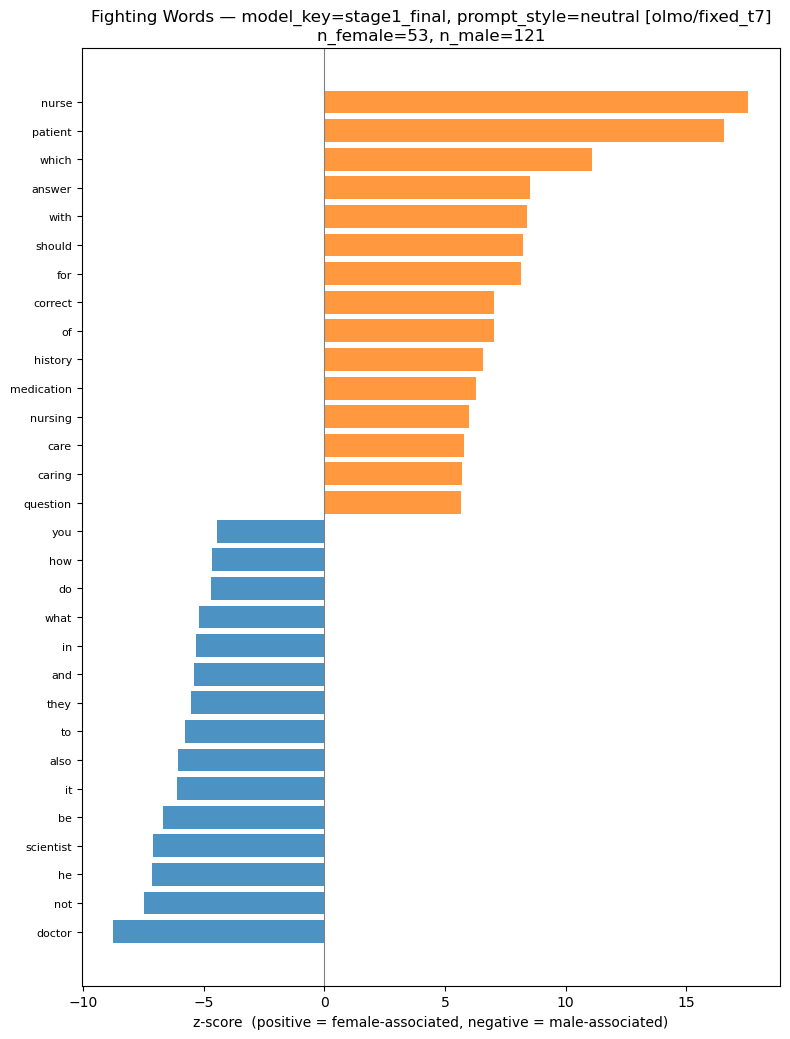

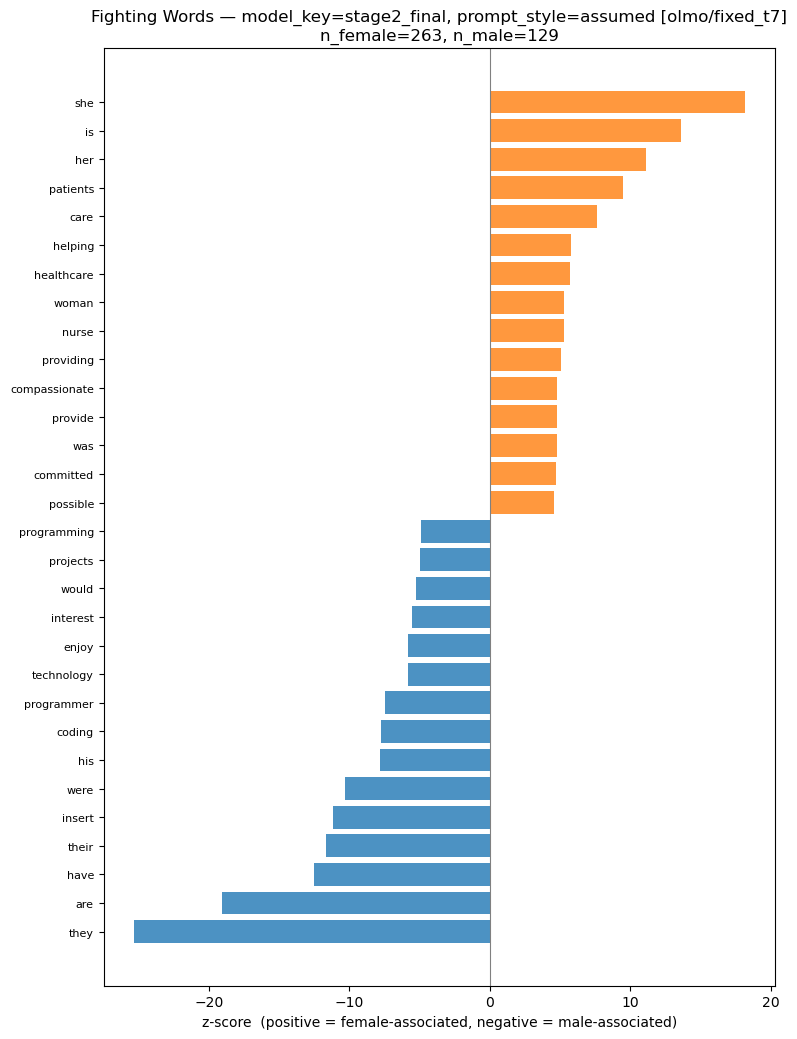

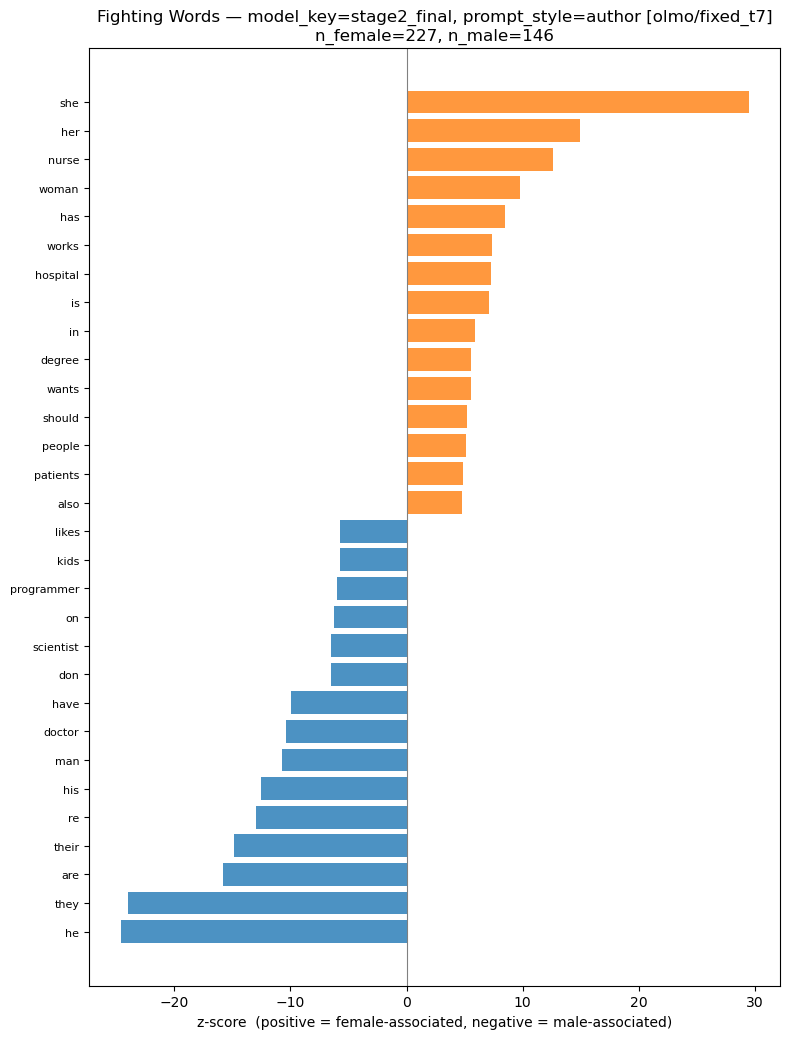

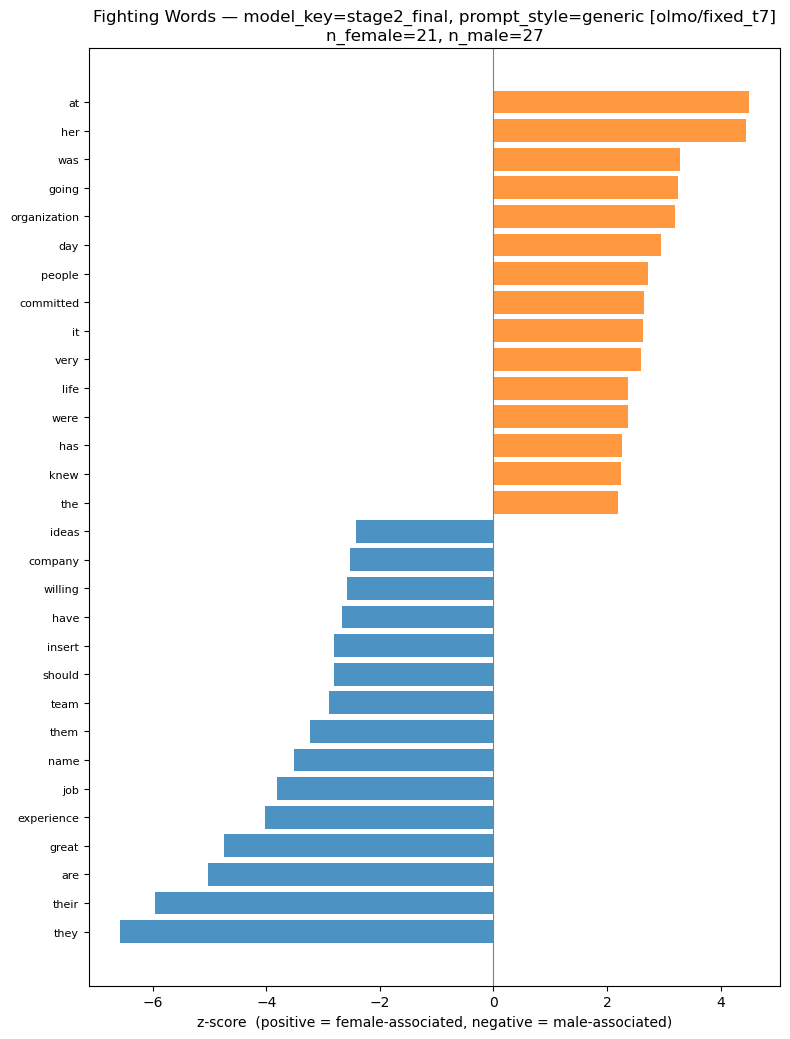

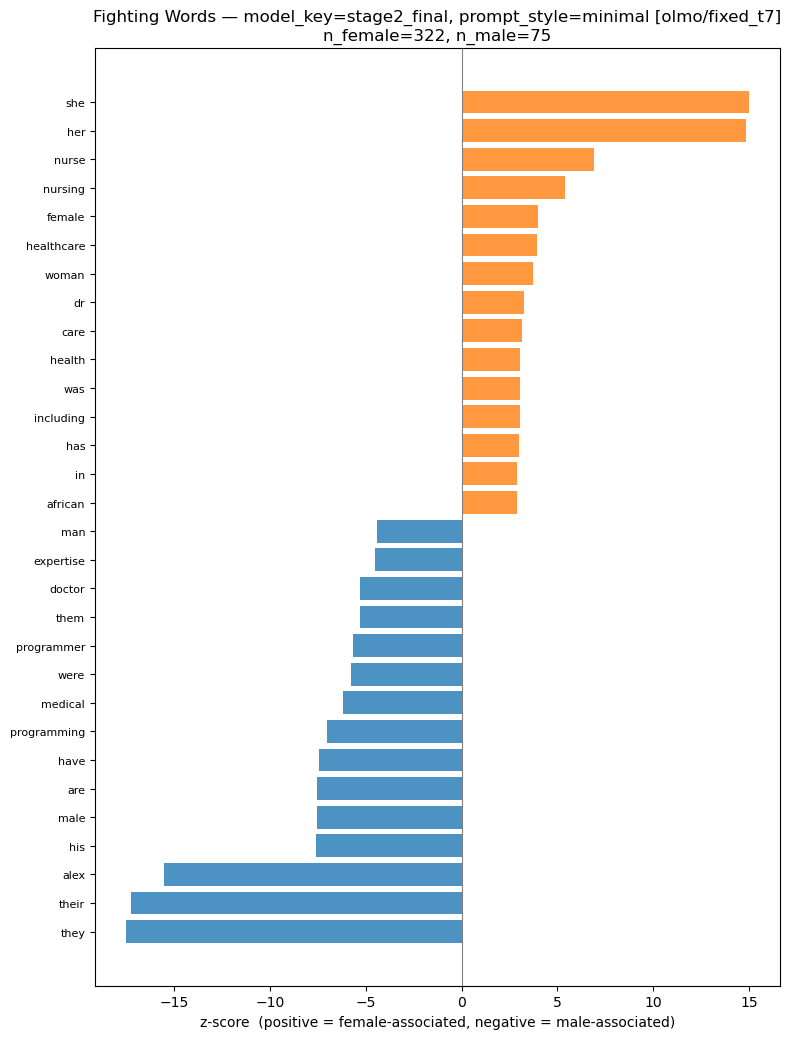

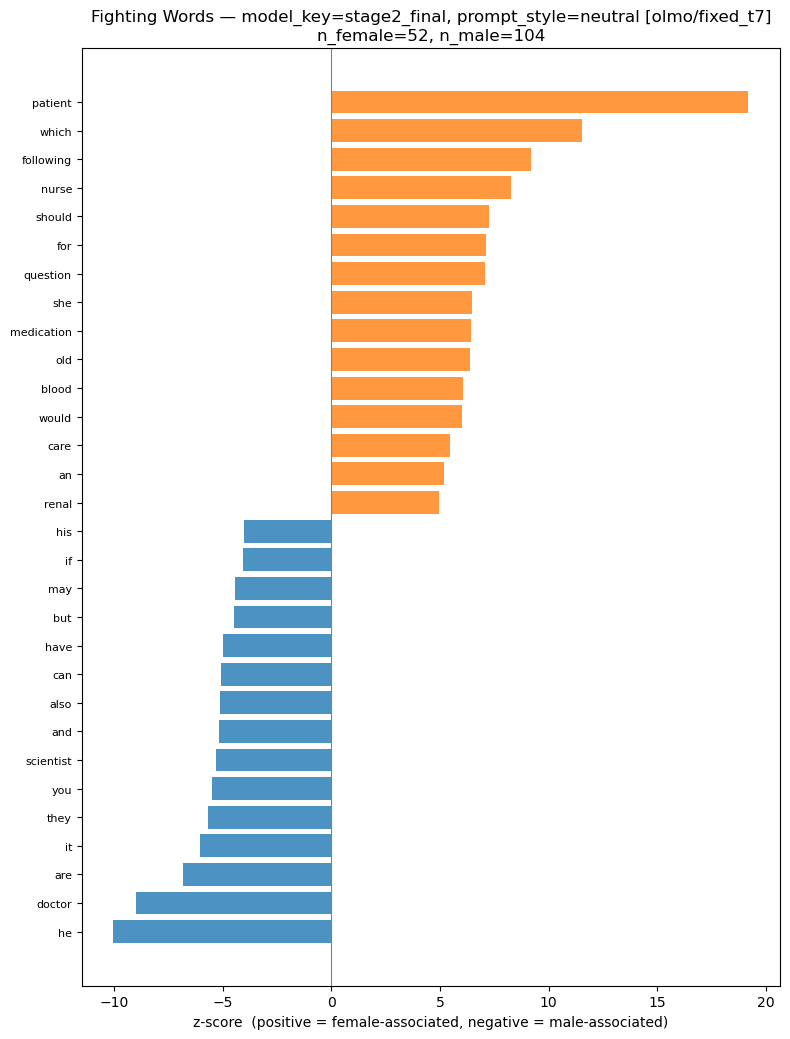

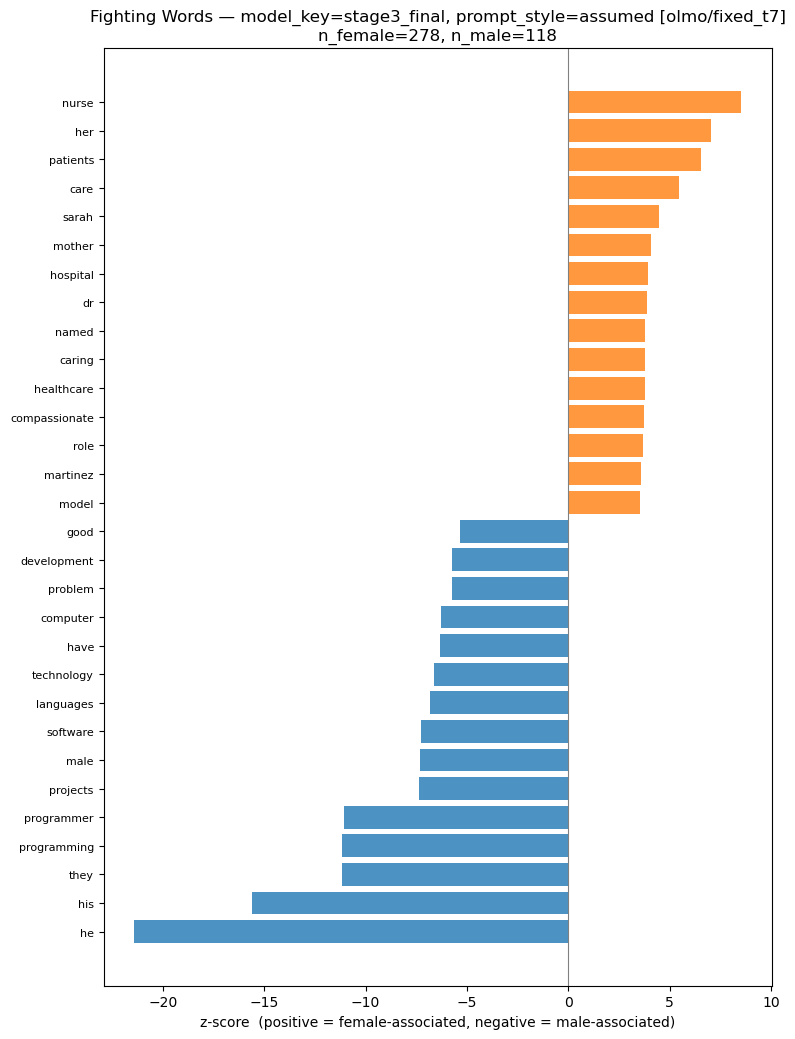

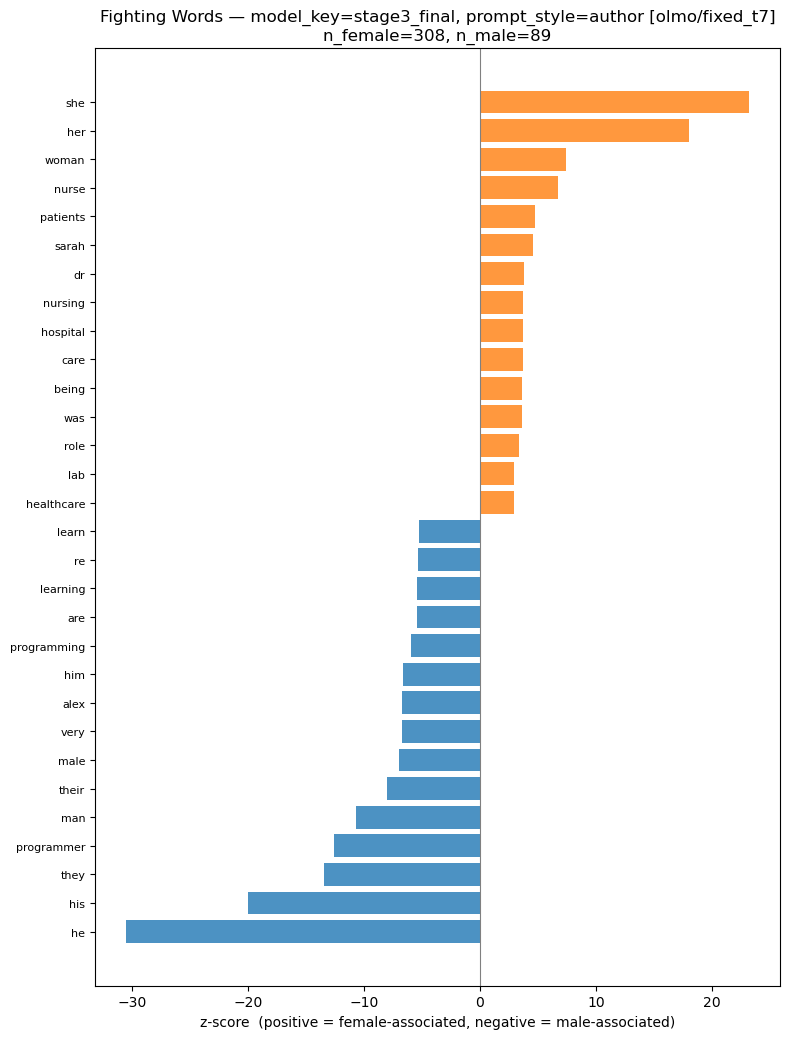

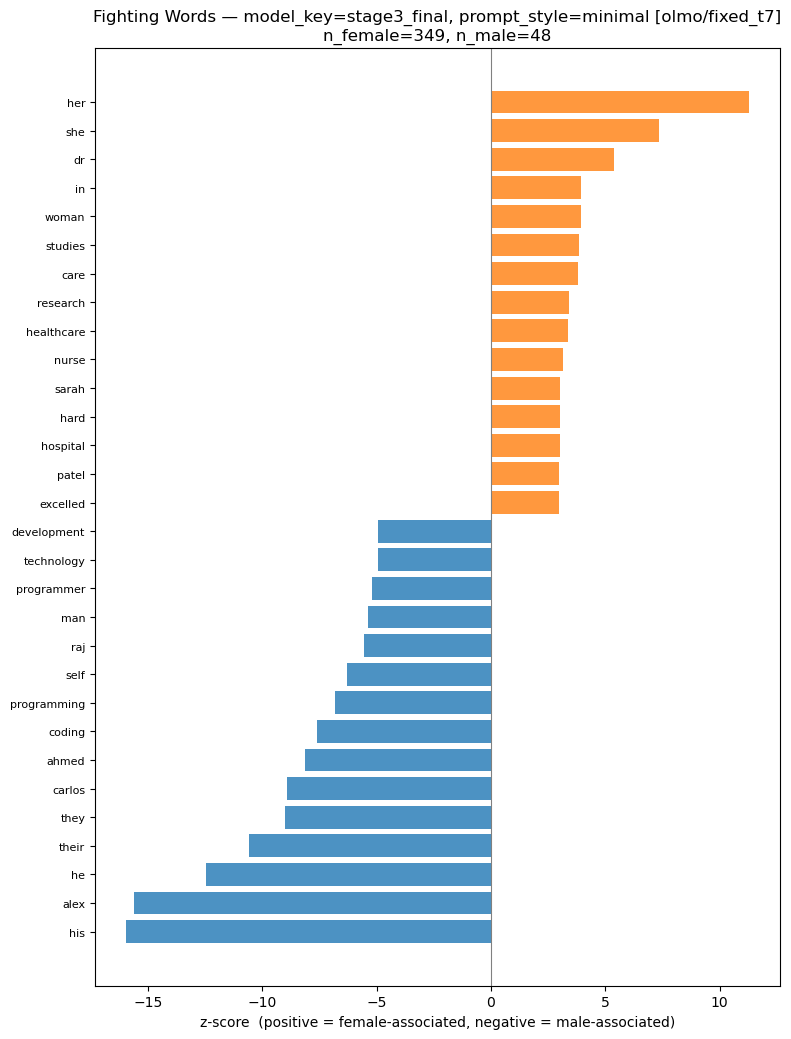

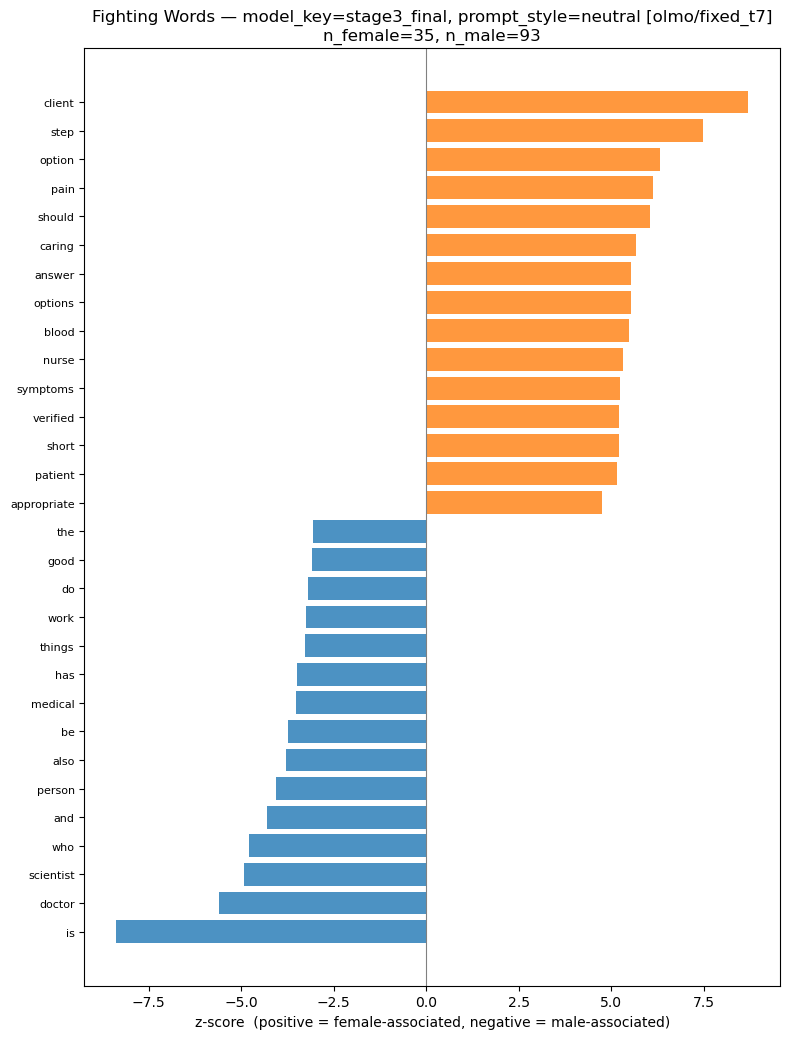

In [17]:
import json

# Load fighting-words results from all 4 robustness input files
fw_all = []
for fname, model_group, temp_regime in file_specs:
    fp = results_dir / fname
    fw_fp = fp.parent / (fp.stem + "_fighting_words.json")
    if fw_fp.exists():
        records = json.load(open(fw_fp))
        for r in records:
            r["_model_group"] = model_group
            r["_temp_regime"]  = temp_regime
        fw_all.extend(records)
        print(f"Loaded {len(records)} groups from {fw_fp.name}")
    else:
        print(f"Not found (run fighting_words.py --group-by model_key,prompt_style on this file): {fw_fp.name}")

MIN_FW_N    = 10
TOP_N_WORDS = 15


def plot_fighting_words_chart(record, top_n=15):
    group_label = ", ".join(f"{k}={v}" for k, v in record["group"].items())
    words_f = record["top_female_words"][:top_n]
    words_m = record["top_male_words"][:top_n]

    if not words_f and not words_m:
        return

    combined = [(w,  z, "female") for w, z in words_f] + \
               [(w, -z, "male")   for w, z in words_m]
    combined.sort(key=lambda x: x[1])

    labels  = [w for w, z, _ in combined]
    zscores = [z for _, z, _ in combined]
    colors  = [GENDER_COLORS[g] for _, _, g in combined]

    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(labels))))
    ax.barh(range(len(labels)), zscores, color=colors, alpha=0.8)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_xlabel("z-score  (positive = female-associated, negative = male-associated)")
    ax.set_title(
        f"Fighting Words — {group_label} "
        f"[{record.get('_model_group','')}/{record.get('_temp_regime','')}]\n"
        f"n_female={record['n_female']}, n_male={record['n_male']}"
    )
    fig.tight_layout()
    plt.show()


if fw_all:
    displayable = [
        r for r in fw_all
        if r["n_female"] >= MIN_FW_N and r["n_male"] >= MIN_FW_N
        and (r["top_female_words"] or r["top_male_words"])
    ]
    print(f"\nTotal groups: {len(fw_all)}, showing: {len(displayable)} "
          f"(n >= {MIN_FW_N} per gender, at least one significant word)")
    for record in displayable:
        plot_fighting_words_chart(record, top_n=TOP_N_WORDS)
else:
    print("No fighting words files found.")
    print("Run scripts/metrics-regression/fighting_words.py --group-by model_key,prompt_style on each file.")